# Alpha Project — Version 19 (Corrected)

> **Why v19 exists — audit of the v18 run's "Sharpe ≈ 3":**
> the v18 run switched portfolios to rebalance every `TARGET_HORIZON`=5
> days and earn the 5-day period return (a sound design change), but the
> reported statistics kept **daily** annualisation. Every portfolio
> Sharpe was inflated by **√5 ≈ 2.24** (`sharpe()` used √252 on ~50
> observations/year) and every annualised vol likewise; annual turnover
> was overstated ×5. Corrected, the v18 run's true numbers were
> approximately: L2 0.92, L4 1.01, L5 gross 1.31, **L5 net ≈ 1.02** —
> with a signal IC t-stat of 1.75 and ≈1.6 on the net Sharpe itself,
> i.e. *not statistically significant*. v19 additionally fixes a genuine
> (small) lookahead: with a 5-day forward target, the last 5 training
> dates of every walk-forward window (and of the static train/val
> splits) had targets computed from returns **inside** the following
> window — v19 purges them (embargo). Full list in the change log at
> the bottom.

---

# Alpha Project — Version 18 (Final)
## Quantitative Equity Alpha Research Pipeline

**Design principle of this version: hypothesis first, one pre-registered model, results reported as they come.**

v17's diagnosis showed two structural problems: (a) with a *raw* next-day return
target and market-wide (macro/ETF) features in the set, models — especially the
Random Forest — degenerate into market timers (constant prediction across all
stocks on 99% of days ⇒ zero usable cross-sectional signal), and (b) the
trailing-ICIR "dynamic ensemble" had no economic hypothesis — it was a machine
for chasing whatever worked recently. v18 removes both.

### Pre-registered research design

**Prediction problem.** Cross-sectional stock selection: predict each stock's
**5-day forward return relative to the cross-sectional mean that day**
(per-date demeaned). Demeaning removes the common market component from the
target, so no model can score by timing the market — only by ranking stocks.
The 5-day horizon is an economic choice made *before* seeing results: v17
showed ~114x annual turnover at a 1-day horizon, which no realistic cost
assumption survives; a weekly horizon targets slower, cheaper signals.

**Feature hypotheses (expected cross-sectional IC sign, stated up front and
checked in Cell 16):**

| Feature | Hypothesis | Expected sign |
|---|---|---|
| mom_5 | short-term reversal (1-week winners revert) | − |
| mom_20 / mom_60 / mom_252 | medium/long momentum persists | + |
| vol_20 / vol_60 / yz_vol_20 | low-volatility anomaly (high vol underperforms) | − |
| ma_spread | overextension above trend reverts | − |
| hurst_126 | persistent (trending) names continue | + |
| short_ratio / z20 / chg5 | elevated short-selling pressure is informed (bearish) | − |
| roe / profit_margin / revenue_growth (if enabled) | quality/growth premium | + |
| debt_to_equity (if enabled) | leverage penalised | − |

**Macro/ETF features are removed from the model feature set.** They are
identical for every stock on a given day, so they carry zero cross-sectional
ranking information by construction; they remain in the pipeline only as the
market factor for residualization and for regime context.

**One pre-registered model.** The traded signal is the **walk-forward
ElasticNet** — chosen a priori because the feature set contains correlated
blocks (four momentum horizons, three volatility measures) where L2 stabilises
and L1 prunes, and because a linear model's coefficients can be audited for
stability across retraining windows (Cell 27), which is itself part of the
hypothesis test. The OLS/Ridge/Lasso/RF ladder is retained **as diagnostics
only** (the course-required comparison), and a 1/N average of the four linear
models is reported as a robustness check — 1/N involves no fitted weights, so
it cannot be accused of picking "whatever works." There is no IC-weighted or
trailing-ICIR dynamic combination in this version.

**Results are reported as they come.** IC, Sharpe (gross and net of
liquidity-adjusted costs), and Sharpe-by-year for the pre-registered design —
no post-hoc model or period selection.

### Engineering fixes in v18 (vs v17)
1. Target = per-date demeaned 5-day forward return (`TARGET_HORIZON` in Cell 1)
2. PnL horizon aligned: portfolios earn the **next-day forward return**
   (`fwd_ret_1d`), fixing v17's mismatch where weights formed at *t* were
   credited with the *t−1→t* return
3. Level 5 solver failures **carry the previous book forward** instead of
   silently dropping the day (v17 dropped 147/834 days — a selection bias)
4. IC summaries flag statistically invalid results (N < 30 valid days) —
   v17's "RF Val IC +0.12" was computed on a single day
5. Extended ticker-rename map + canonical-symbol download fallback recovers
   price history for renamed names that failed to download in v17
   (BLL→BALL, WLTW→WTW, CTL→LUMN, FLT→CPAY, PEAK→DOC, …)
6. Fundamental-residualization flag defaults to **False** (fundamentals enter
   as hypothesis-carrying features); flip `RESIDUALIZE_VS_FUNDAMENTALS` in
   Cell 12b for the factor-neutralised variant

New cells keep the 2b / 5b / 12b labelling; all `Cell N` print labels are unchanged.

---

## Prior version (v16) notes


**This version's key upgrade — multi-model walk-forward + dynamic ensemble:**
1. **Multi-model walk-forward** — every retraining window now evaluates all
   five models (OLS, Ridge, Lasso, ElasticNet, Random Forest) out-of-sample,
   not just the one model picked from a single static validation period
2. **Dynamic forecast combination** — model weights are recomputed at every
   date using only trailing 6-month realized performance, so the ensemble
   adapts as relative model performance changes over time, with no use of
   future information at any point
3. Carries forward the v12 fixes intact: working per-ticker residualization,
   rolling IC chart, coefficient stability chart, plotted feature importances

**Full version history — what changed and why:**

| Version | Change | Why |
|---|---|---|
| v10 | Baseline pipeline: today's S&P 500 list, 12 features, 5-model ladder, walk-forward, 3 portfolio levels | Course-required model ladder + portfolio construction levels |
| v10 → v11 | Point-in-time constituents (survivorship bias fix), + short volume, short interest, fundamentals (21 features) | Today's-constituent-list approach silently excludes stocks removed from the index — usually the worst performers — making backtests look better than they would have been live |
| v11 → v12 | Excluded short interest from `ALL_FEATURES` (still computed, documented); added residualization, rolling IC chart, coefficient stability chart, plotted feature importance | A bug was found: short interest's Dec-2022-only coverage, when included in a global `dropna`, collapsed the entire training set to ~19 days. Excluding it (but keeping it computed for transparency) restored the full multi-year training window. Residualization was added to isolate stock-specific signal from market-wide regime noise, since Random Forest importance was dominated by macro/ETF features |
| v12 → v15 | A colleague's parallel branch: switched the walk-forward to Random Forest only, and proposed (in comments) a "dynamic forecast combination" using trailing realized IC instead of one fixed validation-period weight set | The static-weight approach in v12 has a real flaw: picking model weights from one validation period and freezing them assumes those weights stay optimal forever, which is itself a form of look-ahead. v15's instinct here was correct and is the main idea carried into v16 |
| v15 → v16 | **Two bugs in v15 fixed; the dynamic-combination idea properly implemented** | See "v15 → v16: what was fixed" below |

### v15 → v16: what was fixed

v15 had two specific bugs, both diagnosed before building this version:

**Bug 1 — Residualization was disabled, not "tested and found flat."** v15's
residualization cell was entirely commented out, and produced no output at
all when checked — it never ran. It also still used the original
cross-sectional-per-date approach (grouping by `date`), which is
mathematically invalid here: `spy_tlt_lag1` is identical for every stock on
a given day, so it has zero within-day variance and can never be regressed
against. v16 uses the corrected per-ticker (time-series) version validated
in v12, where each ticker's feature history is regressed against the market
factor's variation across days — confirmed working via a sanity check
(post-residualization correlation with the market factor lands at ~0.00000
for all seven features).

**Bug 2 — Coefficient stability chart crashed.** v15 switched its
walk-forward to fit only a Random Forest (which has no `.coef_` attribute),
but left the original `coef_history.append(...)` call — written for
ElasticNet — disabled rather than adapted. The result: `coef_history` stayed
permanently empty, and the chart cell crashed with
`KeyError: "None of ['train_end'] are in the columns"` trying to build a
DataFrame from an empty list. v16's walk-forward fits ElasticNet alongside
the other four models specifically so `coef_history` keeps being populated
correctly, and the chart works again.

**v15's good idea, now actually implemented.** v15's "Dynamic Forecast
Combination" cell had the right docstring (recompute model weights from
trailing realized IC, not a single frozen validation-period weight set) but
the code was a one-line stub: `pred_ensemble = pred_rf`. v16 (Cell 25)
implements this for real — walking through every out-of-sample date,
computing each model's trailing 126-day ICIR, weighting accordingly, and
producing a genuinely time-varying ensemble.

**Full Pipeline:**
0. Install / Imports
1. Point-in-time universe construction
2. Price data download
3. Equity feature engineering
4. Macro data (FRED)
5. ETF regime features
6. Short volume features
7. Short interest features (computed, documented exclusion)
8. Fundamental features
9. Master dataset assembly + strict lag discipline
10. Feature list + data quality audit (actual cell: 13 — see note below)
11. Train / Val / Test split
12. Residualization against market factor (actual cell: 12)
13. IC helper functions
14. Feature-level IC audit
15. Model 1: OLS
16. Model 2: Ridge
17. Model 3: Lasso
18. Model 4: ElasticNet
19. Model 5: Random Forest (+ plotted feature importance)
20. Model comparison (static, validation-period)
21. Forecast combination (static, validation-period — kept for comparison)
22. **Multi-model walk-forward backtest (NEW in v16 — all 5 models, not just 1)**
23. **Dynamic forecast combination (NEW in v16 — trailing-IC weights, not frozen)**
24. Rolling IC chart (now on the dynamic ensemble)
25. Coefficient stability chart
26. Portfolio Level 2
27. Portfolio Level 4
28. Portfolio Level 5 (CVXPY)
29. Transaction cost analysis
30. Final performance summary
31. Equity curve charts
32. Paper trading
33. Assumptions & next steps

**Note:** the numbered list above is the conceptual pipeline order. The
actual in-notebook `Cell N` labels (used in every print statement) run
sequentially from Cell 0 to Cell 35 exactly matching execution order —
Residualization is Cell 12, Feature List + Audit is Cell 13, and so on.
Use the `Cell N` labels printed by each cell as the source of truth.

**Why v16 is a genuine improvement, not just a merge:** model selection in
v12 happened twice on the same validation period — once to pick which model
"won," and again implicitly by only walk-forward testing that one model.
v16 removes that redundancy: every model gets a fair, fully out-of-sample
evaluation, and the combination weights themselves evolve through time
using only information available at each point, which is the more
defensible research design v15 was reaching for.


In [ ]:
# =============================================================
# Cell 0 — Dependencies
# =============================================================
# Everything needed is pinned in requirements.txt at the repo root.
# Uncomment on a fresh environment (e.g. Colab):

# %pip install -r ../requirements.txt --quiet


In [2]:
# =============================================================
# Cell 1 — Imports & Global Settings
# =============================================================
# All imports and global constants defined upfront.
# START_DATE covers our full backtest window.
# =============================================================

import os
import pandas as pd
import numpy as np
import requests
import warnings
import yfinance as yf
import cvxpy as cp

from io import StringIO
from tqdm import tqdm
from fredapi import Fred
from scipy.stats import spearmanr
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.6f}".format)

# --- Global constants ---
START_DATE   = "2020-01-01"

# v18: prediction horizon in trading days. The target (Cell 11) is the
# per-date DEMEANED forward return over this horizon. Chosen a priori:
# a 1-day horizon implied ~114x annual turnover in v17, which no
# realistic cost assumption survives; ~1 week targets slower signals.
TARGET_HORIZON = 5

# v19: portfolios rebalance every TARGET_HORIZON trading days and earn
# the H-day PERIOD return, so a year contains 252/H observations —
# annualisation MUST use this factor, not 252. (The v18 run annualised
# 5-day period returns with √252, inflating every Sharpe by √5 ≈ 2.24
# and every annualised vol by the same factor.)
REBALANCE_EVERY  = TARGET_HORIZON
PERIODS_PER_YEAR = 252 / REBALANCE_EVERY
FRED_API_KEY = os.getenv("FRED_API_KEY")  # free key from fred.stlouisfed.org

# --- File paths (relative to the repo root; see Data/README.md) ---
if os.path.basename(os.getcwd()) == "Notebooks":
    os.chdir("..")
PATH_SP500_HISTORY = "Data/S&P 500 Historical Components & Changes (Updated).csv"
PATH_SHORT_VOL     = "Data/short_vol.parquet"
PATH_SHORT_INT     = "Data/short_int.parquet"
PATH_FUNDAMENTALS  = "Data/fundamentals.parquet"

print("Cell 1: Imports complete (including statsmodels for residualization).")
print(f"Cell 1: Data start date: {START_DATE}")


Cell 1: Imports complete (including statsmodels for residualization).
Cell 1: Data start date: 2020-01-01


In [3]:
# =============================================================
# Cell 2 — Point-in-Time Universe Construction
# =============================================================
# KEY UPGRADE FROM V10:
# V10 used today's S&P 500 constituent list applied to all
# of history. This is SURVIVORSHIP BIAS — stocks that were
# removed from the index (often poor performers) are excluded,
# making the backtest look artificially good.
#
# V11 FIX:
# We use a historical constituent file that records exactly
# which tickers were in the S&P 500 on each change date.
# The file only records rows when the composition CHANGED,
# so we forward-fill to get the constituent set for every
# trading day.
#
# HOW IT WORKS:
# 1. Load the change file (one row per composition change)
# 2. Build a complete daily calendar from START_DATE to today
# 3. Forward-fill: each day inherits the most recent known
#    constituent list
# 4. For any given date, we look up which tickers were valid
#    and ONLY use those in our universe that day
#
# SYMBOLOGY NOTE:
# The history file uses dots (BRK.B, BF.B).
# Yahoo Finance and our other data sources use dashes (BRK-B).
# We normalise to dashes throughout.
#
# RESULT: a dictionary {date -> set of valid tickers}
# that we use to filter our panel at every step.
# =============================================================

print("Cell 2: Loading point-in-time S&P 500 constituent history...")

sp_hist = pd.read_csv(PATH_SP500_HISTORY)
sp_hist["date"] = pd.to_datetime(sp_hist["date"])
sp_hist = sp_hist.sort_values("date").reset_index(drop=True)

print(f"Cell 2: History file rows: {len(sp_hist)}")
print(f"Cell 2: Date range: {sp_hist['date'].min().date()} → {sp_hist['date'].max().date()}")

# Build a full business-day calendar from START_DATE to today
bday_calendar = pd.bdate_range(start=START_DATE, end=pd.Timestamp.today())

# Forward-fill constituent lists to every business day
# merge_asof finds the most recent change on or before each calendar date
sp_hist_clean = sp_hist[sp_hist["date"] <= bday_calendar[-1]].copy()

daily_constituents = pd.merge_asof(
    pd.DataFrame({"date": bday_calendar}),
    sp_hist_clean[["date", "tickers"]],
    on="date",
    direction="backward"   # use the most recent constituent list
)

# Parse comma-separated ticker strings → sets, normalise dots to dashes
def parse_tickers(ticker_str):
    """Split comma-separated ticker string and normalise dot → dash."""
    if pd.isna(ticker_str):
        return set()
    return set(t.strip().replace(".", "-") for t in ticker_str.split(","))

daily_constituents["ticker_set"] = daily_constituents["tickers"].apply(parse_tickers)

# Build lookup dictionary: date → set of valid tickers
# This is our point-in-time universe filter
pit_universe = dict(zip(
    daily_constituents["date"],
    daily_constituents["ticker_set"]
))

# Get the union of all tickers ever in the index since START_DATE
# (used to know which tickers to download price data for)
all_tickers_ever = set()
for ts in daily_constituents["ticker_set"]:
    all_tickers_ever.update(ts)

all_tickers_ever = sorted(all_tickers_ever)

print(f"Cell 2: Business days in calendar: {len(bday_calendar)}")
print(f"Cell 2: Total unique tickers ever in index since {START_DATE}: {len(all_tickers_ever)}")
print(f"Cell 2: Sample tickers for {bday_calendar[0].date()}: {sorted(list(pit_universe[bday_calendar[0]]))[:10]}")
print("Cell 2: Point-in-time universe ready — survivorship bias eliminated.")


Cell 2: Loading point-in-time S&P 500 constituent history...
Cell 2: History file rows: 2712
Cell 2: Date range: 1996-01-02 → 2026-06-02
Cell 2: Business days in calendar: 1705
Cell 2: Total unique tickers ever in index since 2020-01-01: 637
Cell 2: Sample tickers for 2020-01-01: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABT', 'ACN', 'ADBE']
Cell 2: Point-in-time universe ready — survivorship bias eliminated.


In [4]:
# =============================================================
# Cell 2b — CIK Entity Mapping (NEW in v17)
# =============================================================
# WHY CIK INSTEAD OF TICKER:
# Ticker symbols change over time (FB→META, ANTM→ELV,
# DISCA→WBD, ...). If the entity key is the raw ticker, a
# renamed company is silently treated as TWO different stocks:
# its feature history breaks at the rename date and joins
# against short-volume / fundamentals data can miss.
# The SEC Central Index Key (CIK) is a permanent company
# identifier that never changes, so we use it as the stable
# entity key throughout the pipeline.
#
# ONE SUBTLETY — MULTIPLE SHARE CLASSES:
# CIK identifies a COMPANY, not a SECURITY. Alphabet's GOOG
# and GOOGL (both S&P 500 members) share one CIK, as do
# BRK-A / BRK-B. Using the bare CIK as a row key would
# collide those listings. We therefore build a security-level
# key:  sec_id = "<CIK>:<canonical ticker>"
# - The CIK part gives rename-stability across time
#   (ANTM and ELV resolve to the same CIK).
# - The canonical-ticker part keeps distinct share classes
#   distinct (GOOG vs GOOGL).
#
# TICKER_RENAME_MAP:
# The SEC file only maps CURRENT tickers. Old symbols of
# renamed companies are not in it, so we first canonicalise
# old→current with a manual map (extend as needed — this
# covers the well-known S&P 500 renames since 2020, and
# directly implements "Next Step 7" from the v16 notes).
#
# FALLBACK: tickers with no CIK match (delisted/acquired names
# Yahoo still returns, e.g. some SPACs) get a synthetic
# "NOCIK:<ticker>" id so the pipeline still works for them —
# they just don't gain rename-stability.
# =============================================================

print("Cell 2b: Building ticker → CIK entity mapping...")

# Old symbol → current symbol for known renames (NOT acquisitions).
# Extend this map as you discover more renamed tickers.
TICKER_RENAME_MAP = {
    "FB":    "META",   # Facebook → Meta (2022)
    "ANTM":  "ELV",    # Anthem → Elevance (2022)
    "DISCA": "WBD",    # Discovery A → Warner Bros. Discovery (2022)
    # NOTE: DISCK (Discovery class C) is deliberately NOT mapped —
    # DISCA and DISCK traded simultaneously; mapping both onto WBD
    # would collide two live securities onto one key. Map only the
    # primary class per company.
    "KORS":  "CPRI",   # Michael Kors → Capri
    "INFO":  "SPGI",   # IHS Markit merged into S&P Global (2022)
    "FISV":  "FI",     # Fiserv rename (2023)
    "PKI":   "RVTY",   # PerkinElmer → Revvity (2023)
    "RE":    "EG",     # Everest Re → Everest Group (2023)
    # v18 additions — 1:1 ticker renames of the SAME entity, added because
    # these old symbols failed to download in the v17 run. Each recovers
    # the entity's history under its current symbol via the Cell 3
    # fallback. VERIFY these before publishing (added from memory of
    # corporate actions; acquisitions/mergers with a different surviving
    # entity are deliberately NOT mapped):
    "BLL":   "BALL",   # Ball Corp rename (2022)
    "WLTW":  "WTW",    # Willis Towers Watson rename (2022)
    "CTL":   "LUMN",   # CenturyLink → Lumen (2020)
    "FBHS":  "FBIN",   # Fortune Brands rename (2022)
    "FLT":   "CPAY",   # FLEETCOR → Corpay (2024)
    "PEAK":  "DOC",    # Healthpeak ticker change (2024)
    "NLOK":  "GEN",    # NortonLifeLock → Gen Digital (2022)
    "CDAY":  "DAY",    # Ceridian → Dayforce (2024)
    "COG":   "CTRA",   # Cabot → Coterra (2021)
    "ADS":   "BFH",    # Alliance Data → Bread Financial (2022)
    "GPS":   "GAP",    # Gap ticker change (2024)
}

def canonical_ticker(t):
    """Map an (old) ticker to its current canonical symbol."""
    t = str(t).strip().upper().replace(".", "-")
    return TICKER_RENAME_MAP.get(t, t)

# --- Fetch the SEC's official ticker → CIK file ---
# SEC requires a descriptive User-Agent header on all requests.
TICKER_TO_CIK = {}
try:
    resp = requests.get(
        "https://www.sec.gov/files/company_tickers.json",
        headers={"User-Agent": "alpha-research-project contact@example.com"},
        timeout=30,
    )
    resp.raise_for_status()
    sec_map = resp.json()
    for _, rec in sec_map.items():
        tk = str(rec["ticker"]).strip().upper()
        cik10 = f"{int(rec['cik_str']):010d}"
        # store both dash and dot variants of the symbol
        TICKER_TO_CIK[tk] = cik10
        TICKER_TO_CIK[tk.replace(".", "-")] = cik10
        TICKER_TO_CIK[tk.replace("-", ".")] = cik10
    print(f"Cell 2b: SEC mapping loaded — {len(sec_map):,} companies.")
except Exception as e:
    print(f"Cell 2b: WARNING — SEC ticker/CIK fetch failed ({e}).")
    print("Cell 2b: Falling back to synthetic ids (pipeline still runs,")
    print("Cell 2b: but without cross-rename entity stability).")

def get_cik(ticker):
    """Pure 10-digit CIK for a ticker (after canonicalisation), or None."""
    return TICKER_TO_CIK.get(canonical_ticker(ticker))

def get_sec_id(ticker):
    """
    Stable SECURITY-level entity id used as the join/group key
    everywhere downstream (replaces raw ticker as the entity key):
        "<CIK>:<canonical_ticker>"  when CIK is known
        "NOCIK:<canonical_ticker>"  otherwise
    """
    ct  = canonical_ticker(ticker)
    cik = TICKER_TO_CIK.get(ct)
    return f"{cik}:{ct}" if cik else f"NOCIK:{ct}"

# Quick coverage report on the download universe
_n_mapped = sum(get_cik(t) is not None for t in all_tickers_ever)
print(f"Cell 2b: CIK coverage on universe: {_n_mapped}/{len(all_tickers_ever)} tickers"
      f" ({_n_mapped/len(all_tickers_ever):.1%})")
print("Cell 2b: Unmapped tickers keep a synthetic 'NOCIK:<ticker>' id.")
print("Cell 2b: Entity key ready — downstream cells group/join on 'sec_id'.")


Cell 2b: Building ticker → CIK entity mapping...
Cell 2b: SEC mapping loaded — 10,408 companies.
Cell 2b: CIK coverage on universe: 578/637 tickers (90.7%)
Cell 2b: Unmapped tickers keep a synthetic 'NOCIK:<ticker>' id.
Cell 2b: Entity key ready — downstream cells group/join on 'sec_id'.


In [5]:
# =============================================================
# Cell 3 — Price Data Download
# =============================================================
# We download adjusted OHLCV data for ALL tickers that have
# EVER been in the S&P 500 since START_DATE (not just current
# members). This is required for the point-in-time universe
# to work correctly — we need returns data for stocks that
# were later removed from the index.
#
# This will download more tickers than v10 (~550-600 vs ~503).
#
# WHY AUTO-ADJUST=TRUE:
# Adjusted prices account for dividends and splits. Without
# this, a 2:1 stock split would appear as a -50% return,
# contaminating momentum and return features.
# =============================================================

print("Cell 3: Downloading price data for all historical S&P 500 tickers...")
print(f"Cell 3: Tickers to download: {len(all_tickers_ever)}")
print("Cell 3: This may take 3-5 minutes...")

# v18: also download each ticker's CANONICAL (current) symbol so that
# renamed names whose old symbol Yahoo no longer serves (e.g. BLL →
# BALL) are recovered from the current symbol's history.
download_tickers = sorted(
    set(all_tickers_ever) | {canonical_ticker(t) for t in all_tickers_ever}
)
print(f"Cell 3: Including canonical symbols → {len(download_tickers)} downloads")

raw = yf.download(
    download_tickers,
    start=START_DATE,
    auto_adjust=True,
    group_by="ticker",
    threads=True,
    progress=False
)

print("Cell 3: Download complete. Reshaping to long panel format...")

price_list = []
skipped = []

for t in tqdm(all_tickers_ever, desc="Cell 3: Reshaping"):
    try:
        # v18: try the original symbol first, then its canonical rename.
        # Rows keep ticker = t (the ORIGINAL symbol) so the point-in-time
        # membership filter in Cell 4 still matches the history file;
        # entity identity is unified later via sec_id.
        df = None
        for src in (t, canonical_ticker(t)):
            if src not in raw.columns.get_level_values(0):
                continue
            cand = raw[src].copy().reset_index()
            cand.rename(columns={"Date": "date"}, inplace=True)
            cand.columns = [c.lower() for c in cand.columns]
            if "close" in cand.columns and not cand["close"].isna().all():
                df = cand
                break
        if df is None:
            skipped.append(t)
            continue
        df["ticker"] = t
        price_list.append(df[["date", "ticker", "open", "high", "low", "close", "volume"]])
    except Exception as e:
        skipped.append(t)

# ── v19: one retry pass for skipped tickers ──
# The v18 run lost live large-caps (BK, MMC, K, CTRA, DAY, FI, ...) to
# transient Yahoo failures — that is avoidable survivorship. Retry each
# skipped ticker (and its canonical symbol) once, individually.
if skipped:
    print(f"Cell 3: Retrying {len(skipped)} skipped tickers individually...")
    still_skipped = []
    for t in tqdm(skipped, desc="Cell 3: Retry"):
        got = False
        for src in dict.fromkeys([t, canonical_ticker(t)]):
            try:
                cand = yf.download(src, start=START_DATE, auto_adjust=True,
                                   progress=False)
                if cand is None or cand.empty:
                    continue
                cand = cand.reset_index()
                if isinstance(cand.columns, pd.MultiIndex):
                    cand.columns = [c[0] for c in cand.columns]
                cand.rename(columns={"Date": "date"}, inplace=True)
                cand.columns = [str(c).lower() for c in cand.columns]
                if "close" in cand.columns and not cand["close"].isna().all():
                    cand["ticker"] = t
                    price_list.append(
                        cand[["date", "ticker", "open", "high", "low",
                              "close", "volume"]])
                    got = True
                    break
            except Exception:
                continue
        if not got:
            still_skipped.append(t)
    print(f"Cell 3: Retry recovered {len(skipped) - len(still_skipped)} tickers;"
          f" {len(still_skipped)} remain missing (mostly acquired/delisted:")
    print(f"Cell 3: {sorted(still_skipped)})")
    skipped = still_skipped

price_data = pd.concat(price_list, ignore_index=True)
price_data["date"] = pd.to_datetime(price_data["date"])
price_data = price_data.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Cell 3: Panel shape: {price_data.shape}")
print(f"Cell 3: Tickers loaded: {price_data['ticker'].nunique()}")
print(f"Cell 3: Tickers skipped (no data): {len(skipped)}")
print(f"Cell 3: Date range: {price_data['date'].min().date()} → {price_data['date'].max().date()}")


Cell 3: Downloading price data for all historical S&P 500 tickers...
Cell 3: Tickers to download: 637
Cell 3: This may take 3-5 minutes...
Cell 3: Including canonical symbols → 640 downloads


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: COG"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
ERROR:yfinance:
70 Failed downloads:
ERROR:yfinance:['COG', 'K', 'ANSS', 'JNPR', 'MXIM', 'NBL', 'JWN', 'HBI', 'WBA', 'HOLX', 'DRE', 'ABMD', 'XEC', 'RE', 'AGN', 'FBHS', 'VIAC', 'BLL', 'ADS', 'CDAY', 'IPG', 'MRO', 'CTXS', 'TWTR', 'SIVB', 'FRC', 'DISCK', 'CERN', 'DFS', 'MYL', 'WRK', 'ANTM', 'HES', 'PBCT', 'ATVI', 'MMC', 'NLOK', 'CTL', 'NLSN', 'ABC', 'PXD', 'FI', 'CTRA', 'DAY', 'ETFC', 'PARA', 'GPS', 'RTN', 'CMA', 'DISCA', 'PKI', 'WLTW', 'ARNC', 'FLIR', 'HFC', 'WCG', 'KSU', 'PEAK', 'ALXN', 'XLNX', 'CXO', 'VAR', 'UTX', 'FLT', 'CTLT', 'TIF', 'DISH', 'SEE']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['SATS', 'BK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-

Cell 3: Download complete. Reshaping to long panel format...


Cell 3: Reshaping: 100%|██████████| 637/637 [00:01<00:00, 398.47it/s]


Cell 3: Retrying 57 skipped tickers individually...


Cell 3: Retry:   0%|          | 0/57 [00:00<?, ?it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ABC']: YFTzMissingError('possibly delisted; no timezone found')
Cell 3: Retry:   2%|▏         | 1/57 [00:00<00:16,  3.44it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ABMD']: YFTzMissingError('possibly delisted; no timezone found')
Cell 3: Retry:   4%|▎         | 2/57 [00:00<00:15,  3.63it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AGN']: YFTzMissingError('possibly delisted; no timezone found')
Cell 3: Retry:   5%|▌         | 3/57 [00:00<00:13,  3.98it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ALXN']: YFTzMissingError('possibly delisted; no timezone found')
Cell 3: Retry:   7%|▋         | 4/57 [00:01<00:13,  3.96it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANSS']: YFTzMissingError('possibly delisted; no timezone found')
Cell 3: Retry:   9%|▉         | 5/57 [00:01<00:13,  3.83it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ARNC']:

Cell 3: Retry recovered 0 tickers; 57 remain missing (mostly acquired/delisted:
Cell 3: ['ABC', 'ABMD', 'AGN', 'ALXN', 'ANSS', 'ARNC', 'ATVI', 'BK', 'CDAY', 'CERN', 'CMA', 'COG', 'CTLT', 'CTRA', 'CTXS', 'CXO', 'DAY', 'DFS', 'DISCK', 'DISH', 'DRE', 'ETFC', 'FI', 'FLIR', 'FRC', 'HBI', 'HES', 'HFC', 'HOLX', 'IPG', 'JNPR', 'JWN', 'K', 'KSU', 'MMC', 'MRO', 'MXIM', 'MYL', 'NBL', 'NLSN', 'PARA', 'PBCT', 'PXD', 'RTN', 'SATS', 'SEE', 'SIVB', 'TIF', 'TWTR', 'UTX', 'VAR', 'VIAC', 'WBA', 'WCG', 'WRK', 'XEC', 'XLNX'])
Cell 3: Panel shape: (951200, 7)
Cell 3: Tickers loaded: 580
Cell 3: Tickers skipped (no data): 57
Cell 3: Date range: 2020-01-02 → 2026-07-14


In [6]:
# =============================================================
# Cell 4 — Apply Point-in-Time Universe Filter
# =============================================================
# Now that we have price data for all historical tickers,
# we apply the point-in-time filter: for each row in the
# price panel, we check whether that ticker was actually in
# the S&P 500 on that date.
#
# If it wasn't (either not yet added, or already removed),
# the row is EXCLUDED from the panel.
#
# This is the core survivorship bias fix.
# Stocks removed from the index stay in the dataset only
# for the period they were actually members — including
# their bad performance around removal time.
#
# RESULT: price_panel_pit (point-in-time filtered panel)
# This replaces the naive price_panel from v10.
# =============================================================

print("Cell 4: Applying point-in-time universe filter...")

def is_in_universe(row):
    """Check if ticker was in the S&P 500 on the given date."""
    date = row["date"]
    ticker = row["ticker"]
    # find most recent constituent set on or before this date
    ts = pit_universe.get(date)
    if ts is None:
        # find nearest prior date
        prior_dates = [d for d in pit_universe.keys() if d <= date]
        if not prior_dates:
            return False
        ts = pit_universe[max(prior_dates)]
    return ticker in ts

# Vectorised version — much faster than row-apply
# Build a date→ticker validity DataFrame
print("Cell 4: Building daily valid ticker sets (vectorised)...")

# For each price row, check membership
# Strategy: merge price_data dates with daily_constituents lookup
price_data["date_norm"] = pd.to_datetime(price_data["date"]).dt.normalize()

# Create a long-format valid ticker list for merging
valid_rows = []
for _, row in tqdm(daily_constituents.iterrows(),
                   total=len(daily_constituents),
                   desc="Cell 4: Expanding constituent sets"):
    for t in row["ticker_set"]:
        valid_rows.append({"date": row["date"], "ticker": t})

valid_df = pd.DataFrame(valid_rows)
valid_df["date"] = pd.to_datetime(valid_df["date"])

# Forward-fill: each business day inherits the previous change date's list
# Use merge_asof per ticker would be slow; instead build a daily boolean mask
# by merging price data with the last known constituent set per date

# Get the most recent constituent set date for each price data date
price_dates = price_data[["date_norm"]].drop_duplicates().rename(columns={"date_norm": "date"})
price_dates = price_dates.sort_values("date")

# merge_asof: for each price date, find the most recent constituent change
date_to_change = pd.merge_asof(
    price_dates,
    daily_constituents[["date"]].rename(columns={"date": "change_date"}),
    left_on="date",
    right_on="change_date",
    direction="backward"
)
date_to_change = date_to_change.set_index("date")["change_date"].to_dict()

# Now filter: keep row if ticker in constituent set of its change_date
print("Cell 4: Filtering price rows by point-in-time membership...")

def get_valid_set(date):
    change_date = date_to_change.get(date)
    if change_date is None:
        return set()
    return pit_universe.get(change_date, set())

# Build mask — group by date for efficiency
# v17 FIX: the mask is built in DATE-major order (groupby iterates by
# date), but price_data rows are in TICKER-major order (Cell 3 sort).
# Assigning a plain list is positional and would misalign the mask with
# the rows. We therefore collect the row indices alongside the mask and
# assign an index-aligned Series instead.
keep_mask = []
row_index = []
for date, group in tqdm(price_data.groupby("date_norm"),
                        desc="Cell 4: Filtering"):
    valid_set = get_valid_set(date)
    keep_mask.extend(t in valid_set for t in group["ticker"])
    row_index.extend(group.index)

price_data["in_universe"] = pd.Series(keep_mask, index=row_index)
price_panel_pit = price_data[price_data["in_universe"]].drop(
    columns=["date_norm", "in_universe"]
).reset_index(drop=True)

print(f"Cell 4: Original rows: {len(price_data):,}")
print(f"Cell 4: After PIT filter: {len(price_panel_pit):,}")
print(f"Cell 4: Rows removed (not in index on that date): {len(price_data) - len(price_panel_pit):,}")
print(f"Cell 4: Unique tickers in filtered panel: {price_panel_pit['ticker'].nunique()}")
print("Cell 4: Point-in-time price panel ready.")

# ── v17 (change #1): attach the stable CIK-based entity key ──
# From here on, every per-name groupby / join in the pipeline uses
# sec_id (Cell 2b) instead of the raw ticker, so renamed companies
# keep one continuous history.
price_panel_pit["cik"]    = price_panel_pit["ticker"].map(get_cik)
price_panel_pit["sec_id"] = price_panel_pit["ticker"].map(get_sec_id)

# Safety: if an old and a new symbol of the same entity ever appear on
# the same date (can happen right around a rename), keep one row per
# (date, sec_id) so downstream joins stay unique.
_n_before = len(price_panel_pit)
price_panel_pit = (
    price_panel_pit.sort_values(["sec_id", "date"])
    .drop_duplicates(subset=["date", "sec_id"], keep="last")
    .reset_index(drop=True)
)
print(f"Cell 4: Entity key attached — {price_panel_pit['sec_id'].nunique()} sec_ids"
      f" for {price_panel_pit['ticker'].nunique()} tickers.")
print(f"Cell 4: Duplicate (date, sec_id) rows removed: {_n_before - len(price_panel_pit)}")
_n_nocik = price_panel_pit.loc[price_panel_pit["cik"].isna(), "ticker"].nunique()
print(f"Cell 4: Tickers without a CIK match (synthetic NOCIK id): {_n_nocik}")


Cell 4: Applying point-in-time universe filter...
Cell 4: Building daily valid ticker sets (vectorised)...


Cell 4: Expanding constituent sets: 100%|██████████| 1705/1705 [00:05<00:00, 295.87it/s]


Cell 4: Filtering price rows by point-in-time membership...


Cell 4: Filtering: 100%|██████████| 1640/1640 [00:00<00:00, 2986.03it/s]


Cell 4: Original rows: 951,200
Cell 4: After PIT filter: 785,453
Cell 4: Rows removed (not in index on that date): 165,747
Cell 4: Unique tickers in filtered panel: 580
Cell 4: Point-in-time price panel ready.
Cell 4: Entity key attached — 568 sec_ids for 579 tickers.
Cell 4: Duplicate (date, sec_id) rows removed: 545
Cell 4: Tickers without a CIK match (synthetic NOCIK id): 2


In [7]:
# =============================================================
# Cell 5 — Equity Feature Engineering
# =============================================================
# Build standard cross-sectional equity signals from the
# point-in-time filtered price panel.
#
# FEATURES:
# - ret:        1-day return
# - mom_5/20/60/252: momentum signals (trend following)
# - vol_20/60:  realised close-to-close volatility (risk signal)
# - ma_spread:  price vs 20-day MA (mean-reversion signal)
# - yz_vol_20:  Yang-Zhang range-based OHLC volatility (NEW v17)
# - adv_20:     20-day average daily DOLLAR volume (NEW v17)
#               → used for the σ/√ADV liquidity term in the
#                 optimizer and cost model, NOT as a model feature
#
# YANG-ZHANG VOLATILITY (NEW in v17, requested change #4):
# Close-to-close vol throws away intraday information. The
# Yang-Zhang estimator combines three components:
#   σ²_YZ = σ²_overnight + k·σ²_open-to-close + (1−k)·σ²_RS
# where σ²_RS is the Rogers-Satchell range estimator and
#   k = 0.34 / (1.34 + (n+1)/(n−1)).
# It is drift-independent, handles overnight gaps, and is the
# minimum-variance unbiased estimator in this family — several
# times more efficient than close-to-close vol at the same
# window length. We use a 20-day window so it is directly
# comparable to vol_20 (both are DAILY vols, not annualised).
#
# ENTITY KEY (NEW in v17, requested change #1):
# All per-name calculations now group by sec_id (CIK-based,
# Cell 2b) instead of raw ticker, so a renamed company's
# history (ANTM→ELV, FB→META, ...) is treated as ONE
# continuous series instead of breaking at the rename date.
# CAVEAT: across a rename boundary the two Yahoo price series
# may not be perfectly back-adjusted onto each other, so
# long-horizon features (mom_252) spanning the boundary can
# carry a level artifact for those few names — still better
# than discarding the pre-rename history entirely.
#
# All computed per-entity via groupby — no cross-name leakage.
# Lagging is applied later in Cell 11 (strict separation).
# =============================================================

print("Cell 5: Building equity features from point-in-time price panel...")

def build_equity_features(df):
    """
    Build momentum, volatility (close-to-close AND Yang-Zhang),
    MA-spread, and dollar-ADV columns.
    Uses groupby("sec_id") so every calculation is per-entity
    (CIK-stable across ticker renames).
    """
    df = df.sort_values(["sec_id", "date"]).copy()
    g  = df.groupby("sec_id")["close"]

    df["ret"]     = g.pct_change(1)
    df["mom_5"]   = g.pct_change(5)
    df["mom_20"]  = g.pct_change(20)
    df["mom_60"]  = g.pct_change(60)
    df["mom_252"] = g.pct_change(252)

    ret_g        = df.groupby("sec_id")["ret"]
    df["vol_20"] = ret_g.rolling(20, min_periods=15).std().reset_index(level=0, drop=True)
    df["vol_60"] = ret_g.rolling(60, min_periods=45).std().reset_index(level=0, drop=True)

    ma20         = g.rolling(20, min_periods=15).mean().reset_index(level=0, drop=True)
    df["ma_spread"] = df["close"] / ma20 - 1

    # ── Yang-Zhang range-based volatility (20-day, daily units) ──
    prev_close = g.shift(1)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["_yz_on"] = np.log(df["open"]  / prev_close)          # overnight
        df["_yz_oc"] = np.log(df["close"] / df["open"])          # open→close
        df["_yz_rs"] = (np.log(df["high"] / df["open"])          # Rogers-Satchell
                        * np.log(df["high"] / df["close"])
                        + np.log(df["low"] / df["open"])
                        * np.log(df["low"] / df["close"]))
    df[["_yz_on", "_yz_oc", "_yz_rs"]] = (
        df[["_yz_on", "_yz_oc", "_yz_rs"]].replace([np.inf, -np.inf], np.nan)
    )

    n_yz  = 20
    k_yz  = 0.34 / (1.34 + (n_yz + 1) / (n_yz - 1))
    gsec  = df.groupby("sec_id")
    var_on = gsec["_yz_on"].rolling(n_yz, min_periods=15).var().reset_index(level=0, drop=True)
    var_oc = gsec["_yz_oc"].rolling(n_yz, min_periods=15).var().reset_index(level=0, drop=True)
    rs_mu  = gsec["_yz_rs"].rolling(n_yz, min_periods=15).mean().reset_index(level=0, drop=True)
    df["yz_vol_20"] = np.sqrt(
        (var_on + k_yz * var_oc + (1 - k_yz) * rs_mu).clip(lower=0)
    )
    df = df.drop(columns=["_yz_on", "_yz_oc", "_yz_rs"])

    # ── Average daily dollar volume (liquidity, for σ/√ADV terms) ──
    df["dollar_vol"] = df["close"] * df["volume"]
    df["adv_20"] = (
        df.groupby("sec_id")["dollar_vol"]
        .rolling(20, min_periods=15).mean()
        .reset_index(level=0, drop=True)
    )

    return df

price_panel = build_equity_features(price_panel_pit)

print(f"Cell 5: Feature panel shape: {price_panel.shape}")
print(f"Cell 5: Entities (sec_id): {price_panel['sec_id'].nunique()}"
      f"  |  Tickers: {price_panel['ticker'].nunique()}")
print("Cell 5: Null counts per feature (raw, before lagging):")
feat_cols = ["ret","mom_5","mom_20","mom_60","mom_252",
             "vol_20","vol_60","ma_spread","yz_vol_20","adv_20"]
print(price_panel[feat_cols].isna().sum().to_string())
print("\nCell 5: vol_20 vs yz_vol_20 sanity check (should be same order of magnitude):")
_chk = price_panel[["vol_20","yz_vol_20"]].dropna()
if len(_chk) > 0:
    print(f"  median vol_20    = {_chk['vol_20'].median():.5f}")
    print(f"  median yz_vol_20 = {_chk['yz_vol_20'].median():.5f}")
    print(f"  correlation      = {_chk['vol_20'].corr(_chk['yz_vol_20']):+.3f}")


Cell 5: Building equity features from point-in-time price panel...
Cell 5: Feature panel shape: (784908, 20)
Cell 5: Entities (sec_id): 568  |  Tickers: 579
Cell 5: Null counts per feature (raw, before lagging):
ret            1890
mom_5          4154
mom_20        12644
mom_60        35191
mom_252      139958
vol_20         9814
vol_60        26761
ma_spread      9249
yz_vol_20      9814
adv_20         9248

Cell 5: vol_20 vs yz_vol_20 sanity check (should be same order of magnitude):
  median vol_20    = 0.01689
  median yz_vol_20 = 0.01776
  correlation      = +0.941


In [8]:
# =============================================================
# Cell 5b — Hurst Exponent, rolling 6 months (NEW in v17)
# =============================================================
# WHAT IT MEASURES:
# The Hurst exponent H of a price series characterises its
# memory structure over a window:
#   H > 0.5 → trending / persistent   (momentum-friendly)
#   H = 0.5 → random walk             (no exploitable memory)
#   H < 0.5 → mean-reverting          (reversal-friendly)
# As a cross-sectional feature it separates stocks currently in
# a trending regime from those in a choppy/mean-reverting one —
# plausibly useful interacting with the momentum features.
#
# METHOD (aggregated-variance estimator):
# For lags q ∈ {2,4,8,16,32}, compute the std of q-day log-price
# differences; H is the slope of log(std) on log(q). This is the
# standard fast estimator (R/S analysis gives similar values but
# is slower and noisier at this window length).
#
# WINDOW: 126 trading days ≈ 6 months, per the request.
#
# RUNTIME CONTROL:
# A full rolling-apply (≈570 entities × ~1,300 days) is slow, so
# H is computed every HURST_STEP=5 days per entity and forward-
# filled in between. H drifts slowly, so a 1-week refresh loses
# essentially nothing and cuts runtime ~5x.
# =============================================================

print("Cell 5b: Computing rolling 6-month Hurst exponent per entity...")

HURST_WINDOW = 126   # ~6 months of trading days
HURST_STEP   = 5     # recompute weekly, ffill in between
_HURST_LAGS  = np.array([2, 4, 8, 16, 32])
_LOG_LAGS    = np.log(_HURST_LAGS)

def _hurst_from_logprice(logp):
    """Aggregated-variance Hurst estimator on a log-price window."""
    taus = np.empty(len(_HURST_LAGS))
    for j, q in enumerate(_HURST_LAGS):
        d = logp[q:] - logp[:-q]
        taus[j] = d.std()
    if np.any(~np.isfinite(taus)) or np.any(taus <= 0):
        return np.nan
    # slope of log(std) vs log(lag)
    return np.polyfit(_LOG_LAGS, np.log(taus), 1)[0]

price_panel = price_panel.sort_values(["sec_id", "date"])
price_panel["hurst_126"] = np.nan

_n_done = 0
for sec, g in tqdm(price_panel.groupby("sec_id"), desc="Cell 5b: Hurst"):
    close = g["close"].values.astype(float)
    if len(close) < HURST_WINDOW + 1 or np.any(close <= 0):
        continue
    logp = np.log(close)
    out  = np.full(len(logp), np.nan)
    for end in range(HURST_WINDOW, len(logp) + 1, HURST_STEP):
        out[end - 1] = _hurst_from_logprice(logp[end - HURST_WINDOW:end])
    # forward-fill between weekly recomputations (within entity only)
    s = pd.Series(out, index=g.index).ffill()
    price_panel.loc[g.index, "hurst_126"] = s
    _n_done += 1

_valid = price_panel["hurst_126"].dropna()
print(f"Cell 5b: Hurst computed for {_n_done} entities.")
print(f"Cell 5b: Non-null hurst_126 rows: {len(_valid):,}")
if len(_valid) > 0:
    print(f"Cell 5b: Distribution — mean={_valid.mean():.3f}  "
          f"p25={_valid.quantile(0.25):.3f}  p75={_valid.quantile(0.75):.3f}")
    print("Cell 5b: (≈0.5 = random walk; >0.5 trending; <0.5 mean-reverting)")
print("Cell 5b: hurst_126 will be lagged in Cell 11 and modelled as a factor.")


Cell 5b: Computing rolling 6-month Hurst exponent per entity...


Cell 5b: Hurst: 100%|██████████| 568/568 [00:36<00:00, 15.50it/s]

Cell 5b: Hurst computed for 551 entities.
Cell 5b: Non-null hurst_126 rows: 713,618
Cell 5b: Distribution — mean=0.397  p25=0.323  p75=0.474
Cell 5b: (≈0.5 = random walk; >0.5 trending; <0.5 mean-reverting)
Cell 5b: hurst_126 will be lagged in Cell 11 and modelled as a factor.


In [9]:
# =============================================================
# Cell 6 — Macro Data (FRED)
# =============================================================
# Four FRED macro series providing economic regime context.
#
# SERIES:
# - CPIAUCSL (cpi):       Consumer Price Index (inflation)
# - UNRATE (unrate):      Unemployment rate (economic cycle)
# - DGS10 (dgs10):        10-year Treasury yield (long rates)
# - DGS2 (dgs2):          2-year Treasury yield (short rates)
# - yield_spread:         DGS10 - DGS2 (yield curve slope)
#
# POINT-IN-TIME NOTE:
# We lag by 1 day in Cell 9. FRED data has real-world
# publication lags (e.g. CPI ~2 weeks after month end).
# A production system would use vintage release dates.
# Forward-filling propagates last known value to all days.
# =============================================================

print("Cell 6: Fetching macro series from FRED...")

fred = Fred(api_key=FRED_API_KEY)

def get_fred_series(series_id, name):
    """Fetch a FRED series and return as a named DataFrame."""
    try:
        s  = fred.get_series(series_id, observation_start=START_DATE)
        df = s.to_frame(name=name)
        df.index.name = "date"
        df.index = pd.to_datetime(df.index)
        print(f"  Cell 6: ✓ {series_id} ({name}): {len(df)} observations")
        return df
    except Exception as e:
        print(f"  Cell 6: ✗ {series_id} failed: {e}")
        return None

series_to_fetch = {
    "CPIAUCSL": "cpi",
    "UNRATE":   "unrate",
    "DGS10":    "dgs10",
    "DGS2":     "dgs2",
}

macro_parts = []
for sid, name in series_to_fetch.items():
    df = get_fred_series(sid, name)
    if df is not None:
        macro_parts.append(df)

macro_raw = macro_parts[0].join(macro_parts[1:], how="outer")
macro_raw = macro_raw.sort_index().ffill()
macro_raw["yield_spread"] = macro_raw["dgs10"] - macro_raw["dgs2"]

print(f"Cell 6: Macro dataset shape: {macro_raw.shape}")
print(f"Cell 6: Date range: {macro_raw.index.min().date()} → {macro_raw.index.max().date()}")
print(f"Cell 6: Null counts after ffill: {macro_raw.isna().sum().sum()} (should be 0)")


Cell 6: Fetching macro series from FRED...
  Cell 6: ✓ CPIAUCSL (cpi): 78 observations
  Cell 6: ✓ UNRATE (unrate): 78 observations
  Cell 6: ✓ DGS10 (dgs10): 1704 observations
  Cell 6: ✓ DGS2 (dgs2): 1704 observations
Cell 6: Macro dataset shape: (1726, 5)
Cell 6: Date range: 2020-01-01 → 2026-07-13
Cell 6: Null counts after ffill: 3 (should be 0)


In [10]:
# =============================================================
# Cell 7 — ETF Regime Features
# =============================================================
# Market regime signals from ETF daily returns.
#
# FEATURES:
# - spy_tlt:  SPY - TLT return (risk-on vs risk-off)
# - hyg_tlt:  HYG - TLT return (credit appetite)
# - gold_ret: GLD daily return (inflation / stress signal)
# - oil_ret:  USO daily return (commodity / growth signal)
#
# WHY RETURNS NOT LEVELS:
# ETF levels are non-stationary (trending), violating OLS
# assumptions. Daily returns are stationary and directly
# interpretable as regime shocks.
#
# IMPORTANT: these are market-wide signals (same value for
# all stocks on a given day). They are NOT cross-sectionally
# ranked — ranking would make every stock get ~0.5.
# =============================================================

print("Cell 7: Downloading ETF regime features...")

etf_tickers = ["SPY", "TLT", "HYG", "GLD", "USO"]
etf_raw  = yf.download(etf_tickers, start=START_DATE, auto_adjust=True, progress=False)["Close"]
etf_ret  = etf_raw.pct_change()

etf_features = pd.DataFrame(index=etf_ret.index)
etf_features.index = pd.to_datetime(etf_features.index)
etf_features.index.name = "date"
etf_features["spy_tlt"]  = etf_ret["SPY"] - etf_ret["TLT"]
etf_features["hyg_tlt"]  = etf_ret["HYG"] - etf_ret["TLT"]
etf_features["gold_ret"] = etf_ret["GLD"]
etf_features["oil_ret"]  = etf_ret["USO"]
etf_features = etf_features.sort_index().ffill()

print(f"Cell 7: ETF feature shape: {etf_features.shape}")
print(f"Cell 7: Date range: {etf_features.index.min().date()} → {etf_features.index.max().date()}")
print(f"Cell 7: Null counts: {etf_features.isna().sum().sum()} (should be 0)")


Cell 7: Downloading ETF regime features...
Cell 7: ETF feature shape: (1640, 4)
Cell 7: Date range: 2020-01-02 → 2026-07-14
Cell 7: Null counts: 4 (should be 0)


In [11]:
# =============================================================
# Cell 8 — Short Volume Features
# =============================================================
# FINRA daily short volume data — a KEY upgrade from v10.
#
# SHORT VOLUME vs SHORT INTEREST (important distinction):
# - Short VOLUME (this cell): daily FLOW — how much was
#   shorted today relative to total volume. High short volume
#   ratio means heavy bearish activity TODAY.
# - Short INTEREST (Cell 9): total STOCK — how many shares
#   are currently held short (not yet covered). Changes slowly.
#
# FEATURES USED:
# - short_ratio:      short_volume / total_volume (raw signal)
#   Mean ~0.49 (49% of FINRA volume is short on avg — normal)
# - short_ratio_z20: 20-day z-score of short_ratio
#   (pre-computed: how unusual is today's short activity?)
#   POSITIVE z-score = unusually high short selling = bearish signal
# - short_ratio_chg5: 5-day change in short_ratio
#   (momentum of short selling activity)
#
# COVERAGE: 2021-01-04 onwards, 728 symbols.
# Dates before this will have NaN for these features
# (handled by dropna in modeling cells).
#
# POINT-IN-TIME: short volume is published daily by FINRA
# with a 1-day lag. We apply an additional shift(1) in Cell 10.
# =============================================================

print("Cell 8: Loading short volume data...")

sv = pd.read_parquet(PATH_SHORT_VOL)
sv["date"]   = pd.to_datetime(sv["date"])
sv["symbol"] = sv["symbol"].str.strip()

# We use three features from this file
sv_features = sv[["date", "symbol", "short_ratio",
                   "short_ratio_z20", "short_ratio_chg5"]].copy()

# Rename symbol → ticker for consistent joining
sv_features = sv_features.rename(columns={"symbol": "ticker"})

# v17 (change #1): CIK-based entity key so the join in Cell 11 survives
# ticker renames (old symbols in this file map to the same sec_id as
# the current symbol in the price panel).
sv_features["sec_id"] = sv_features["ticker"].map(get_sec_id)
sv_features = sv_features.drop_duplicates(subset=["date", "sec_id"], keep="last")

print(f"Cell 8: Short volume rows: {len(sv_features):,}")
print(f"Cell 8: Date range: {sv_features['date'].min().date()} → {sv_features['date'].max().date()}")
print(f"Cell 8: Unique tickers: {sv_features['ticker'].nunique()}")
print("Cell 8: Null counts:")
print(sv_features[["short_ratio","short_ratio_z20","short_ratio_chg5"]].isna().sum().to_string())
print("Cell 8: short_ratio distribution:")
print(sv_features["short_ratio"].describe().to_string())


Cell 8: Loading short volume data...
Cell 8: Short volume rows: 885,780
Cell 8: Date range: 2021-01-04 → 2026-06-01
Cell 8: Unique tickers: 727
Cell 8: Null counts:
short_ratio             0
short_ratio_z20     13733
short_ratio_chg5     3622
Cell 8: short_ratio distribution:
count   885780.000000
mean         0.490389
std          0.145669
min          0.000010
25%          0.388777
50%          0.491273
75%          0.592758
max          1.000000


In [12]:
# =============================================================
# Cell 9 — Short Interest Features
# =============================================================
# Bi-monthly (twice per month) short interest data.
#
# FEATURES (computed for reference, NOT included in ALL_FEATURES):
# - days_to_cover: short_interest / avg_daily_volume
#   How many days would it take all short sellers to cover?
#   HIGH value = high squeeze risk / overcrowded short
#
# - short_interest_rank: cross-sectional rank of short interest
#
# IMPORTANT DECISION — EXCLUDED FROM ALL_FEATURES (Cell 12):
# Short interest data is NULL before December 2022 (only 180
# of 570+ tickers covered, starting partway through our backtest
# window). If included in ALL_FEATURES, the global dropna step
# in Cell 13 would drop EVERY row before Dec 2022 — destroying
# 3 years of otherwise-valid training data for momentum, vol,
# short volume, and fundamental features.
#
# We compute these columns and merge them into final_df for
# transparency and potential future use, but EXCLUDE them from
# the canonical ALL_FEATURES list used for modelling. This is
# the assignment's chosen tradeoff: prioritise dataset coverage
# (2020-2026) over including a thinly-covered signal.
#
# FORWARD FILL:
# Short interest is reported twice monthly. We forward-fill
# within each ticker so every trading day has the most
# recently reported value (as a live system would).
# =============================================================

print("Cell 9: Loading short interest data...")

si = pd.read_parquet(PATH_SHORT_INT)
si["date"]   = pd.to_datetime(si["date"])
si["symbol"] = si["symbol"].str.strip()

si_features = si[["date", "symbol", "days_to_cover",
                   "short_interest_rank"]].copy()
si_features = si_features.rename(columns={"symbol": "ticker"})

# v17 (change #1): CIK-based entity key (see Cell 2b / Cell 8 note)
si_features["sec_id"] = si_features["ticker"].map(get_sec_id)
si_features = si_features.drop_duplicates(subset=["date", "sec_id"], keep="last")

# Forward fill within each ticker (bi-monthly → daily)
si_features = si_features.sort_values(["sec_id", "date"])
si_features[["days_to_cover", "short_interest_rank"]] = (
    si_features.groupby("sec_id")[["days_to_cover", "short_interest_rank"]].ffill()
)

non_null = si_features.dropna(subset=["days_to_cover"])
print(f"Cell 9: Short interest rows: {len(si_features):,}")
print(f"Cell 9: Date range: {si_features['date'].min().date()} → {si_features['date'].max().date()}")
print(f"Cell 9: Non-null rows: {len(non_null):,} (from Dec 2022 onwards)")
print(f"Cell 9: Unique tickers (non-null): {non_null['ticker'].nunique()}")
print("Cell 9: days_to_cover distribution (non-null):")
print(non_null["days_to_cover"].describe().to_string())
print("\nCell 9: DECISION — excluded from ALL_FEATURES (see Cell 12).")
print("Cell 9: Coverage too sparse (Dec 2022+, 180 tickers) to include")
print("Cell 9: without destroying 2020-2022 training data via dropna.")


Cell 9: Loading short interest data...
Cell 9: Short interest rows: 244,440
Cell 9: Date range: 2021-01-04 → 2026-06-01
Cell 9: Non-null rows: 157,500 (from Dec 2022 onwards)
Cell 9: Unique tickers (non-null): 180
Cell 9: days_to_cover distribution (non-null):
count   157500.000000
mean         3.559333
std          2.938180
min          1.000000
25%          1.872500
50%          2.740000
75%          3.870000
max         22.910000

Cell 9: DECISION — excluded from ALL_FEATURES (see Cell 12).
Cell 9: Coverage too sparse (Dec 2022+, 180 tickers) to include
Cell 9: without destroying 2020-2022 training data via dropna.


In [13]:
# =============================================================
# Cell 10 — Fundamental Features
# =============================================================
# Quarterly financial statement data, forward-filled to daily.
#
# RAW DATA COLUMNS: revenue, net_income, eps_diluted,
#                   assets, equity
#
# DERIVED FEATURES (all four chosen):
# 1. roe (Return on Equity) = net_income / equity
#    QUALITY signal: high ROE = efficient use of capital
#    Classic Fama-French profitability factor proxy
#
# 2. profit_margin = net_income / revenue
#    QUALITY signal: how much of each $ of revenue becomes profit
#    Stable margins = defensive moat, expanding = improving quality
#
# 3. revenue_growth = revenue / revenue.shift(4 quarters) - 1
#    GROWTH/MOMENTUM signal: year-over-year revenue growth
#    Strong growth firms tend to continue outperforming
#    (earnings momentum is well-documented in academic literature)
#
# 4. debt_to_equity = (assets - equity) / equity
#    VALUE/RISK signal: leverage ratio
#    High D/E = financial risk, tends to underperform in stress
#
# POINT-IN-TIME HANDLING:
# Fundamental data updates quarterly on earnings dates.
# It is already forward-filled to daily frequency in the source
# file (verified: AAPL has ~23 unique revenue values over 5 years,
# consistent with quarterly updates). This means the value on
# any given day is the MOST RECENTLY REPORTED figure — correct.
# We still apply a 1-day lag in Cell 11 as an extra safety measure.
#
# OUTLIER NOTE:
# Financial ratios can be extreme (negative equity → negative D/E,
# near-zero revenue → extreme margins). We winsorise in Cell 12.
# =============================================================

print("Cell 10: Loading and engineering fundamental features...")

fu = pd.read_parquet(PATH_FUNDAMENTALS)
fu["date"]   = pd.to_datetime(fu["date"])
fu["symbol"] = fu["symbol"].str.strip()
fu = fu.rename(columns={"symbol": "ticker"})

# v17 (change #1): CIK-based entity key (see Cell 2b / Cell 8 note)
fu["sec_id"] = fu["ticker"].map(get_sec_id)
fu = fu.drop_duplicates(subset=["date", "sec_id"], keep="last")
fu = fu.sort_values(["sec_id", "date"]).reset_index(drop=True)

# ── Derived feature 1: ROE ──
# Cap: avoid extreme values when equity near zero
fu["roe"] = fu["net_income"] / fu["equity"].replace(0, np.nan)

# ── Derived feature 2: Profit Margin ──
fu["profit_margin"] = fu["net_income"] / fu["revenue"].replace(0, np.nan)

# ── Derived feature 3: Revenue Growth (YoY) ──
# shift(252) approximates 1 year of daily forward-filled data
# (4 quarters × ~63 trading days per quarter)
fu["revenue_growth"] = (
    fu.groupby("sec_id")["revenue"]
    .pct_change(252)   # compare to ~1 year ago
)

# ── Derived feature 4: Debt-to-Equity ──
fu["debt_to_equity"] = (fu["assets"] - fu["equity"]) / fu["equity"].replace(0, np.nan)

# Keep only the features we need
fu_features = fu[["date", "ticker", "sec_id", "roe", "profit_margin",
                   "revenue_growth", "debt_to_equity"]].copy()

print(f"Cell 10: Fundamentals rows: {len(fu_features):,}")
print(f"Cell 10: Date range: {fu_features['date'].min().date()} → {fu_features['date'].max().date()}")
print(f"Cell 10: Unique tickers: {fu_features['ticker'].nunique()}")
print("Cell 10: Null counts per feature:")
print(fu_features[["roe","profit_margin","revenue_growth","debt_to_equity"]].isna().sum().to_string())
print("Cell 10: ROE distribution (pre-winsorise):")
print(fu_features["roe"].describe().to_string())


Cell 10: Loading and engineering fundamental features...
Cell 10: Fundamentals rows: 859,614
Cell 10: Date range: 2021-01-04 → 2026-06-01
Cell 10: Unique tickers: 633
Cell 10: Null counts per feature:
roe                64239
profit_margin      77762
revenue_growth    220128
debt_to_equity     52489
Cell 10: ROE distribution (pre-winsorise):
count   795375.000000
mean         0.047200
std          1.759041
min        -78.666667
25%          0.014835
50%          0.043336
75%          0.098846
max         39.481481


In [14]:
# =============================================================
# Cell 11 — Master Dataset Assembly + Strict Lag Discipline
# =============================================================
# THE GOLDEN RULE: only use information available at trade time.
#
# LAG STRATEGY:
# 1. Macro (Cell 6):       shift(1) before merge — yesterday's macro
# 2. ETF (Cell 7):         shift(1) before merge — yesterday's ETF
# 3. Short volume (Cell 8): shift(1) — FINRA data has 1-day pub lag
# 4. Short interest (Cell 9): shift(1) — bi-monthly, 1-day safety
# 5. Fundamentals (Cell 10): shift(1) — already forward-filled
#                             quarterly, 1-day extra safety
# 6. Stock features (mom/vol/ma): additional shift(1) per ticker
#    → we trade using YESTERDAY'S signal
# 7. Target: DEMEANED forward TARGET_HORIZON-day return (v18) — future-looking
#
# MERGE STRATEGY:
# - Macro/ETF: date-level left join (one value per date, all tickers)
# - Short vol/int/fundamentals: (date, ticker) left join
# - All macro/ETF/fundamental cols forward-filled within ticker
#   to handle sparse release schedules
# =============================================================

print("Cell 11: Building master dataset with strict lag discipline...")

# ── Step 1: Lag macro and ETF ──
print("  Cell 11: Lagging macro and ETF features by 1 day...")
macro_lagged = macro_raw.shift(1)
etf_lagged   = etf_features.shift(1)

# ── Step 2: Start from PIT-filtered price panel ──
final_df = price_panel.copy()
final_df["date"] = pd.to_datetime(final_df["date"])

# ── Step 3: Merge macro ──
print("  Cell 11: Merging macro data...")
final_df = final_df.merge(
    macro_lagged.reset_index(),
    on="date", how="left"
)

# ── Step 4: Merge ETF ──
print("  Cell 11: Merging ETF regime features...")
final_df = final_df.merge(
    etf_lagged.reset_index(),
    on="date", how="left"
)

# ── Step 5: Merge short volume (date + ticker) ──
print("  Cell 11: Merging short volume features...")
sv_lagged = sv_features.copy()
sv_lagged = sv_lagged.sort_values(["sec_id","date"])
for col in ["short_ratio","short_ratio_z20","short_ratio_chg5"]:
    sv_lagged[col] = sv_lagged.groupby("sec_id")[col].shift(1)

# v17: join on (date, sec_id) — rename-stable — and drop the source
# file's ticker column to avoid _x/_y suffix collisions.
final_df = final_df.merge(
    sv_lagged.drop(columns=["ticker"]), on=["date","sec_id"], how="left"
)

# ── Step 6: Merge short interest (date + ticker) ──
print("  Cell 11: Merging short interest features...")
si_lagged = si_features.copy()
si_lagged = si_lagged.sort_values(["sec_id","date"])
for col in ["days_to_cover","short_interest_rank"]:
    si_lagged[col] = si_lagged.groupby("sec_id")[col].shift(1)

final_df = final_df.merge(
    si_lagged.drop(columns=["ticker"]), on=["date","sec_id"], how="left"
)

# ── Step 7: Merge fundamentals (date + ticker) ──
print("  Cell 11: Merging fundamental features...")
fu_lagged = fu_features.copy()
fu_lagged = fu_lagged.sort_values(["sec_id","date"])
for col in ["roe","profit_margin","revenue_growth","debt_to_equity"]:
    fu_lagged[col] = fu_lagged.groupby("sec_id")[col].shift(1)

final_df = final_df.merge(
    fu_lagged.drop(columns=["ticker"]), on=["date","sec_id"], how="left"
)

# ── Step 8: Forward fill sparse columns within ticker ──
print("  Cell 11: Forward-filling sparse columns within each ticker...")
sparse_fill_cols = [
    "cpi","unrate","dgs10","dgs2","yield_spread",
    "spy_tlt","hyg_tlt","gold_ret","oil_ret",
    "roe","profit_margin","revenue_growth","debt_to_equity",
    "days_to_cover","short_interest_rank"
]
final_df = final_df.sort_values(["sec_id","date"])
final_df[sparse_fill_cols] = (
    final_df.groupby("sec_id")[sparse_fill_cols].ffill()
)

# ── Step 9: Create _lag1 versions of stock-level features ──
print("  Cell 11: Creating _lag1 stock feature columns...")
stock_raw_cols = ["mom_5","mom_20","mom_60","mom_252",
                  "vol_20","vol_60","ma_spread",
                  "yz_vol_20","hurst_126"]   # v17: new technical factors
for col in stock_raw_cols:
    final_df[f"{col}_lag1"] = final_df.groupby("sec_id")[col].shift(1)

# Rename macro/ETF/short/fundamental cols to _lag1 for clarity
all_lag_rename = (
    ["cpi","unrate","dgs10","dgs2","yield_spread",
     "spy_tlt","hyg_tlt","gold_ret","oil_ret",
     "short_ratio","short_ratio_z20","short_ratio_chg5",
     "days_to_cover","short_interest_rank",
     "roe","profit_margin","revenue_growth","debt_to_equity"]
)
for col in all_lag_rename:
    if col in final_df.columns:
        final_df[f"{col}_lag1"] = final_df[col]

# ── Step 9b (v17, change #3): raw liquidity/vol copies for σ/√ADV ──
# tc_sigma = yesterday's 20-day close-to-close vol (daily units)
# tc_adv   = yesterday's 20-day average daily DOLLAR volume
# Lagged 1 day (known at trade time) but deliberately NOT winsorised
# or z-scored in Cell 13 — the optimizer (Cell 30) and the cost model
# (Cell 31) need them in raw units. They are NOT model features.
print("  Cell 11: Creating tc_sigma / tc_adv liquidity columns (raw units)...")
final_df["tc_sigma"] = final_df.groupby("sec_id")["vol_20"].shift(1)
final_df["tc_adv"]   = final_df.groupby("sec_id")["adv_20"].shift(1)

# ── Step 10 (v18): Construct target — DEMEANED forward return ──
# 10a. Raw forward returns per entity:
#      fwd_ret_1d = t → t+1 return  (used for PORTFOLIO PnL — the
#                   return a book formed at close t actually earns)
#      fwd_ret_H  = t → t+TARGET_HORIZON return (the PREDICTION horizon)
# 10b. target = fwd_ret_H minus its cross-sectional mean that date.
#      Demeaning removes the common market component from y, so no
#      model can score by predicting "the market goes up" — only by
#      ranking stocks against each other. (Per-date Spearman IC is
#      unchanged by a per-date constant shift, so IC numbers remain
#      directly comparable; what changes is what MSE-fitting rewards.)
print(f"  Cell 11: Constructing demeaned {TARGET_HORIZON}-day forward-return target...")
_g_close = final_df.groupby("sec_id")["close"]
final_df["fwd_ret_1d"] = _g_close.pct_change(1).shift(-1)
final_df["fwd_ret_h"]  = _g_close.pct_change(TARGET_HORIZON).shift(-TARGET_HORIZON)
final_df["target"] = (
    final_df["fwd_ret_h"]
    - final_df.groupby("date")["fwd_ret_h"].transform("mean")
)

final_df = final_df.sort_values(["date","ticker"]).reset_index(drop=True)

print(f"Cell 11: Master dataset shape: {final_df.shape}")
print(f"Cell 11: Tickers: {final_df['ticker'].nunique()}")
print(f"Cell 11: Date range: {final_df['date'].min().date()} → {final_df['date'].max().date()}")
print(f"Cell 11: Rows with valid target: {final_df['target'].notna().sum():,}")
print(f"Cell 11: Target = {TARGET_HORIZON}-day forward return, demeaned per date")
print(f"Cell 11: Cross-sectional mean of target (should be ~0): "
      f"{final_df['target'].mean():+.2e}")


Cell 11: Building master dataset with strict lag discipline...
  Cell 11: Lagging macro and ETF features by 1 day...
  Cell 11: Merging macro data...
  Cell 11: Merging ETF regime features...
  Cell 11: Merging short volume features...
  Cell 11: Merging short interest features...
  Cell 11: Merging fundamental features...
  Cell 11: Forward-filling sparse columns within each ticker...
  Cell 11: Creating _lag1 stock feature columns...
  Cell 11: Creating tc_sigma / tc_adv liquidity columns (raw units)...
  Cell 11: Constructing demeaned 5-day forward-return target...
Cell 11: Master dataset shape: (784908, 71)
Cell 11: Tickers: 579
Cell 11: Date range: 2020-01-02 → 2026-07-14
Cell 11: Rows with valid target: 780,754
Cell 11: Target = 5-day forward return, demeaned per date
Cell 11: Cross-sectional mean of target (should be ~0): +2.25e-20


In [15]:
# =============================================================
# Cell 12 — Residualization Against Market Factor
# =============================================================
# WHY RESIDUALIZE:
# Stock-level features (momentum, vol, ma_spread) can partly
# just be re-expressing broad market movement rather than
# genuine stock-specific signal. For example, a stock's
# mom_60_lag1 might be high simply because the whole market
# rallied, not because that stock has idiosyncratic momentum.
#
# THE FIX (from course material on Residualization):
# Regress each stock feature against a market risk factor,
# keep only the RESIDUAL (the part NOT explained by the market).
#   X = stock feature (e.g. mom_60_lag1)
#   Z = market factor (spy_tlt_lag1, already in our dataset)
#   model = OLS(X ~ Z)
#   X_residualized = model.resid
#
# WHY THIS MATTERS FOR OUR RESULTS:
# Random Forest feature importance (Cell 19) tends to be
# dominated by spy_tlt_lag1 and hyg_tlt_lag1 — pure market and
# credit regime signals. If our stock features are correlated
# with those same signals, residualizing isolates genuine
# stock-specific alpha from "the whole market moved" noise.
#
# WHAT WE RESIDUALIZE:
# Only STOCK_FEATURES (momentum, vol, ma_spread) — these are
# the features plausibly contaminated by market beta.
# We do NOT residualize macro/ETF/short-vol/fundamental
# features — they are either already market-level signals
# themselves, or measure something structurally different
# (short selling activity, financial ratios) not expected to
# be redundant with market beta in the same way.
#
# METHOD: time-series regression, per ticker.
# For each ticker, regress that stock's feature against
# spy_tlt_lag1 ACROSS ALL DATES in its history, keep the
# residual. This preserves the interpretation: "does this
# stock's feature have a structural relationship to the
# market factor over time, and what's left over after
# removing that relationship (i.e. its market beta)?"
#
# IMPORTANT CORRECTION: an earlier version of this cell
# attempted a CROSS-SECTIONAL regression per date (grouping
# by date, regressing across stocks that day). That approach
# is mathematically invalid here: spy_tlt_lag1 is a market-wide
# value identical for every stock on a given day, so it has
# ZERO variance within any single date's cross-section. A
# regressor with no within-group variance cannot be regressed
# against, so every date was skipped and the residualized
# columns were entirely NaN. Grouping by ticker (so the
# regression uses variation in spy_tlt_lag1 ACROSS DAYS,
# which is real) fixes this.
#
# ORIGINAL VALUES PRESERVED:
# Pre-residualization values are kept in _raw columns in case
# they are needed for diagnostics or comparison later.
# =============================================================

print("Cell 12: Residualizing stock features against market factor (spy_tlt_lag1)...")

STOCK_FEATURES_RAW = [
    "mom_5_lag1","mom_20_lag1","mom_60_lag1","mom_252_lag1",
    "vol_20_lag1","vol_60_lag1","ma_spread_lag1",
    "yz_vol_20_lag1","hurst_126_lag1",   # v17: new technical factors
]

def residualize_against_market(df, feature_col, market_col="spy_tlt_lag1"):
    """
    Time-series residualization: for each ticker, regress
    feature_col on market_col across all dates in that
    ticker's history, return the residuals (same index as input).
    """
    resid = pd.Series(index=df.index, dtype=float)
    n_success = 0
    n_failed = 0

    for sec, idx in df.groupby("sec_id").groups.items():   # v17: entity key
        sub = df.loc[idx, [feature_col, market_col]].dropna()
        if len(sub) < 30:
            n_failed += 1
            continue  # not enough history for this ticker to regress reliably
        if sub[market_col].nunique() < 2:
            n_failed += 1
            continue  # market factor constant across this ticker's history (shouldn't happen, but safe)

        X = sm.add_constant(sub[market_col])
        y = sub[feature_col]
        try:
            model = sm.OLS(y, X).fit()
            resid.loc[sub.index] = model.resid
            n_success += 1
        except Exception:
            n_failed += 1
            continue

    print(f"    -> {feature_col}: {n_success} entities succeeded, {n_failed} entities failed")
    return resid

print("Cell 12: This should run quickly (per-entity OLS regression, ~570 sec_ids).")

residualized_count = 0
for col in STOCK_FEATURES_RAW:
    if col not in final_df.columns:
        continue
    print(f"  Cell 12: Residualizing {col}...")
    resid_col = residualize_against_market(final_df, col)
    # Keep original as backup, replace working column with residual
    final_df[f"{col}_raw"] = final_df[col]
    final_df[col] = resid_col
    residualized_count += 1

print(f"\nCell 12: Residualized {residualized_count} stock features against spy_tlt_lag1.")
print("Cell 12: Original (pre-residualization) values preserved in '_raw' columns.")

print("\nCell 12: Sanity check — correlation of residualized features with market factor")
print("Cell 12: (should be near 0, confirming market component was removed):")
for col in STOCK_FEATURES_RAW:
    if col in final_df.columns:
        valid = final_df[[col, "spy_tlt_lag1"]].dropna()
        if len(valid) > 100:
            corr = valid[col].corr(valid["spy_tlt_lag1"])
            print(f"  {col:<20} corr with market factor: {corr:+.5f}")


Cell 12: Residualizing stock features against market factor (spy_tlt_lag1)...
Cell 12: This should run quickly (per-entity OLS regression, ~570 sec_ids).
  Cell 12: Residualizing mom_5_lag1...
    -> mom_5_lag1: 565 entities succeeded, 3 entities failed
  Cell 12: Residualizing mom_20_lag1...
    -> mom_20_lag1: 562 entities succeeded, 6 entities failed
  Cell 12: Residualizing mom_60_lag1...
    -> mom_60_lag1: 555 entities succeeded, 13 entities failed
  Cell 12: Residualizing mom_252_lag1...
    -> mom_252_lag1: 530 entities succeeded, 38 entities failed
  Cell 12: Residualizing vol_20_lag1...
    -> vol_20_lag1: 563 entities succeeded, 5 entities failed
  Cell 12: Residualizing vol_60_lag1...
    -> vol_60_lag1: 559 entities succeeded, 9 entities failed
  Cell 12: Residualizing ma_spread_lag1...
    -> ma_spread_lag1: 563 entities succeeded, 5 entities failed
  Cell 12: Residualizing yz_vol_20_lag1...
    -> yz_vol_20_lag1: 563 entities succeeded, 5 entities failed
  Cell 12: Resid

In [16]:
# =============================================================
# Cell 12b — OPTIONAL: Residualize Against Fundamental Factors
#            (NEW in v17 — off by default)
# =============================================================
# IDEA (requested change #5):
# Instead of using fundamentals (ROE, margin, revenue growth,
# D/E) as direct model features, use them as RISK FACTORS:
# regress every stock-level technical feature on the fundamental
# factors and keep only the residual. The model then trades the
# part of momentum/vol/Hurst/etc. that is NOT explained by
# fundamental characteristics.
#
# CONSEQUENCE FOR THE FEATURE SET:
# Once features are residualized against fundamentals, the
# fundamental columns themselves MUST be dropped from
# ALL_FEATURES — otherwise the model sees both the factor and
# the factor-orthogonal features, which reintroduces exactly
# the collinearity the residualization removed, and the design
# stops being "a feature set that doesn't contain fundamental
# data". Cell 13 handles this automatically via the flag below:
# when the flag is True, ALL_FEATURES = stock (residualized)
# + macro/ETF + short-volume features only.
#
# METHOD — cross-sectional, per date (and why that's valid here):
# Unlike spy_tlt_lag1 (identical for every stock on a day, so
# zero within-day variance), fundamental features DIFFER across
# stocks on the same date, so a per-date cross-sectional OLS is
# well-posed:
#     for each date t:  feature_i = a + b·fund_i + e_i,
#     keep e_i (the fundamentally-neutral part of the feature).
# This is the standard "characteristic-neutralization" used for
# sector/size/value neutral alphas.
#
# ORDERING NOTE: this runs AFTER the market-factor
# residualization (Cell 12), i.e. features are first market-
# neutralized (time-series, per entity) and then fundamentally
# neutralized (cross-sectional, per date). Rows missing any
# fundamental value keep their (market-residualized) value
# unchanged rather than becoming NaN.
#
# DEFAULT: False — flip to True to run the fundamental-factor
# variant. Both branches use the same downstream code.
# =============================================================

RESIDUALIZE_VS_FUNDAMENTALS = False   # ← v18 default: fundamentals are hypothesis-carrying FEATURES

FUND_FACTOR_COLS = ["roe_lag1", "profit_margin_lag1",
                    "revenue_growth_lag1", "debt_to_equity_lag1"]

def residualize_cross_sectional(df, feature_col, factor_cols,
                                min_stocks=50):
    """
    Per-date cross-sectional residualization of feature_col
    against factor_cols. Returns a Series aligned to df.index.
    Rows with missing factors keep their original value.
    """
    out = df[feature_col].copy()
    n_dates_done = 0
    for date, idx in df.groupby("date").groups.items():
        sub = df.loc[idx, [feature_col] + factor_cols].dropna()
        if len(sub) < min_stocks:
            continue
        X = sm.add_constant(sub[factor_cols])
        y = sub[feature_col]
        try:
            model = sm.OLS(y, X).fit()
            out.loc[sub.index] = model.resid
            n_dates_done += 1
        except Exception:
            continue
    return out, n_dates_done

if RESIDUALIZE_VS_FUNDAMENTALS:
    print("=" * 60)
    print("Cell 12b: RESIDUALIZING STOCK FEATURES AGAINST FUNDAMENTALS")
    print("=" * 60)
    missing = [c for c in FUND_FACTOR_COLS if c not in final_df.columns]
    if missing:
        print(f"Cell 12b: WARNING — missing factor columns {missing}; skipping.")
    else:
        for col in STOCK_FEATURES_RAW:
            if col not in final_df.columns:
                continue
            resid, n_ok = residualize_cross_sectional(
                final_df, col, FUND_FACTOR_COLS
            )
            final_df[f"{col}_prefund"] = final_df[col]  # keep pre-step copy
            final_df[col] = resid
            print(f"  Cell 12b: {col:<22} residualized on {n_ok} dates")
        print("\nCell 12b: Done. Fundamental columns will be EXCLUDED from")
        print("Cell 12b: ALL_FEATURES in Cell 13 (they are now risk factors,")
        print("Cell 12b: not features). Pre-step values kept in *_prefund.")
else:
    print("Cell 12b: RESIDUALIZE_VS_FUNDAMENTALS = False — skipped.")
    print("Cell 12b: (Set the flag to True to neutralize stock features")
    print("Cell 12b:  against ROE / margin / revenue growth / D/E and drop")
    print("Cell 12b:  fundamentals from the model feature set.)")


Cell 12b: RESIDUALIZE_VS_FUNDAMENTALS = False — skipped.
Cell 12b: (Set the flag to True to neutralize stock features
Cell 12b:  against ROE / margin / revenue growth / D/E and drop
Cell 12b:  fundamentals from the model feature set.)


In [17]:
# =============================================================
# Cell 13 — Feature List + Data Quality Audit
# =============================================================
# Lock in the canonical feature set and run a thorough
# data quality audit BEFORE any modelling.
#
# FEATURE SETS:
# A) STOCK_FEATURES (7):      momentum, vol, ma_spread
#    → cross-sectionally z-scored (standardised per date)
#    → winsorised at 1%/99% per date
#
# B) MACRO_ETF_FEATURES (5):  yield_spread, spy/hyg/gold/oil
#    → NOT cross-sectionally standardised (market-wide signals)
#
# C) SHORT_VOL_FEATURES (3):  short_ratio, z20, chg5
#    → cross-sectionally z-scored (stock-specific signal)
#    → available from Jan 2021 onwards
#
# D) FUNDAMENTAL_FEATURES (4): roe, profit_margin,
#                               revenue_growth, debt_to_equity
#    → cross-sectionally z-scored
#    → available from Jan 2021 onwards
#
# E) SHORT_INT_FEATURES (2): days_to_cover, short_interest_rank
#    → COMPUTED in Cell 9 but EXCLUDED from ALL_FEATURES.
#    → REASON: only available from Dec 2022 onwards, covering
#      180 of 570+ tickers. Including it in the global dropna
#      (model_df construction in Cell 14) would discard all
#      2020-2022 training data for every OTHER feature too —
#      an unacceptable tradeoff given short interest's limited
#      incremental signal (see Cell 16 IC audit).
#    → This is a deliberate, documented research decision, not
#      an oversight. Short interest remains in final_df for
#      anyone who wants to build a Dec-2022-onwards-only model.
#
# OUTLIER TREATMENT:
# All stock-level features winsorised at 1%/99% cross-sectionally
# per date. This caps extreme values without dropping rows.
# Fundamental ratios need this especially (ROE, D/E can be extreme).
# =============================================================

print("Cell 13: Defining canonical feature list...")

STOCK_FEATURES = [
    "mom_5_lag1","mom_20_lag1","mom_60_lag1","mom_252_lag1",
    "vol_20_lag1","vol_60_lag1","ma_spread_lag1",
    "yz_vol_20_lag1",    # v17: Yang-Zhang range-based OHLC volatility
    "hurst_126_lag1",    # v17: rolling 6-month Hurst exponent
]
MACRO_ETF_FEATURES = [
    "yield_spread_lag1","spy_tlt_lag1","hyg_tlt_lag1",
    "gold_ret_lag1","oil_ret_lag1",
]
SHORT_VOL_FEATURES = [
    "short_ratio_lag1","short_ratio_z20_lag1","short_ratio_chg5_lag1",
]
FUNDAMENTAL_FEATURES = [
    "roe_lag1","profit_margin_lag1",
    "revenue_growth_lag1","debt_to_equity_lag1",
]

# NOTE: SHORT_INT_FEATURES is defined for reference/transparency
# but deliberately NOT included in ALL_FEATURES below.
SHORT_INT_FEATURES = [
    "days_to_cover_lag1","short_interest_rank_lag1",
]

# ── v18: MACRO/ETF FEATURES ARE EXCLUDED FROM THE MODEL ──
# They are identical for every stock on a given day, so they carry ZERO
# cross-sectional ranking information by construction. Including them
# with a raw-return target is what turned v17's Random Forest into a
# market timer with constant within-day predictions (the "IC=+0.12,
# N=1" artifact). They stay in the pipeline only as the market factor
# for residualization (Cell 12) and for regime context.
#
# v18: every modelled feature carries a directional hypothesis, stated
# BEFORE looking at results and checked against training IC in Cell 16.
FEATURE_HYPOTHESES = {
    "mom_5_lag1":            ("-", "short-term reversal: 1-week winners revert"),
    "mom_20_lag1":           ("+", "medium momentum persists"),
    "mom_60_lag1":           ("+", "medium momentum persists"),
    "mom_252_lag1":          ("+", "long momentum persists"),
    "vol_20_lag1":           ("-", "low-vol anomaly: high vol underperforms"),
    "vol_60_lag1":           ("-", "low-vol anomaly: high vol underperforms"),
    "yz_vol_20_lag1":        ("-", "low-vol anomaly (range-based estimate)"),
    "ma_spread_lag1":        ("-", "overextension above trend reverts"),
    "hurst_126_lag1":        ("+", "persistent (trending) names continue"),
    "short_ratio_lag1":      ("-", "short-selling pressure is informed"),
    "short_ratio_z20_lag1":  ("-", "unusual shorting spike is bearish"),
    "short_ratio_chg5_lag1": ("-", "rising shorting momentum is bearish"),
    "roe_lag1":              ("+", "quality premium"),
    "profit_margin_lag1":    ("+", "quality premium"),
    "revenue_growth_lag1":   ("+", "growth/earnings momentum"),
    "debt_to_equity_lag1":   ("-", "leverage penalised"),
}

if globals().get("RESIDUALIZE_VS_FUNDAMENTALS", False):
    # Fundamentals used as risk factors (Cell 12b) → not features.
    ALL_FEATURES = (STOCK_FEATURES + SHORT_VOL_FEATURES)
    print("Cell 13: Fundamental-residualization mode ACTIVE —")
    print("Cell 13: fundamentals EXCLUDED from ALL_FEATURES (risk factors).")
else:
    ALL_FEATURES = (STOCK_FEATURES + SHORT_VOL_FEATURES +
                    FUNDAMENTAL_FEATURES)
print("Cell 13: Macro/ETF features EXCLUDED from ALL_FEATURES (v18):")
print("Cell 13: constant within a day ⇒ no cross-sectional information.")

# Filter to only cols that exist
ALL_FEATURES = [f for f in ALL_FEATURES if f in final_df.columns]
print(f"Cell 13: Active features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Cell 13: Short interest features EXCLUDED from ALL_FEATURES")
print(f"Cell 13: (computed but not modelled — see decision note above)")

# ── Data quality audit ──
print("\n" + "="*60)
print("Cell 13: DATA QUALITY AUDIT")
print("="*60)

df_model = final_df.dropna(subset=["target"]).copy()
print(f"Cell 13: Rows with valid target: {len(df_model):,}")
print(f"Cell 13: Tickers: {df_model['ticker'].nunique()}")

print("\nCell 12: --- Feature missingness (% missing) ---")
miss = df_model[ALL_FEATURES].isna().mean() * 100
for f, v in miss.items():
    status = "✓" if v < 5 else ("⚠" if v < 40 else "✗")
    print(f"  {status} {f:<40} {v:.2f}%")

print("\nCell 12: --- Short interest missingness (excluded, shown for reference) ---")
si_miss = df_model[SHORT_INT_FEATURES].isna().mean() * 100
for f, v in si_miss.items():
    print(f"  ⓘ {f:<40} {v:.2f}%  (excluded from model)")

# ── Outlier check on a sample date ──
print("\nCell 12: --- Outlier check (sample cross-section) ---")
sample_date = df_model["date"].median()
sample = df_model[df_model["date"] == sample_date]
check_cols = STOCK_FEATURES + SHORT_VOL_FEATURES[:1] + FUNDAMENTAL_FEATURES[:2]
for f in check_cols:
    if f in sample.columns:
        s = sample[f].dropna()
        if len(s) > 0:
            print(f"  {f:<40} mean={s.mean():.4f}  std={s.std():.4f}  "
                  f"min={s.min():.4f}  max={s.max():.4f}")

# ── Winsorise ALL modelled stock-level lag features ──
print("\nCell 12: Winsorising at 1%/99% per date...")
COLS_TO_WINSORISE = (STOCK_FEATURES + SHORT_VOL_FEATURES + FUNDAMENTAL_FEATURES)

for col in COLS_TO_WINSORISE:
    if col not in final_df.columns:
        continue
    lo = final_df.groupby("date")[col].transform(lambda x: x.quantile(0.01))
    hi = final_df.groupby("date")[col].transform(lambda x: x.quantile(0.99))
    final_df[col] = final_df[col].clip(lower=lo, upper=hi)

# ── Cross-sectional z-score ALL modelled stock-level lag features ──
print("Cell 13: Cross-sectionally z-scoring stock/short-vol/fundamental features...")
COLS_TO_ZSCORE = COLS_TO_WINSORISE  # same set

for col in COLS_TO_ZSCORE:
    if col not in final_df.columns:
        continue
    final_df[col] = final_df.groupby("date")[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )

print("Cell 13: Data quality audit and cleaning complete.")


Cell 13: Defining canonical feature list...
Cell 13: Macro/ETF features EXCLUDED from ALL_FEATURES (v18):
Cell 13: constant within a day ⇒ no cross-sectional information.
Cell 13: Active features (16): ['mom_5_lag1', 'mom_20_lag1', 'mom_60_lag1', 'mom_252_lag1', 'vol_20_lag1', 'vol_60_lag1', 'ma_spread_lag1', 'yz_vol_20_lag1', 'hurst_126_lag1', 'short_ratio_lag1', 'short_ratio_z20_lag1', 'short_ratio_chg5_lag1', 'roe_lag1', 'profit_margin_lag1', 'revenue_growth_lag1', 'debt_to_equity_lag1']
Cell 13: Short interest features EXCLUDED from ALL_FEATURES
Cell 13: (computed but not modelled — see decision note above)

Cell 13: DATA QUALITY AUDIT
Cell 13: Rows with valid target: 780,754
Cell 13: Tickers: 576

Cell 12: --- Feature missingness (% missing) ---
  ✓ mom_5_lag1                               0.44%
  ✓ mom_20_lag1                              1.53%
  ✓ mom_60_lag1                              4.41%
  ⚠ mom_252_lag1                             17.81%
  ✓ vol_20_lag1                   

In [18]:
# =============================================================
# Cell 14 — Train / Validation / Test Split
# =============================================================
# Chronological split — NEVER random.
#
# SPLIT DATES:
# - Train:      START_DATE → 2022-12-31  (~3 years)
# - Validation: 2023-01-01 → 2023-12-31  (~1 year)
# - Test:       2024-01-01 → present     (~2+ years, held out)
#
# NOTE ON FEATURE AVAILABILITY:
# - Short interest EXCLUDED from ALL_FEATURES (see Cell 13) —
#   its Dec 2022+ only coverage would otherwise force-drop all
#   2020-2022 rows via the dropna below.
# - Short volume (Jan 2021+): available in most of train
# - Fundamentals (Jan 2021+): available in most of train
# Train set should now correctly span ~2021-2022 onwards
# (limited by short volume / fundamentals start date, not by
# short interest), instead of collapsing to December 2022 only.
#
# TARGET: next-day return (1-day forward)
# Justification: daily rebalancing strategy; 1-day return
# is the most direct and unambiguous prediction target.
# =============================================================

model_df = final_df.dropna(subset=ALL_FEATURES + ["target"]).copy()
model_df = model_df.replace([np.inf,-np.inf], np.nan).dropna(subset=ALL_FEATURES+["target"])
model_df = model_df.sort_values(["date","ticker"]).reset_index(drop=True)

TRAIN_END = "2022-12-31"
VAL_END   = "2023-12-31"

train_df = model_df[model_df["date"] <= TRAIN_END].copy()
val_df   = model_df[(model_df["date"] > TRAIN_END) & (model_df["date"] <= VAL_END)].copy()
test_df  = model_df[model_df["date"] > VAL_END].copy()

# ── v19 PURGE / EMBARGO (lookahead fix) ──
# With an H-day forward target, rows on the last H dates of train have
# targets computed from returns INSIDE the validation window (and the
# last H dates of validation reach into test). That is genuine leakage
# across split boundaries. Drop the last TARGET_HORIZON dates of train
# and of validation.
_tr_dates = np.sort(train_df["date"].unique())
train_df  = train_df[train_df["date"] <= _tr_dates[-(TARGET_HORIZON + 1)]].copy()
_va_dates = np.sort(val_df["date"].unique())
val_df    = val_df[val_df["date"] <= _va_dates[-(TARGET_HORIZON + 1)]].copy()
print(f"Cell 14: Purged last {TARGET_HORIZON} dates of train and of validation"
      f" (target-overlap embargo).")

print("="*60)
print("Cell 14: TRAIN / VALIDATION / TEST SPLIT")
print("="*60)
print(f"Cell 14: Train:      {train_df['date'].min().date()} → {train_df['date'].max().date()}"
      f"  |  {len(train_df):,} rows  |  {train_df['ticker'].nunique()} tickers")
print(f"Cell 14: Validation: {val_df['date'].min().date()} → {val_df['date'].max().date()}"
      f"  |  {len(val_df):,} rows  |  {val_df['ticker'].nunique()} tickers")
print(f"Cell 14: Test:       {test_df['date'].min().date()} → {test_df['date'].max().date()}"
      f"  |  {len(test_df):,} rows  |  {test_df['ticker'].nunique()} tickers")
print(f"\nCell 13: Target stats (train set):")
print(train_df["target"].describe().to_string())
print(f"\nCell 13: Feature availability in train set (non-null %):")
for grp, cols in [("Stock",STOCK_FEATURES),("Macro/ETF",MACRO_ETF_FEATURES),
                   ("Short Vol",SHORT_VOL_FEATURES),
                   ("Fundamentals",FUNDAMENTAL_FEATURES)]:
    avail = [c for c in cols if c in train_df.columns]
    if avail:
        pct = train_df[avail].notna().mean().mean() * 100
        print(f"  {grp:<15}: {pct:.1f}% available")


Cell 14: Purged last 5 dates of train and of validation (target-overlap embargo).
Cell 14: TRAIN / VALIDATION / TEST SPLIT
Cell 14: Train:      2022-01-04 → 2022-12-22  |  100,338 rows  |  428 tickers
Cell 14: Validation: 2023-01-03 → 2023-12-21  |  104,732 rows  |  442 tickers
Cell 14: Test:       2024-01-02 → 2026-06-01  |  268,175 rows  |  486 tickers

Cell 13: Target stats (train set):
count   100338.000000
mean        -0.000040
std          0.039759
min         -0.378181
25%         -0.020415
50%          0.000646
75%          0.021144
max          0.461570

Cell 13: Feature availability in train set (non-null %):
  Stock          : 100.0% available
  Macro/ETF      : 100.0% available
  Short Vol      : 100.0% available
  Fundamentals   : 100.0% available


In [19]:
# =============================================================
# Cell 15 — IC / ICIR Helper Functions
# =============================================================
# Standard quant evaluation metrics used throughout.
#
# IC (Information Coefficient):
#   Spearman rank correlation between predicted and actual
#   next-day returns, computed cross-sectionally per day.
#   WHY SPEARMAN: robust to outliers, measures ranking not scale.
#
# IC interpretation:
#   |IC| > 0.05 → strong (rare)
#   |IC| > 0.02 → usable in ensemble
#   |IC| ~ 0    → no predictive power
#
# ICIR = IC Mean / IC Std (consistency of signal)
# Hit Rate = % of days with positive IC (should be > 50%)
# =============================================================

def compute_daily_ic(df, pred_col="pred", target_col="target", min_stocks=30):
    """
    Compute per-day Spearman IC between predictions and targets.
    Returns pd.Series indexed by date.
    """
    records = []
    for date, g in df.groupby("date"):
        g = g[[pred_col, target_col]].dropna()
        if len(g) < min_stocks or g[pred_col].nunique() < 2:
            continue
        ic, _ = spearmanr(g[pred_col], g[target_col])
        if np.isfinite(ic):
            records.append({"date": date, "ic": ic})
    if not records:
        return pd.Series(dtype=float)
    return pd.DataFrame(records).set_index("date")["ic"]

def ic_summary(ic_series, label=""):
    """Print IC / ICIR / hit rate summary with cell label."""
    if len(ic_series) == 0:
        print(f"  {label}: No valid IC observations.")
        return {}
    mean_ic  = ic_series.mean()
    std_ic   = ic_series.std()
    icir     = mean_ic / (std_ic + 1e-9)
    hit_rate = (ic_series > 0).mean()
    # v18: too few valid IC days ⇒ statistically meaningless summary.
    # (v17's RF validation "IC=+0.12" was computed on a single day.)
    flag = "" if len(ic_series) >= 30 else "  ← INVALID (<30 valid days)"
    print(f"  {label:<25}  IC={mean_ic:+.5f}  Std={std_ic:.5f}  "
          f"ICIR={icir:+.3f}  Hit={hit_rate:.1%}  N={len(ic_series)}{flag}")
    return {"ic_mean":mean_ic,"ic_std":std_ic,"icir":icir,"hit_rate":hit_rate}

def sharpe(daily_returns, ann_factor=252):
    """Annualised Sharpe ratio from a daily return series."""
    mu, sig = daily_returns.mean(), daily_returns.std()
    return 0.0 if sig < 1e-10 else mu / sig * np.sqrt(ann_factor)

print("Cell 15: IC/ICIR/Sharpe helper functions defined.")


Cell 15: IC/ICIR/Sharpe helper functions defined.


In [20]:
# =============================================================
# Cell 16 — Feature-Level IC Audit (Signal Discovery)
# =============================================================
# Before fitting any model, we audit each individual feature
# for raw predictive power on the TRAINING SET ONLY.
#
# This is good research hygiene:
# - Confirms which features carry genuine cross-sectional signal
# - Identifies noise features (IC ~ 0)
# - Guides model selection and feature grouping
#
# NOTE on macro/ETF features: these are identical for all stocks
# on a given day, so Spearman IC may show "insufficient data"
# or very small values. This does not mean they are useless —
# they interact with stock features in the model.
# =============================================================

print("="*60)
print("Cell 16: FEATURE-LEVEL IC AUDIT (Training Set)")
print("="*60)
print(f"  {'Feature':<42}  IC      Std     ICIR    Hit%  Days  Hyp  Match")

ic_by_feature = {}

for feat in ALL_FEATURES:
    if feat not in train_df.columns:
        continue
    tmp = train_df[["date",feat,"target"]].rename(columns={feat:"pred"})
    ic_s = compute_daily_ic(tmp, min_stocks=50)
    if len(ic_s) == 0:
        print(f"  {'⚠ '+feat:<42}  insufficient data")
        continue
    mean_ic = ic_s.mean()
    std_ic  = ic_s.std()
    icir    = mean_ic / (std_ic + 1e-9)
    hit     = (ic_s > 0).mean()
    # v18: compare realised IC sign against the pre-stated hypothesis
    hyp = FEATURE_HYPOTHESES.get(feat, (None, ""))[0]
    if hyp is None:
        match = " ? "
    else:
        realised = "+" if mean_ic > 0 else "-"
        match = " ✓ " if realised == hyp else " ✗ "
    print(f"  {feat:<42}  {mean_ic:+.4f}  {std_ic:.4f}  "
          f"{icir:+.3f}  {hit:.1%}  {len(ic_s):>4}   {hyp or '?'}   {match}")
    ic_by_feature[feat] = {"ic_mean":mean_ic,"icir":icir,"hyp":hyp}

_checked = [v for v in ic_by_feature.values() if v.get("hyp")]
_agree   = sum(1 for v in _checked
               if ("+" if v["ic_mean"] > 0 else "-") == v["hyp"])
print(f"\nCell 16: Hypothesis sign agreement: {_agree}/{len(_checked)} features")
print("Cell 16: (Disagreements are findings, not failures — report them.)")
print("Cell 16: IC values near zero are expected for individual features;")
print("Cell 16: the model aggregates weak signals across features.")


Cell 16: FEATURE-LEVEL IC AUDIT (Training Set)
  Feature                                     IC      Std     ICIR    Hit%  Days  Hyp  Match
  mom_5_lag1                                  -0.0201  0.1999  -0.101  44.9%   245   -    ✓ 
  mom_20_lag1                                 -0.0071  0.2142  -0.033  47.3%   245   +    ✗ 
  mom_60_lag1                                 -0.0194  0.2204  -0.088  46.9%   245   +    ✗ 
  mom_252_lag1                                +0.0159  0.2665  +0.060  52.2%   245   +    ✓ 
  vol_20_lag1                                 +0.0035  0.1520  +0.023  49.8%   245   -    ✗ 
  vol_60_lag1                                 +0.0125  0.1695  +0.073  49.4%   245   -    ✗ 
  ma_spread_lag1                              -0.0165  0.2053  -0.080  48.2%   245   -    ✓ 
  yz_vol_20_lag1                              +0.0295  0.1501  +0.197  57.1%   245   -    ✗ 
  hurst_126_lag1                              +0.0015  0.1260  +0.012  57.6%   245   +    ✓ 
  short_ratio_lag1     

In [21]:
# =============================================================
# Cell 17 — Model Level 1: OLS (Ordinary Least Squares)
# =============================================================
# Baseline linear model. Performance floor for all other models.
#
# WHY START WITH OLS:
# - Fully interpretable coefficients (sign + magnitude)
# - Stable, no hyperparameters
# - If OLS IC ~ 0, more complex models are unlikely to help
#
# V12 vs V10: OLS now has access to 19 features (vs 12 in v10),
# residualized against the market factor (Cell 12).
# Coefficient signs tell us about the economic relationship:
# - Momentum should be +ve (trend following)
# - Vol should be -ve (high vol = mean reversion)
# - Short ratio z-score should be -ve (high shorting = bearish)
# - ROE should be +ve (quality premium)
# - Revenue growth should be +ve (growth premium)
# =============================================================

print("="*60)
print("Cell 17: MODEL 1 — OLS (Ordinary Least Squares)")
print("="*60)

X_train = train_df[ALL_FEATURES].values
y_train = train_df["target"].values
X_val   = val_df[ALL_FEATURES].values

ols_model = LinearRegression()
print("Cell 17: Fitting OLS on training set...")
ols_model.fit(X_train, y_train)

train_df = train_df.copy()
val_df   = val_df.copy()
train_df["pred_ols"] = ols_model.predict(X_train)
val_df["pred_ols"]   = ols_model.predict(X_val)

print("\nCell 16: --- IC on Training Set ---")
ic_train_ols = compute_daily_ic(train_df, pred_col="pred_ols")
ic_summary(ic_train_ols, "OLS Train")

print("\nCell 16: --- IC on Validation Set ---")
ic_val_ols = compute_daily_ic(val_df, pred_col="pred_ols")
ic_summary(ic_val_ols, "OLS Val")

print("\nCell 16: --- OLS Coefficients (sorted by magnitude) ---")
for feat, coef in sorted(zip(ALL_FEATURES, ols_model.coef_), key=lambda x: abs(x[1]), reverse=True):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {direction}  {feat:<42}  {coef:+.6f}")


Cell 17: MODEL 1 — OLS (Ordinary Least Squares)
Cell 17: Fitting OLS on training set...

Cell 16: --- IC on Training Set ---
  OLS Train                  IC=+0.05911  Std=0.12979  ICIR=+0.455  Hit=65.3%  N=245

Cell 16: --- IC on Validation Set ---
  OLS Val                    IC=+0.00517  Std=0.14195  ICIR=+0.036  Hit=52.2%  N=245

Cell 16: --- OLS Coefficients (sorted by magnitude) ---
  ↑  yz_vol_20_lag1                              +0.002517
  ↓  mom_60_lag1                                 -0.001495
  ↑  mom_252_lag1                                +0.001459
  ↓  vol_20_lag1                                 -0.001190
  ↓  revenue_growth_lag1                         -0.000925
  ↑  short_ratio_z20_lag1                        +0.000887
  ↓  short_ratio_lag1                            -0.000867
  ↓  profit_margin_lag1                          -0.000858
  ↓  mom_5_lag1                                  -0.000843
  ↑  mom_20_lag1                                 +0.000406
  ↑  hurst_126_lag1

In [22]:
# =============================================================
# Cell 18 — Model Level 2: Ridge Regression
# =============================================================
# Adds L2 penalty: minimise RSS + λ * ||β||²
#
# WHY RIDGE:
# With 19 features including correlated momentum signals
# (mom_5, mom_20, mom_60, mom_252) and correlated short signals,
# OLS can assign unstable large opposite-sign coefficients.
# Ridge shrinks all coefficients toward zero, stabilising them.
#
# Ridge KEEPS all features but reduces their magnitude.
# Especially useful here because all feature groups (momentum,
# short vol, fundamentals) likely each carry some signal.
# =============================================================

print("="*60)
print("Cell 18: MODEL 2 — Ridge Regression")
print("="*60)

best_ridge_ic = -np.inf
best_ridge_alpha = None
best_ridge_model = None

for alpha in [0.01, 0.1, 1.0, 10.0]:
    m = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    m.fit(train_df[ALL_FEATURES], train_df["target"])
    preds = m.predict(val_df[ALL_FEATURES])
    tmp = val_df.copy()
    tmp["pred_tmp"] = preds
    ic_s = compute_daily_ic(tmp, pred_col="pred_tmp")
    mean_ic = ic_s.mean() if len(ic_s) > 0 else -999
    print(f"  Cell 18: alpha={alpha:<6}  Val IC={mean_ic:+.5f}")
    if mean_ic > best_ridge_ic:
        best_ridge_ic    = mean_ic
        best_ridge_alpha = alpha
        best_ridge_model = m

print(f"\nCell 17: Best Ridge alpha={best_ridge_alpha}  (Val IC={best_ridge_ic:+.5f})")
train_df["pred_ridge"] = best_ridge_model.predict(train_df[ALL_FEATURES])
val_df["pred_ridge"]   = best_ridge_model.predict(val_df[ALL_FEATURES])

print("\nCell 17: --- IC Summary (best Ridge) ---")
ic_val_ridge = compute_daily_ic(val_df, pred_col="pred_ridge")
ic_summary(ic_val_ridge, "Ridge Val")


Cell 18: MODEL 2 — Ridge Regression
  Cell 18: alpha=0.01    Val IC=+0.00517
  Cell 18: alpha=0.1     Val IC=+0.00517
  Cell 18: alpha=1.0     Val IC=+0.00517
  Cell 18: alpha=10.0    Val IC=+0.00517

Cell 17: Best Ridge alpha=10.0  (Val IC=+0.00517)

Cell 17: --- IC Summary (best Ridge) ---
  Ridge Val                  IC=+0.00517  Std=0.14195  ICIR=+0.036  Hit=52.2%  N=245


{'ic_mean': np.float64(0.005173411564663541),
 'ic_std': 0.14195174655956144,
 'icir': np.float64(0.03644485998661505),
 'hit_rate': np.float64(0.5224489795918368)}

In [23]:
# =============================================================
# Cell 19 — Model Level 3: Lasso Regression
# =============================================================
# Adds L1 penalty: minimise RSS + λ * ||β||₁
# The L1 penalty drives some coefficients exactly to zero —
# automatic feature selection.
#
# WHY LASSO:
# With 19 features across 4 different data sources (short interest excluded), it is
# plausible that not all features add value. Lasso tells us
# which features the data itself considers informative.
#
# IMPORTANT FINDING TO WATCH FOR:
# If Lasso zeroes out entire feature groups (e.g. all
# fundamental features), that suggests those signals don't
# add cross-sectional predictive power beyond what the
# momentum/short signals already capture.
# =============================================================

print("="*60)
print("Cell 19: MODEL 3 — Lasso Regression")
print("="*60)

best_lasso_ic    = -np.inf
best_lasso_alpha = None
best_lasso_model = None

for alpha in [1e-5, 1e-4, 1e-3, 0.01, 0.1]:
    m = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=5000))
    m.fit(train_df[ALL_FEATURES], train_df["target"])
    preds = m.predict(val_df[ALL_FEATURES])
    tmp = val_df.copy()
    tmp["pred_tmp"] = preds
    ic_s = compute_daily_ic(tmp, pred_col="pred_tmp")
    mean_ic = ic_s.mean() if len(ic_s) > 0 else -999
    coef = m.named_steps["lasso"].coef_
    n_nz = np.sum(coef != 0)
    print(f"  Cell 19: alpha={alpha:<8}  Val IC={mean_ic:+.5f}  Non-zero: {n_nz}/{len(ALL_FEATURES)}")
    if mean_ic > best_lasso_ic:
        best_lasso_ic    = mean_ic
        best_lasso_alpha = alpha
        best_lasso_model = m

print(f"\nCell 18: Best Lasso alpha={best_lasso_alpha}  (Val IC={best_lasso_ic:+.5f})")
train_df["pred_lasso"] = best_lasso_model.predict(train_df[ALL_FEATURES])
val_df["pred_lasso"]   = best_lasso_model.predict(val_df[ALL_FEATURES])

lasso_coef = best_lasso_model.named_steps["lasso"].coef_
print("\nCell 18: --- Features selected by Lasso (non-zero) ---")
for feat, coef in zip(ALL_FEATURES, lasso_coef):
    if coef != 0:
        print(f"  {'↑' if coef>0 else '↓'}  {feat:<42}  {coef:+.6f}")

print("\nCell 18: --- IC Summary (best Lasso) ---")
ic_val_lasso = compute_daily_ic(val_df, pred_col="pred_lasso")
ic_summary(ic_val_lasso, "Lasso Val")


Cell 19: MODEL 3 — Lasso Regression
  Cell 19: alpha=1e-05     Val IC=+0.00537  Non-zero: 15/16
  Cell 19: alpha=0.0001    Val IC=+0.00763  Non-zero: 12/16
  Cell 19: alpha=0.001     Val IC=+0.02480  Non-zero: 1/16
  Cell 19: alpha=0.01      Val IC=-999.00000  Non-zero: 0/16
  Cell 19: alpha=0.1       Val IC=-999.00000  Non-zero: 0/16

Cell 18: Best Lasso alpha=0.001  (Val IC=+0.02480)

Cell 18: --- Features selected by Lasso (non-zero) ---
  ↑  yz_vol_20_lag1                              +0.000757

Cell 18: --- IC Summary (best Lasso) ---
  Lasso Val                  IC=+0.02480  Std=0.12820  ICIR=+0.193  Hit=58.0%  N=245


{'ic_mean': np.float64(0.02480221927698122),
 'ic_std': 0.12819888298492735,
 'icir': np.float64(0.1934667331417431),
 'hit_rate': np.float64(0.5795918367346938)}

In [24]:
# =============================================================
# Cell 20 — Model Level 4: ElasticNet
# =============================================================
# Combines L1 + L2: minimise RSS + λ[l1_ratio*||β||₁ + (1-l1_ratio)*||β||²]
#
# WHY ELASTICNET:
# "If you don't know whether to use Ridge or Lasso, use ElasticNet."
# — course material. With 19 features across multiple correlated
# groups, ElasticNet handles both the collinearity issue (L2)
# and the feature selection issue (L1) simultaneously.
#
# This is our primary walk-forward model.
# Grid search over alpha and l1_ratio to find best combination.
# =============================================================

print("="*60)
print("Cell 20: MODEL 4 — ElasticNet")
print("="*60)

best_en_ic     = -np.inf
best_en_params = None
best_en_model  = None

for alpha in [1e-4, 1e-3, 0.01]:
    for l1r in [0.3, 0.5, 0.7]:
        m = make_pipeline(
            StandardScaler(),
            ElasticNet(alpha=alpha, l1_ratio=l1r, max_iter=5000)
        )
        m.fit(train_df[ALL_FEATURES], train_df["target"])
        preds = m.predict(val_df[ALL_FEATURES])
        tmp = val_df.copy()
        tmp["pred_tmp"] = preds
        ic_s = compute_daily_ic(tmp, pred_col="pred_tmp")
        mean_ic = ic_s.mean() if len(ic_s) > 0 else -999
        print(f"  Cell 20: alpha={alpha:<7}  l1_ratio={l1r}  Val IC={mean_ic:+.5f}")
        if mean_ic > best_en_ic:
            best_en_ic     = mean_ic
            best_en_params = (alpha, l1r)
            best_en_model  = m

print(f"\nCell 19: Best ElasticNet: alpha={best_en_params[0]}, l1_ratio={best_en_params[1]}"
      f"  (Val IC={best_en_ic:+.5f})")
train_df["pred_en"] = best_en_model.predict(train_df[ALL_FEATURES])
val_df["pred_en"]   = best_en_model.predict(val_df[ALL_FEATURES])

print("\nCell 19: --- IC Summary (best ElasticNet) ---")
ic_val_en = compute_daily_ic(val_df, pred_col="pred_en")
ic_summary(ic_val_en, "ElasticNet Val")


Cell 20: MODEL 4 — ElasticNet
  Cell 20: alpha=0.0001   l1_ratio=0.3  Val IC=+0.00579
  Cell 20: alpha=0.0001   l1_ratio=0.5  Val IC=+0.00605
  Cell 20: alpha=0.0001   l1_ratio=0.7  Val IC=+0.00655
  Cell 20: alpha=0.001    l1_ratio=0.3  Val IC=+0.01753
  Cell 20: alpha=0.001    l1_ratio=0.5  Val IC=+0.02437
  Cell 20: alpha=0.001    l1_ratio=0.7  Val IC=+0.02899
  Cell 20: alpha=0.01     l1_ratio=0.3  Val IC=-999.00000
  Cell 20: alpha=0.01     l1_ratio=0.5  Val IC=-999.00000
  Cell 20: alpha=0.01     l1_ratio=0.7  Val IC=-999.00000

Cell 19: Best ElasticNet: alpha=0.001, l1_ratio=0.7  (Val IC=+0.02899)

Cell 19: --- IC Summary (best ElasticNet) ---
  ElasticNet Val             IC=+0.02899  Std=0.13303  ICIR=+0.218  Hit=56.7%  N=245


{'ic_mean': np.float64(0.028989225471778946),
 'ic_std': 0.13302556481369923,
 'icir': np.float64(0.21792221137685686),
 'hit_rate': np.float64(0.5673469387755102)}

Cell 21: MODEL 5 — Random Forest
Cell 21: Training Random Forest (1-2 minutes)...
Cell 21: Training complete.

Cell 20: --- IC Summary (Random Forest) ---
  RandomForest Val           IC=+0.00723  Std=0.11808  ICIR=+0.061  Hit=50.2%  N=245

Cell 20: --- Feature Importances by Data Source ---
  Stock (momentum/vol)            Total importance: 0.7322
  Macro/ETF                       Total importance: 0.0000
  Short Volume                    Total importance: 0.0040
  Fundamentals                    Total importance: 0.2638

Cell 20: --- Top 10 individual features ---
  yz_vol_20_lag1                              0.2944  ██████████████████████████████████████████████████████████
  revenue_growth_lag1                         0.1589  ███████████████████████████████
  mom_252_lag1                                0.1259  █████████████████████████
  mom_60_lag1                                 0.0941  ██████████████████
  profit_margin_lag1                          0.0812  ████████████████
  v

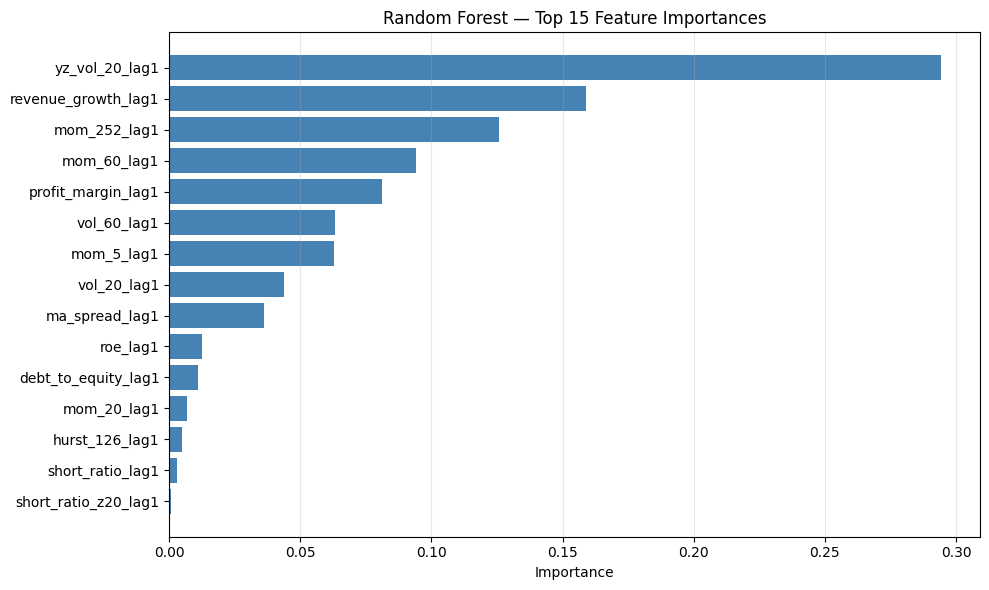

Cell 21: Chart saved to rf_feature_importance_v12.png


In [25]:
# =============================================================
# Cell 21 — Model Level 5: Random Forest
# =============================================================
# Level 4 supervised ML model. Captures non-linear interactions.
#
# WHY RF IN V11:
# With 19 features from 4 data sources, interaction effects
# become more plausible:
# - High short ratio + low momentum = stronger bearish signal
# - High ROE + high revenue growth = stronger quality signal
# - Fundamental signals may only matter in certain macro regimes
# RF can learn these interactions; linear models cannot.
#
# OVERFITTING CONTROLS (deliberately conservative):
# - max_depth=4:          shallow trees
# - min_samples_leaf=500: large minimum leaf size
# - n_estimators=100:     sufficient but not excessive
#
# Feature importances tell us which data sources the RF
# considers most informative — a key analytical finding.
# =============================================================

print("="*60)
print("Cell 21: MODEL 5 — Random Forest")
print("="*60)
print("Cell 21: Training Random Forest (1-2 minutes)...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=500,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(train_df[ALL_FEATURES], train_df["target"])
print("Cell 21: Training complete.")

train_df["pred_rf"] = rf_model.predict(train_df[ALL_FEATURES])
val_df["pred_rf"]   = rf_model.predict(val_df[ALL_FEATURES])

print("\nCell 20: --- IC Summary (Random Forest) ---")
ic_val_rf = compute_daily_ic(val_df, pred_col="pred_rf")
ic_summary(ic_val_rf, "RandomForest Val")

print("\nCell 20: --- Feature Importances by Data Source ---")
importances = pd.Series(rf_model.feature_importances_, index=ALL_FEATURES)
# Group by data source
groups = [
    ("Stock (momentum/vol)", STOCK_FEATURES),
    ("Macro/ETF",            MACRO_ETF_FEATURES),
    ("Short Volume",         SHORT_VOL_FEATURES),
    ("Fundamentals",         FUNDAMENTAL_FEATURES),
]
for grp_name, grp_cols in groups:
    avail = [c for c in grp_cols if c in ALL_FEATURES]
    grp_imp = importances[avail].sum()
    print(f"  {grp_name:<30}  Total importance: {grp_imp:.4f}")

print("\nCell 20: --- Top 10 individual features ---")
for feat, imp in importances.sort_values(ascending=False).head(10).items():
    bar = "█" * int(imp * 200)
    print(f"  {feat:<42}  {imp:.4f}  {bar}")

# Plotted version of feature importances (in addition to text above)
import matplotlib.pyplot as plt

print("\nCell 21: Plotting feature importances...")
top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_importances.index[::-1], top_importances.values[::-1], color="steelblue")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("Results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cell 21: Chart saved to rf_feature_importance_v12.png")


In [26]:
# =============================================================
# Cell 22 — Model Comparison Summary
# =============================================================
# Side-by-side comparison of all five models on validation set.
# Higher ICIR (not just IC mean) is preferred — consistency
# matters more than a few exceptional days.
#
# V11 vs V10 comparison:
# We expect IC values to improve due to new features (short vol,
# fundamentals). If they don't, the new features may not add
# cross-sectional predictive power on this dataset/period.
# Either finding is valid and worth reporting.
# =============================================================

print("="*60)
print("Cell 22: MODEL COMPARISON SUMMARY (Validation Set)")
print("="*60)
print(f"  {'Model':<20}  IC Mean   IC Std   ICIR     Hit Rate")
print("  " + "-"*55)

model_results = {}
for label, pred_col in [
    ("OLS",          "pred_ols"),
    ("Ridge",        "pred_ridge"),
    ("Lasso",        "pred_lasso"),
    ("ElasticNet",   "pred_en"),
    ("RandomForest", "pred_rf"),
]:
    ic_s = compute_daily_ic(val_df, pred_col=pred_col)
    if len(ic_s) == 0:
        print(f"  {label:<20}  (no valid IC)")
        continue
    mean_ic = ic_s.mean()
    std_ic  = ic_s.std()
    icir    = mean_ic / (std_ic + 1e-9)
    hit     = (ic_s > 0).mean()
    # v18: flag statistically invalid rows (v17's RF row was N=1)
    flag = "" if len(ic_s) >= 30 else f"  ← INVALID (N={len(ic_s)} days)"
    print(f"  {label:<20}  {mean_ic:+.5f}   {std_ic:.5f}  {icir:+.4f}  {hit:.1%}{flag}")
    model_results[label] = {"ic_mean":mean_ic,"icir":icir,"hit":hit,"ic_series":ic_s}

print("\nCell 21: IC values of 0.01-0.03 are typical for individual models.")
print("Cell 22: The forecast combination in Cell 23 aims to improve ICIR stability.")


Cell 22: MODEL COMPARISON SUMMARY (Validation Set)
  Model                 IC Mean   IC Std   ICIR     Hit Rate
  -------------------------------------------------------
  OLS                   +0.00517   0.14195  +0.0364  52.2%
  Ridge                 +0.00517   0.14195  +0.0364  52.2%
  Lasso                 +0.02480   0.12820  +0.1935  58.0%
  ElasticNet            +0.02899   0.13303  +0.2179  56.7%
  RandomForest          +0.00723   0.11808  +0.0612  50.2%

Cell 21: IC values of 0.01-0.03 are typical for individual models.
Cell 22: The forecast combination in Cell 23 aims to improve ICIR stability.


In [27]:
# =============================================================
# Cell 23 — Signal Selection (PRE-REGISTERED — replaces v17's
#           IC-weighted static combination)
# =============================================================
# v17 combined the five models with weights fitted to validation
# ICIR, and v16/v17 additionally re-fitted those weights through
# time ("dynamic combination"). Both are hypothesis-free: they
# select whatever worked recently, which is a recipe for fitting
# noise and an indefensible answer to "why these weights?".
#
# v18 REPLACES fitted combination weights with a pre-registered
# choice, stated before looking at out-of-sample results:
#
#   TRADED SIGNAL: walk-forward ElasticNet (Cell 24 → Cell 25).
#   WHY, A PRIORI:
#   - the feature set has correlated blocks (4 momentum horizons,
#     3 volatility measures): L2 stabilises within blocks, L1
#     prunes across them — exactly ElasticNet's design case;
#   - a linear model's coefficients can be audited for sign and
#     stability across retraining windows (Cell 27), so the
#     hypothesis test extends to the model's internals;
#   - Random Forest is retained as a NON-TRADED diagnostic for
#     non-linearity (if RF's OOS IC ≫ linear OOS IC, the linear
#     hypothesis is incomplete — that is the only claim it tests).
#
#   ROBUSTNESS CHECK (not a traded alternative): the 1/N average
#   of the four linear models. 1/N has NO fitted weights, so it
#   cannot chase recent performance; if the pre-registered
#   ElasticNet and 1/N disagree wildly out-of-sample, the choice
#   of linear model mattered more than the signal — worth knowing.
#
# This cell reports the validation-set ICs for the record. No
# weights are fitted, and nothing here feeds position sizing.
# =============================================================

print("=" * 60)
print("Cell 23: SIGNAL SELECTION (pre-registered — no fitted weights)")
print("=" * 60)

LINEAR_PRED_COLS = ["pred_ols", "pred_ridge", "pred_lasso", "pred_en"]

for df_split in [train_df, val_df]:
    df_split["pred_1n"] = df_split[LINEAR_PRED_COLS].mean(axis=1)

print("\nCell 23: --- Validation-set IC, for the record ---")
ic_summary(compute_daily_ic(val_df, pred_col="pred_en"),  "ElasticNet (traded)")
ic_summary(compute_daily_ic(val_df, pred_col="pred_1n"),  "1/N linear (robustness)")
ic_summary(compute_daily_ic(val_df, pred_col="pred_rf"),  "RandomForest (diagnostic)")

print("\nCell 23: Traded signal is fixed a priori: walk-forward ElasticNet.")
print("Cell 23: No IC-weighted or dynamic combination exists in v18.")


Cell 23: SIGNAL SELECTION (pre-registered — no fitted weights)

Cell 23: --- Validation-set IC, for the record ---
  ElasticNet (traded)        IC=+0.02899  Std=0.13303  ICIR=+0.218  Hit=56.7%  N=245
  1/N linear (robustness)    IC=+0.01284  Std=0.13597  ICIR=+0.094  Hit=52.7%  N=245
  RandomForest (diagnostic)  IC=+0.00723  Std=0.11808  ICIR=+0.061  Hit=50.2%  N=245

Cell 23: Traded signal is fixed a priori: walk-forward ElasticNet.
Cell 23: No IC-weighted or dynamic combination exists in v18.


In [28]:
# =============================================================
# Cell 24 — Multi-Model Walk-Forward Backtest
# =============================================================
# Proper out-of-sample evaluation via walk-forward retraining,
# for ALL FIVE models — not just ElasticNet.
#
# WHY THIS CHANGED FROM v12:
# v12 only walk-forward-tested ElasticNet, on the reasoning that
# it was "best balance of stability and signal." But that choice
# was itself made by looking at static validation-period IC
# (Cell 22's Model Comparison) — meaning the validation period
# was implicitly used twice: once to pick ElasticNet, and again
# inside the walk-forward that only tests ElasticNet. v15
# (a colleague's parallel version) identified this exact issue
# and proposed evaluating every model out-of-sample, then
# dynamically combining them — a more defensible research
# design, since model selection happens out-of-sample too.
#
# LOGIC:
# - Training window: 2 years (504 trading days)
# - Step: 21 trading days (~1 month)
# - At each step: fit ALL FIVE models on the past 2 years,
#   predict the next 21 days for each, roll forward
# - ElasticNet's coefficients are additionally tracked per
#   window (coef_history) for the stability chart in Cell 26 —
#   coefficients are only meaningful for linear models, so this
#   stays specific to ElasticNet even though all 5 models run.
#
# WHY ALL FIVE MODELS COSTS LITTLE EXTRA:
# OLS/Ridge/Lasso/ElasticNet are near-instant to fit even at
# this data volume. Random Forest is the slow one, but at
# n_estimators=50 (reduced from 100 used in the static ladder)
# the full loop still completes in a reasonable time.
#
# FEATURE AVAILABILITY NOTE:
# Early windows (2020-2021) won't have short interest data —
# moot here since short interest is excluded from ALL_FEATURES
# entirely (see Cell 13). Short volume / fundamentals (2021+)
# do constrain how far back usable windows start.
#
# OUTPUT: pred_df — canonical prediction dataset for the
# downstream dynamic combination (Cell 25) and portfolio
# construction. Contains one prediction column per model:
# pred_ols, pred_ridge, pred_lasso, pred_en, pred_rf.
# =============================================================

print("="*60)
print("Cell 24: MULTI-MODEL WALK-FORWARD BACKTEST")
print("="*60)

TRAIN_WINDOW = 504
STEP         = 21

df_wf = model_df.copy()
df_wf = df_wf.sort_values(["date","ticker"]).reset_index(drop=True)
unique_dates = np.sort(df_wf["date"].unique())

all_predictions = []
n_windows = 0
n_failed  = 0
coef_history = []   # tracks ElasticNet coefficients per window for stability analysis

print(f"Cell 24: Total trading days: {len(unique_dates)}")
print(f"Cell 24: Training window: {TRAIN_WINDOW} days | Step: {STEP} days")
print(f"Cell 24: Expected windows: ~{(len(unique_dates)-TRAIN_WINDOW)//STEP}")
print("Cell 24: Fitting 5 models per window: OLS, Ridge, Lasso, ElasticNet, RandomForest")
print("Cell 24: Running walk-forward loop...")

for i in range(TRAIN_WINDOW, len(unique_dates), STEP):
    n_windows += 1
    # v19 PURGE (lookahead fix): the H-day targets of the last H
    # training dates use returns INSIDE this window's test period —
    # exclude those dates from training (embargo).
    train_dates = unique_dates[i - TRAIN_WINDOW : i - TARGET_HORIZON]
    test_dates  = unique_dates[i : i + STEP]

    tr = df_wf[df_wf["date"].isin(train_dates)]
    te = df_wf[df_wf["date"].isin(test_dates)]

    if len(tr) < 5000 or len(te) < 50:
        n_failed += 1
        continue

    tr_clean = tr.dropna(subset=ALL_FEATURES + ["target"])
    te_clean = te.dropna(subset=ALL_FEATURES)

    if len(tr_clean) < 2000:
        n_failed += 1
        continue

    try:
        Xtr = tr_clean[ALL_FEATURES]
        ytr = tr_clean["target"]
        Xte = te_clean[ALL_FEATURES]

        te_out = te_clean.copy()

        # --- OLS ---
        m_ols = LinearRegression()
        m_ols.fit(Xtr, ytr)
        te_out["pred_ols"] = m_ols.predict(Xte)

        # --- Ridge (fixed alpha from static ladder, Cell 18) ---
        m_ridge = make_pipeline(StandardScaler(), Ridge(alpha=best_ridge_alpha))
        m_ridge.fit(Xtr, ytr)
        te_out["pred_ridge"] = m_ridge.predict(Xte)

        # --- Lasso (fixed alpha from static ladder, Cell 19) ---
        m_lasso = make_pipeline(StandardScaler(), Lasso(alpha=best_lasso_alpha, max_iter=5000))
        m_lasso.fit(Xtr, ytr)
        te_out["pred_lasso"] = m_lasso.predict(Xte)

        # --- ElasticNet (fixed params from static ladder, Cell 20) ---
        m_en = make_pipeline(
            StandardScaler(),
            ElasticNet(alpha=best_en_params[0], l1_ratio=best_en_params[1], max_iter=5000)
        )
        m_en.fit(Xtr, ytr)
        te_out["pred_en"] = m_en.predict(Xte)

        # --- Random Forest (reduced n_estimators for walk-forward speed) ---
        m_rf = RandomForestRegressor(
            n_estimators=50, max_depth=4, min_samples_leaf=500,
            n_jobs=-1, random_state=42
        )
        m_rf.fit(Xtr, ytr)
        te_out["pred_rf"] = m_rf.predict(Xte)

        all_predictions.append(te_out)

        # Capture ElasticNet coefficients for stability analysis (Cell 26)
        coef_history.append({
            "train_end": train_dates[-1],
            **dict(zip(ALL_FEATURES, m_en.named_steps["elasticnet"].coef_))
        })

        if n_windows % 5 == 0:
            print(f"  Cell 24: Window {n_windows}: train end "
                  f"{train_dates[-1].astype('datetime64[D]')} | test: {len(te_out)} rows")
    except Exception as e:
        print(f"  Cell 24: Window {n_windows} failed: {e}")
        n_failed += 1

pred_df = pd.concat(all_predictions, ignore_index=True)
pred_df = pred_df.sort_values(["date","ticker"]).reset_index(drop=True)

print(f"\nCell 24: Walk-forward complete.")
print(f"Cell 24: Windows run: {n_windows} | Failed: {n_failed}")
print(f"Cell 24: Prediction dataset: {pred_df.shape}")
print(f"Cell 24: Date range: {pred_df['date'].min().date()} → {pred_df['date'].max().date()}")

print("\nCell 24: --- Walk-Forward Out-of-Sample IC, per model ---")
wf_model_results = {}
for label, pred_col in [
    ("OLS",          "pred_ols"),
    ("Ridge",        "pred_ridge"),
    ("Lasso",        "pred_lasso"),
    ("ElasticNet",   "pred_en"),
    ("RandomForest", "pred_rf"),
]:
    ic_s = compute_daily_ic(pred_df, pred_col=pred_col)
    res = ic_summary(ic_s, f"WF {label} OOS")
    if res:
        wf_model_results[label] = {**res, "ic_series": ic_s}


Cell 24: MULTI-MODEL WALK-FORWARD BACKTEST
Cell 24: Total trading days: 1105
Cell 24: Training window: 504 days | Step: 21 days
Cell 24: Expected windows: ~28
Cell 24: Fitting 5 models per window: OLS, Ridge, Lasso, ElasticNet, RandomForest
Cell 24: Running walk-forward loop...
  Cell 24: Window 5: train end 2024-04-30 | test: 9114 rows
  Cell 24: Window 10: train end 2024-09-30 | test: 9172 rows
  Cell 24: Window 15: train end 2025-03-04 | test: 9280 rows
  Cell 24: Window 20: train end 2025-08-04 | test: 9450 rows
  Cell 24: Window 25: train end 2026-01-02 | test: 9534 rows

Cell 24: Walk-forward complete.
Cell 24: Windows run: 29 | Failed: 0
Cell 24: Prediction dataset: (266443, 85)
Cell 24: Date range: 2024-01-08 → 2026-06-01

Cell 24: --- Walk-Forward Out-of-Sample IC, per model ---
  WF OLS OOS                 IC=+0.00684  Std=0.15646  ICIR=+0.044  Hit=50.1%  N=601
  WF Ridge OOS               IC=+0.00684  Std=0.15646  ICIR=+0.044  Hit=50.1%  N=601
  WF Lasso OOS               IC

In [29]:
# =============================================================
# Cell 25 — Traded Signal Definition (replaces v17's dynamic
#           forecast combination)
# =============================================================
# v17's trailing-126-day ICIR re-weighting is REMOVED (see Cell
# 23 for the rationale). The traded signal is simply the
# pre-registered walk-forward ElasticNet prediction. The column
# is still named `pred_ensemble` so every downstream cell
# (rolling IC chart, portfolio construction, costs, summary)
# runs unchanged.
#
# Alongside it, two non-traded reference signals are evaluated
# on the SAME out-of-sample walk-forward window:
#   - 1/N average of the four linear models (no fitted weights)
#   - Random Forest (non-linearity diagnostic)
# If the pre-registered signal and 1/N diverge materially, model
# choice dominates the result; if RF materially beats the linear
# models, the linearity assumption is the binding constraint.
# Either finding is reported as-is.
# =============================================================

print("=" * 60)
print("Cell 25: TRADED SIGNAL — pre-registered walk-forward ElasticNet")
print("=" * 60)

pred_df = pred_df.sort_values(["date", "sec_id"]).reset_index(drop=True)

# Traded signal (pre-registered)
pred_df["pred_ensemble"] = pred_df["pred_en"]

# Non-traded references on the same OOS window
pred_df["pred_1n"] = pred_df[["pred_ols", "pred_ridge",
                              "pred_lasso", "pred_en"]].mean(axis=1)

print("\nCell 25: --- Out-of-sample IC (walk-forward window) ---")
ic_traded = compute_daily_ic(pred_df, pred_col="pred_ensemble")
ic_summary(ic_traded, "ElasticNet (TRADED)")
ic_summary(compute_daily_ic(pred_df, pred_col="pred_1n"), "1/N linear (reference)")
ic_summary(compute_daily_ic(pred_df, pred_col="pred_rf"), "RandomForest (diagnostic)")

if len(ic_traded) > 0:
    _tstat = ic_traded.mean() / (ic_traded.std() / np.sqrt(len(ic_traded)) + 1e-12)
    print(f"\nCell 25: Traded-signal IC t-stat: {_tstat:+.2f}"
          f"  (|t| < ~2 ⇒ IC not statistically distinguishable from zero;")
    print("Cell 25:  that finding, if it occurs, is reported as the result.)")


Cell 25: TRADED SIGNAL — pre-registered walk-forward ElasticNet

Cell 25: --- Out-of-sample IC (walk-forward window) ---
  ElasticNet (TRADED)        IC=+0.00957  Std=0.17536  ICIR=+0.055  Hit=53.1%  N=601
  1/N linear (reference)     IC=+0.00756  Std=0.16119  ICIR=+0.047  Hit=51.9%  N=601
  RandomForest (diagnostic)  IC=+0.00879  Std=0.12893  ICIR=+0.068  Hit=52.6%  N=601

Cell 25: Traded-signal IC t-stat: +1.34  (|t| < ~2 ⇒ IC not statistically distinguishable from zero;
Cell 25:  that finding, if it occurs, is reported as the result.)


Cell 26: Plotting rolling IC over the walk-forward period...


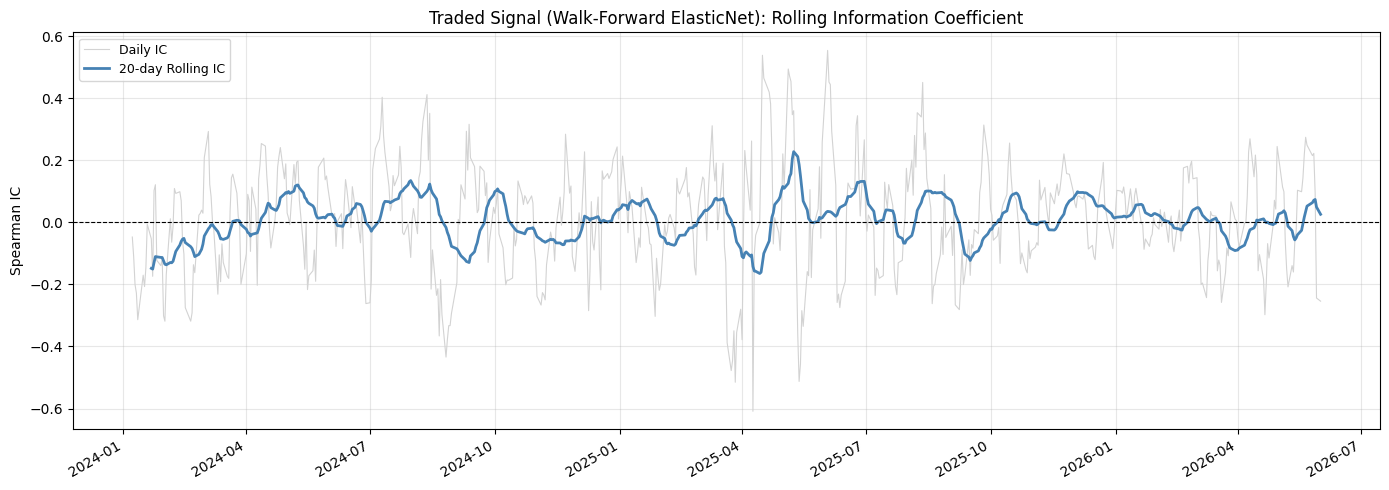

Cell 26: Chart saved to rolling_ic_v18.png
Cell 26: Percent of days with positive 20-day rolling IC: 57.4%


In [30]:
# =============================================================
# Cell 26 — Rolling IC Chart
# =============================================================
# Visualizes how the TRADED SIGNAL's (walk-forward ElasticNet)
# (IC) evolves over time. A healthy signal should hover
# consistently above zero. Sharp drops or sign flips indicate
# periods where the model's signal broke down -- useful for
# spotting regime changes or data quality issues.
# =============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Cell 26: Plotting rolling IC over the walk-forward period...")

ic_wf_series = compute_daily_ic(pred_df, pred_col="pred_ensemble")
rolling_ic_20d = ic_wf_series.rolling(20, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ic_wf_series.index, ic_wf_series.values,
        color="lightgray", linewidth=0.8, label="Daily IC")
ax.plot(rolling_ic_20d.index, rolling_ic_20d.values,
        color="steelblue", linewidth=2, label="20-day Rolling IC")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Traded Signal (Walk-Forward ElasticNet): Rolling Information Coefficient")
ax.set_ylabel("Spearman IC")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Results/rolling_ic.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cell 26: Chart saved to rolling_ic_v18.png")
print(f"Cell 26: Percent of days with positive 20-day rolling IC: {(rolling_ic_20d > 0).mean():.1%}")


Cell 27: Plotting coefficient stability across walk-forward windows...


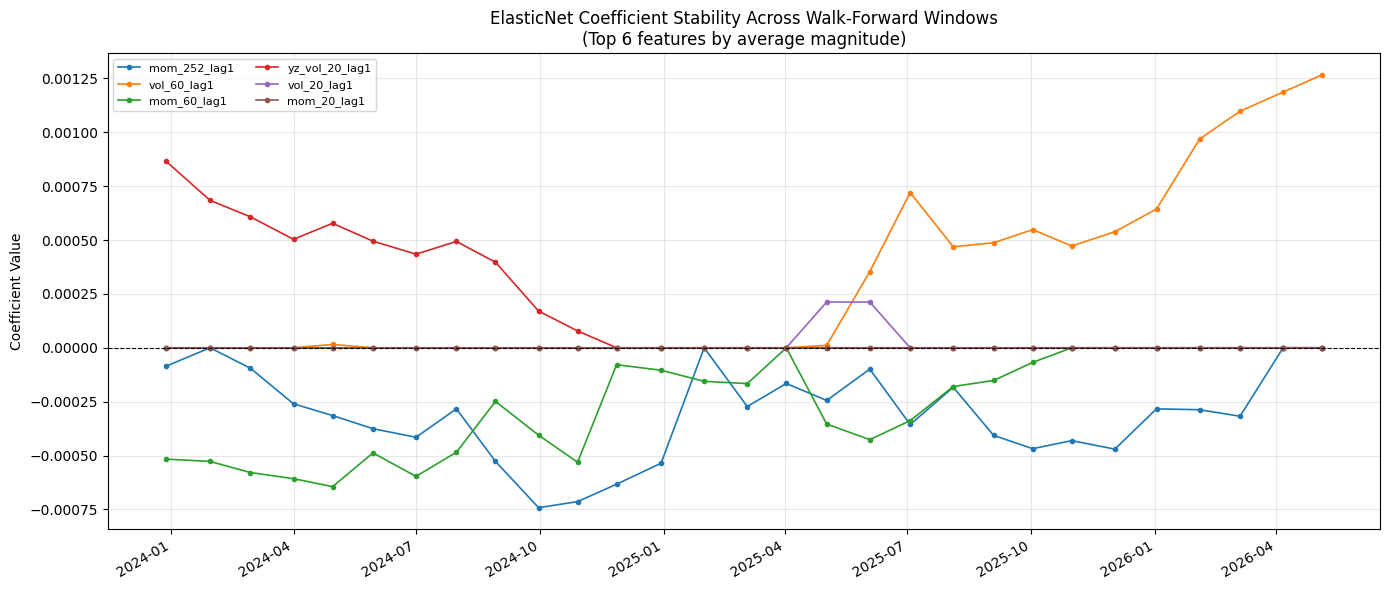

Cell 27: Chart saved to coefficient_stability_v12.png

Cell 27: Sign consistency check (% of windows where sign matches the most common sign):
  mom_5_lag1                 100.0% consistent
  mom_20_lag1                100.0% consistent
  mom_60_lag1                72.4% consistent
  mom_252_lag1               86.2% consistent
  vol_20_lag1                93.1% consistent
  vol_60_lag1                51.7% consistent
  ma_spread_lag1             100.0% consistent
  yz_vol_20_lag1             62.1% consistent
  hurst_126_lag1             100.0% consistent
  short_ratio_lag1           100.0% consistent
  short_ratio_z20_lag1       100.0% consistent
  short_ratio_chg5_lag1      100.0% consistent
  roe_lag1                   100.0% consistent
  profit_margin_lag1         100.0% consistent
  revenue_growth_lag1        100.0% consistent
  debt_to_equity_lag1        100.0% consistent


In [31]:
# =============================================================
# Cell 27 — Coefficient Stability Chart
# =============================================================
# The assignment explicitly states:
# "Coefficients produced should be relatively consistent
#  across time" (course material, Level 3 models section).
#
# This chart shows how each ElasticNet coefficient evolved
# across all walk-forward retraining windows. Stable,
# consistently-signed coefficients indicate a genuine, durable
# relationship. Coefficients that flip sign or swing wildly
# between windows suggest overfitting to short-term noise
# rather than a real structural signal.
# =============================================================

print("Cell 27: Plotting coefficient stability across walk-forward windows...")

coef_df = pd.DataFrame(coef_history).set_index("train_end")

# Plot the 6 features with the largest average absolute coefficient
top_features = coef_df.abs().mean().sort_values(ascending=False).head(6).index

fig, ax = plt.subplots(figsize=(14, 6))
for feat in top_features:
    ax.plot(coef_df.index, coef_df[feat], marker="o", markersize=3,
            linewidth=1.2, label=feat)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("ElasticNet Coefficient Stability Across Walk-Forward Windows\n"
             "(Top 6 features by average magnitude)")
ax.set_ylabel("Coefficient Value")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Results/coefficient_stability.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cell 27: Chart saved to coefficient_stability_v12.png")
print("\nCell 27: Sign consistency check (% of windows where sign matches the most common sign):")
for feat in ALL_FEATURES:
    if feat in coef_df.columns:
        signs = np.sign(coef_df[feat])
        most_common_sign = signs.mode()[0] if len(signs.mode()) > 0 else 0
        consistency = (signs == most_common_sign).mean()
        print(f"  {feat:<25}  {consistency:.1%} consistent")


In [32]:
# =============================================================
# Cell 28 — Portfolio Construction Level 2: Constant Gross Notional
# =============================================================
# Simplest valid long-short portfolio construction.
#
# LEVEL 2 FORMULA:
# weight_i = pred_ensemble_i / sum(|pred_ensemble_j|) across all stocks
# on each REBALANCE date. pred_ensemble is the pre-registered
# walk-forward ElasticNet signal (Cell 25).
#
# v19 REBALANCING & ANNUALISATION:
# The book is formed every REBALANCE_EVERY (=TARGET_HORIZON) trading
# days and earns the H-day period return fwd_ret_h — signal horizon and
# holding period now match. There are PERIODS_PER_YEAR (≈50)
# observations per year, and ALL annualised statistics in this and
# later cells use that factor. (The v18 run used √252 on these period
# returns, inflating every Sharpe by √5 ≈ 2.24 — the source of the
# suspicious "Sharpe ≈ 3".)
#
# This ensures:
# - Long stocks with positive predictions
# - Short stocks with negative predictions
# - Total gross exposure ≈ 1.0 each day
# - Approximately dollar-neutral
#
# PnL: weights formed at rebalance date t earn fwd_ret_h — the actual
# t→t+H return. We use the raw forward return, NOT the demeaned
# target, so the PnL reflects what a real book earns.
# =============================================================

print("="*60)
print("Cell 28: PORTFOLIO LEVEL 2 — Constant Gross Notional")
print("="*60)

df_port = pred_df.dropna(subset=["pred_ensemble","fwd_ret_h"]).copy()
rebalance_dates = np.sort(df_port["date"].unique())[::REBALANCE_EVERY]
df_port = df_port[df_port["date"].isin(rebalance_dates)].copy()
df_port = df_port.sort_values(["date","ticker"]).reset_index(drop=True)

df_port["weight_l2"] = df_port.groupby("date")["pred_ensemble"].transform(
    lambda x: x / (np.abs(x).sum() + 1e-9)
)
df_port["pnl_l2"] = df_port["weight_l2"] * df_port["fwd_ret_h"]
daily_l2 = df_port.groupby("date")["pnl_l2"].sum().sort_index()

sharpe_l2  = sharpe(daily_l2, PERIODS_PER_YEAR)   # v19: ~50 periods/yr, not 252
equity_l2  = (1 + daily_l2).cumprod()
max_dd_l2  = (equity_l2 / equity_l2.cummax() - 1).min()

df_port_s = df_port.sort_values(["sec_id","date"])   # v17: entity key
df_port_s["w_prev"] = df_port_s.groupby("sec_id")["weight_l2"].shift(1).fillna(0)
df_port_s["turnover"] = (df_port_s["weight_l2"] - df_port_s["w_prev"]).abs()
avg_turnover_l2 = df_port_s.groupby("date")["turnover"].sum().mean()

print(f"Cell 28: Sharpe (annualised, {PERIODS_PER_YEAR:.1f} periods/yr): {sharpe_l2:.4f}")
print(f"Cell 28: Mean period ({TARGET_HORIZON}d) return: {daily_l2.mean():.6f}")
print(f"Cell 28: Volatility (per period):    {daily_l2.std():.6f}")
print(f"Cell 28: Max drawdown:        {max_dd_l2:.4f}")
print(f"Cell 28: Total return:        {equity_l2.iloc[-1]-1:.4f}")
print(f"Cell 28: Rebalances:          {len(daily_l2)}")
print(f"Cell 28: Avg turnover per rebalance: {avg_turnover_l2:.4f}")

# ── v19: phase robustness ──
# Sampling every H-th day admits H different rebalance grids; the
# headline should not be an artifact of one arbitrary phase. Report all.
print(f"\nCell 28: Phase robustness (Sharpe by rebalance-grid offset):")
_all_d = np.sort(pred_df.dropna(subset=["pred_ensemble", "fwd_ret_h"])["date"].unique())
_phase_sharpes = []
for _ph in range(REBALANCE_EVERY):
    _sub = pred_df[pred_df["date"].isin(_all_d[_ph::REBALANCE_EVERY])].dropna(
        subset=["pred_ensemble", "fwd_ret_h"]).copy()
    _w = _sub.groupby("date")["pred_ensemble"].transform(
        lambda x: x / (np.abs(x).sum() + 1e-9))
    _p = (_w * _sub["fwd_ret_h"]).groupby(_sub["date"]).sum()
    _s = sharpe(_p, PERIODS_PER_YEAR)
    _phase_sharpes.append(_s)
    print(f"  Cell 28: phase {_ph}: Sharpe {_s:+.3f}  ({len(_p)} rebalances)")
print(f"  Cell 28: phase range: [{min(_phase_sharpes):+.3f}, {max(_phase_sharpes):+.3f}]"
      f"  — report the range, not the best phase.")


Cell 28: PORTFOLIO LEVEL 2 — Constant Gross Notional
Cell 28: Sharpe (annualised, 50.4 periods/yr): 0.7799
Cell 28: Mean period (5d) return: 0.000932
Cell 28: Volatility (per period):    0.008486
Cell 28: Max drawdown:        -0.0387
Cell 28: Total return:        0.1145
Cell 28: Rebalances:          121
Cell 28: Avg turnover per rebalance: 0.3378

Cell 28: Phase robustness (Sharpe by rebalance-grid offset):
  Cell 28: phase 0: Sharpe +0.780  (121 rebalances)
  Cell 28: phase 1: Sharpe +0.996  (120 rebalances)
  Cell 28: phase 2: Sharpe +1.042  (120 rebalances)
  Cell 28: phase 3: Sharpe +0.983  (120 rebalances)
  Cell 28: phase 4: Sharpe +0.633  (120 rebalances)
  Cell 28: phase range: [+0.633, +1.042]  — report the range, not the best phase.


In [33]:
# =============================================================
# Cell 29 — Portfolio Construction Level 4: Constant Volatility
# =============================================================
# Scales the Level 2 portfolio to target constant annualised vol.
#
# MECHANISM:
# 1. Estimate rolling 20-day portfolio volatility (lagged by 1 day)
# 2. Scale factor = target_vol_daily / rolling_vol
# 3. Cap scaling at 3x to prevent extreme leverage
#
# TARGET: 10% annualised volatility (institutional baseline)
#
# WHY THIS HELPS:
# The strategy's raw vol varies across market regimes.
# Vol targeting ensures consistent risk-taking day-to-day,
# which smooths the equity curve and can improve Sharpe.
# =============================================================

print("="*60)
print("Cell 29: PORTFOLIO LEVEL 4 — Constant Volatility Targeting")
print("="*60)

TARGET_VOL_ANN    = 0.10
# v19: per-PERIOD vol target (series is one obs per rebalance)
TARGET_VOL_PERIOD = TARGET_VOL_ANN / np.sqrt(PERIODS_PER_YEAR)

# rolling(20) = 20 REBALANCES ≈ 100 trading days of trailing vol,
# lagged one period (no lookahead)
daily_l2_vol  = daily_l2.rolling(20, min_periods=10).std().shift(1)
scale_factor  = (TARGET_VOL_PERIOD / (daily_l2_vol + 1e-9)).clip(upper=3.0).fillna(1.0)
daily_l4      = daily_l2 * scale_factor

sharpe_l4     = sharpe(daily_l4, PERIODS_PER_YEAR)   # v19
equity_l4     = (1 + daily_l4).cumprod()
max_dd_l4     = (equity_l4 / equity_l4.cummax() - 1).min()
realised_vol  = daily_l4.std() * np.sqrt(PERIODS_PER_YEAR)

print(f"Cell 29: Target vol (annualised):   {TARGET_VOL_ANN:.2%}")
print(f"Cell 29: Realised vol (annualised): {realised_vol:.4f}")
print(f"Cell 29: Sharpe (annualised):       {sharpe_l4:.4f}")
print(f"Cell 29: Mean period ({TARGET_HORIZON}d) return:     {daily_l4.mean():.6f}")
print(f"Cell 29: Max drawdown:              {max_dd_l4:.4f}")
print(f"Cell 29: Total return:              {equity_l4.iloc[-1]-1:.4f}")
print(f"\nCell 25: Level 2 Sharpe: {sharpe_l2:.4f}  →  Level 4 Sharpe: {sharpe_l4:.4f}")


Cell 29: PORTFOLIO LEVEL 4 — Constant Volatility Targeting
Cell 29: Target vol (annualised):   10.00%
Cell 29: Realised vol (annualised): 0.1161
Cell 29: Sharpe (annualised):       0.9842
Cell 29: Mean period (5d) return:     0.002268
Cell 29: Max drawdown:              -0.0730
Cell 29: Total return:              0.2944

Cell 25: Level 2 Sharpe: 0.7799  →  Level 4 Sharpe: 0.9842


In [34]:
# =============================================================
# Cell 30 — Portfolio Construction Level 5: Mean-Variance (CVXPY)
# =============================================================
# Daily Markowitz optimisation of the pre-registered signal.
#
# v18 CHANGES IN THIS CELL:
# (a) SOLVER FAILURES CARRY THE BOOK FORWARD. v17 silently
#     dropped failed days from the return series (147/834 days —
#     failures cluster on stressed/ill-conditioned covariance
#     days, so dropping them biases performance upward). v18
#     holds the previous day's weights on failed days, records
#     their PnL, and reports the carried-day count.
# (b) HORIZON-ALIGNED PnL: weights formed at t earn fwd_ret_1d
#     (the t→t+1 return), fixing v17's use of the t−1→t return.
# (c) μ is the pre-registered ElasticNet signal (continuous,
#     z-scored per day, clipped ±3, rescaled to ±0.5).
# Carried over from v17: dollar-neutrality, gross ≤ 1, ±2% per
# name, turnover ‖w−w_prev‖₁ ≤ 1.50/day, and the σ/√ADV
# liquidity cost term in the objective (median name = 10 bps).
#
# OBJECTIVE: Maximise μᵀw − γ·wᵀΣw − λᵀ|w − w_prev|
# RISK MODEL: 50% shrinkage toward scaled identity, 60-day
# lookback. SOLVER: ECOS with SCS fallback.
# =============================================================

print("=" * 60)
print("Cell 30: PORTFOLIO LEVEL 5 — Mean-Variance (CVXPY)")
print("=" * 60)
print("Cell 30: Running daily optimisation loop (10-20 minutes)...")

RISK_AVERSION     = 1.0
MAX_WEIGHT        = 0.02
SHRINKAGE         = 0.5
COV_LOOKBACK_DAYS = 60
MAX_TURNOVER      = 1.50
BASE_TC_BPS       = 10.0
USE_CONTINUOUS_MU = True

df_opt = pred_df.dropna(subset=["pred_ensemble", "fwd_ret_h"]).copy()
df_opt = df_opt.sort_values(["date", "sec_id"]).reset_index(drop=True)
# v19: keep the DAILY calendar for the covariance lookback; only the
# REBALANCE grid is subsampled. (In the v18 run, indexing the lookback
# on the subsampled grid silently stretched the "60-day" covariance
# window to 60 rebalances ≈ 300 trading days.)
all_daily_dates  = np.sort(df_opt["date"].unique())
unique_opt_dates = all_daily_dates[::REBALANCE_EVERY]

print(f"Cell 30: μ mode: {'CONTINUOUS z-scored signal' if USE_CONTINUOUS_MU else 'cross-sectional ranks'}")
print(f"Cell 30: Turnover cap {MAX_TURNOVER:.2f}/day | liquidity cost σ/√ADV, median name {BASE_TC_BPS:.0f} bps")
print("Cell 30: Solver failures carry the previous book forward (not dropped).")

results_l5   = []
failed_days  = 0     # solver failed AND no previous book existed → day skipped
carried_days = 0     # solver failed, previous book held for the day
prev_weights = {}    # sec_id -> weight from the previous day

for idx, date in enumerate(unique_opt_dates):
    day_df = df_opt[df_opt["date"] == date].copy()
    day_df = day_df.sort_values("sec_id").reset_index(drop=True)

    if len(day_df) < 30:
        failed_days += 1
        continue

    ids_today = day_df["sec_id"].values
    n = len(ids_today)

    # ── Expected returns μ (pre-registered signal) ──
    if USE_CONTINUOUS_MU:
        p  = day_df["pred_ensemble"]
        z  = ((p - p.mean()) / (p.std() + 1e-12)).clip(-3.0, 3.0)
        mu = (z / 3.0 * 0.5).values
    else:
        mu = (day_df["pred_ensemble"].rank() / n - 0.5).values

    # ── Covariance (shrinkage, 60-day lookback of realised returns) ──
    _pos = np.searchsorted(all_daily_dates, date)
    lookback_start = all_daily_dates[max(0, _pos - COV_LOOKBACK_DAYS)]
    hist = df_opt[
        (df_opt["date"] >= lookback_start) & (df_opt["date"] < date) &
        (df_opt["sec_id"].isin(ids_today))
    ]
    ret_matrix = (
        hist.pivot(index="date", columns="sec_id", values="ret")
        .reindex(columns=ids_today).fillna(0)
    )

    if ret_matrix.shape[0] < 10:
        sample_cov = np.eye(n) * (day_df["ret"].std() ** 2 + 1e-6)
    else:
        sample_cov = ret_matrix.cov().values
        sample_cov = (sample_cov + sample_cov.T) / 2
        min_eig = np.linalg.eigvalsh(sample_cov).min()
        if min_eig < 0:
            sample_cov += np.eye(n) * (-min_eig + 1e-6)

    diag_var = np.diag(sample_cov).mean()
    Sigma = (1 - SHRINKAGE) * sample_cov + SHRINKAGE * np.eye(n) * diag_var
    Sigma += 1e-6 * np.eye(n)

    # ── Per-name liquidity coefficients λᵢ ∝ σᵢ/√ADVᵢ ──
    sig = day_df["tc_sigma"].astype(float)
    adv = day_df["tc_adv"].astype(float).clip(lower=1e4)
    liq_raw = (sig / np.sqrt(adv)).replace([np.inf, -np.inf], np.nan)
    med_liq = liq_raw.median()
    if not np.isfinite(med_liq) or med_liq <= 0:
        lam = np.full(n, BASE_TC_BPS / 1e4)
    else:
        lam = (liq_raw.fillna(med_liq) / med_liq).values * (BASE_TC_BPS / 1e4)
    lam = np.clip(lam, 0.0, 10 * BASE_TC_BPS / 1e4)

    w_prev = np.array([prev_weights.get(s, 0.0) for s in ids_today])

    # ── Optimise ──
    w = cp.Variable(n)
    trades = w - w_prev
    objective = cp.Maximize(
        mu @ w
        - RISK_AVERSION * cp.quad_form(w, Sigma)
        - lam @ cp.abs(trades)
    )
    constraints = [
        cp.sum(w) == 0,
        cp.norm(w, 1) <= 1.0,
        w <= MAX_WEIGHT,
        w >= -MAX_WEIGHT,
        cp.norm(trades, 1) <= MAX_TURNOVER,
    ]
    prob = cp.Problem(objective, constraints)

    # v19: wider solver cascade — the v18 run failed on 29/121 days
    # (24%) with ECOS→SCS only; Clarabel handles this SOCP class more
    # robustly. Carry-forward still covers any residual failures.
    solved = False
    for _solver_name in ("CLARABEL", "ECOS", "SCS"):
        _solver = getattr(cp, _solver_name, None)
        if _solver is None:
            continue
        try:
            prob.solve(solver=_solver, verbose=False)
            if w.value is not None:
                solved = True
                break
        except Exception:
            continue

    if solved:
        w_val = w.value
    else:
        # v18: HOLD the previous book instead of dropping the day.
        # Names no longer in today's tradable set are treated as
        # closed at zero (documented simplification).
        if prev_weights:
            w_val = w_prev.copy()
            carried_days += 1
        else:
            failed_days += 1
            continue

    day_out = day_df.copy()
    day_out["weight_l5"] = w_val
    # horizon-aligned PnL: weights at rebalance t earn the t→t+H return
    day_out["pnl_l5"]    = w_val * day_df["fwd_ret_h"].values
    day_out["tc_lambda"] = lam
    results_l5.append(day_out)

    prev_weights = dict(zip(ids_today, w_val))

    if idx % 50 == 0:
        print(f"  Cell 30: {idx}/{len(unique_opt_dates)} dates"
              f" | carried: {carried_days} | skipped: {failed_days}")

if not results_l5:
    raise ValueError("Cell 30: No valid optimisation results.")

port_l5  = pd.concat(results_l5, ignore_index=True)
daily_l5 = port_l5.groupby("date")["pnl_l5"].sum().sort_index()

sharpe_l5 = sharpe(daily_l5, PERIODS_PER_YEAR)   # v19: ~50 periods/yr
equity_l5 = (1 + daily_l5).cumprod()
max_dd_l5 = (equity_l5 / equity_l5.cummax() - 1).min()

_p5 = port_l5.sort_values(["sec_id", "date"])
_p5["w_prev"]  = _p5.groupby("sec_id")["weight_l5"].shift(1).fillna(0)
_realised_turn = (_p5["weight_l5"] - _p5["w_prev"]).abs().groupby(_p5["date"]).sum()

print(f"\nCell 30: Optimisation complete.")
print(f"Cell 30: Solved: {len(daily_l5) - carried_days} | book carried forward:"
      f" {carried_days} | skipped (no book yet): {failed_days}")
print(f"\nCell 30: {'='*40}")
print("Cell 30: LEVEL 5 RESULTS")
print(f"Cell 30: {'='*40}")
print(f"Cell 30: Sharpe (annualised, {PERIODS_PER_YEAR:.1f} periods/yr): {sharpe_l5:.4f}")
print(f"Cell 30: Mean period ({TARGET_HORIZON}d) return: {daily_l5.mean():.6f}")
print(f"Cell 30: Volatility (per period): {daily_l5.std():.6f}")
print(f"Cell 30: Max drawdown:        {max_dd_l5:.4f}")
print(f"Cell 30: Total return:        {equity_l5.iloc[-1]-1:.4f}")
print(f"Cell 30: Rebalances:          {len(daily_l5)}")
print(f"Cell 30: Avg turnover per rebalance: {_realised_turn.mean():.4f}"
      f"  (cap = {MAX_TURNOVER:.2f}; binding on"
      f" {(_realised_turn > 0.98*MAX_TURNOVER).mean():.1%} of days)")


Cell 30: PORTFOLIO LEVEL 5 — Mean-Variance (CVXPY)
Cell 30: Running daily optimisation loop (10-20 minutes)...
Cell 30: μ mode: CONTINUOUS z-scored signal
Cell 30: Turnover cap 1.50/day | liquidity cost σ/√ADV, median name 10 bps
Cell 30: Solver failures carry the previous book forward (not dropped).
  Cell 30: 0/121 dates | carried: 0 | skipped: 0
  Cell 30: 50/121 dates | carried: 4 | skipped: 0
  Cell 30: 100/121 dates | carried: 16 | skipped: 0

Cell 30: Optimisation complete.
Cell 30: Solved: 103 | book carried forward: 18 | skipped (no book yet): 0

Cell 30: ========================================
Cell 30: LEVEL 5 RESULTS
Cell 30: ========================================
Cell 30: Sharpe (annualised, 50.4 periods/yr): 1.0425
Cell 30: Mean period (5d) return: 0.001983
Cell 30: Volatility (per period): 0.013504
Cell 30: Max drawdown:        -0.0693
Cell 30: Total return:        0.2570
Cell 30: Rebalances:          121
Cell 30: Avg turnover per rebalance: 0.4667  (cap = 1.50; bindin

In [35]:
# =============================================================
# Cell 31 — Transaction Cost Analysis
# =============================================================
# Cost sensitivity sweep for the Level 5 portfolio.
#
# v17 CHANGE (requested #3): the cost model is now LIQUIDITY-
# AWARE, using the same σᵢ/√ADVᵢ coefficient the optimizer used:
#
#   cost_t = Σᵢ |trade_i,t| × λᵢ,      λᵢ = (bps/1e4) × liqᵢ/median(liq)
#   liqᵢ  = tc_sigmaᵢ / √tc_advᵢ       (σ = 20d vol, ADV = 20d $volume,
#                                        both lagged 1 day — Cell 11)
#
# The sweep bps value is the cost of the MEDIAN-liquidity name;
# illiquid/high-vol names are charged proportionally more, very
# liquid mega-caps less. The old FLAT model (same bps for every
# name) is kept alongside for comparison — the gap between the
# two tells you how much of the book sits in expensive names.
#
# NOTE: still excludes short borrow cost and nonlinear (square-
# root) market impact (Level 6 would add these).
# The headline reported number is the LIQUIDITY-ADJUSTED 10 bps
# case, consistent with the λ used inside the optimizer.
# =============================================================

print("=" * 60)
print("Cell 31: TRANSACTION COST ANALYSIS (liquidity-aware)")
print("=" * 60)

port_l5_s = port_l5.sort_values(["sec_id", "date"])
port_l5_s["w_prev"] = (
    port_l5_s.groupby("sec_id")["weight_l5"].shift(1).fillna(0)
)
port_l5_s["trade"] = (port_l5_s["weight_l5"] - port_l5_s["w_prev"]).abs()

# liquidity multiplier: tc_lambda was calibrated in Cell 30 so the
# median name = BASE_TC_BPS. Divide it out to get a unit-median multiplier.
port_l5_s["liq_mult"] = port_l5_s["tc_lambda"] / (BASE_TC_BPS / 1e4)

daily_turnover_l5 = port_l5_s.groupby("date")["trade"].sum()
avg_turnover = daily_turnover_l5.mean()

# effective turnover: liquidity-weighted traded notional
port_l5_s["trade_liq"] = port_l5_s["trade"] * port_l5_s["liq_mult"]
daily_turnover_liq = port_l5_s.groupby("date")["trade_liq"].sum()

print(f"Cell 31: Average turnover per rebalance (Level 5): {avg_turnover:.4f}")
print(f"Cell 31: (~{avg_turnover * PERIODS_PER_YEAR:.1f}x annual portfolio turnover"
      f" — v19 fix: {PERIODS_PER_YEAR:.1f} rebalances/yr, not 252)")
print(f"Cell 31: Liquidity-weighted turnover per rebalance: {daily_turnover_liq.mean():.4f}")
print(f"Cell 31: (ratio to plain turnover = "
      f"{daily_turnover_liq.mean()/(avg_turnover+1e-12):.2f} — >1 means the book"
      f" trades disproportionately in illiquid/volatile names)\n")

print(f"Cell 31: {'Cost (bps, median name)':<26} {'Net Sharpe (flat)':<19}"
      f" {'Net Sharpe (liq-adj)':<21} {'Net Return (liq-adj)':<20}")
print("-" * 90)

for bps in [0, 5, 10, 20]:
    cost_rate = bps / 10_000
    # old flat model — every name costs the same
    daily_cost_flat = daily_turnover_l5 * cost_rate
    daily_net_flat  = (daily_l5 - daily_cost_flat).dropna()
    # NEW liquidity-adjusted model — σ/√ADV scaled per name
    daily_cost_liq  = daily_turnover_liq * cost_rate
    daily_net_liq   = (daily_l5 - daily_cost_liq).dropna()
    net_cum   = (1 + daily_net_liq).cumprod()
    net_total = net_cum.iloc[-1] - 1
    print(f"  Cell 31: {bps:<24} {sharpe(daily_net_flat, PERIODS_PER_YEAR):<19.4f}"
          f" {sharpe(daily_net_liq, PERIODS_PER_YEAR):<21.4f} {net_total:<20.4f}")

# headline: liquidity-adjusted, 10 bps median name
daily_net_10bps = (daily_l5 - daily_turnover_liq * 10 / 10_000).dropna()
sharpe_net      = sharpe(daily_net_10bps, PERIODS_PER_YEAR)   # v19
equity_net      = (1 + daily_net_10bps).cumprod()
max_dd_net      = (equity_net / equity_net.cummax() - 1).min()

print(f"\nCell 31: → Reported net Sharpe (liquidity-adjusted, 10 bps median"
      f" name): {sharpe_net:.4f}")


Cell 31: TRANSACTION COST ANALYSIS (liquidity-aware)
Cell 31: Average turnover per rebalance (Level 5): 0.4667
Cell 31: (~23.5x annual portfolio turnover — v19 fix: 50.4 rebalances/yr, not 252)
Cell 31: Liquidity-weighted turnover per rebalance: 0.5832
Cell 31: (ratio to plain turnover = 1.25 — >1 means the book trades disproportionately in illiquid/volatile names)

Cell 31: Cost (bps, median name)    Net Sharpe (flat)   Net Sharpe (liq-adj)  Net Return (liq-adj)
------------------------------------------------------------------------------------------
  Cell 31: 0                        1.0425              1.0425                0.2570              
  Cell 31: 5                        0.9194              0.8886                0.2135              
  Cell 31: 10                       0.7963              0.7347                0.1715              
  Cell 31: 20                       0.5503              0.4276                0.0917              

Cell 31: → Reported net Sharpe (liquidity-ad

In [36]:
# =============================================================
# Cell 32 — Final Performance Summary
# =============================================================
# Side-by-side comparison across all portfolio construction levels.
# This is the answer to the assignment question:
# "What is your final ROI/Sharpe?"
#
# We report Level 5 net-of-cost as our headline result.
#
# NOTE ON SHARPE:
# From course material: "Few PMs have Sharpe > 1. High Sharpes
# are not believable." If gross Sharpe is much above 1, we flag
# the survivorship bias fix in v11 and the limited sample period
# as potential explanations. Net Sharpe after costs is more
# representative of real-world performance.
# =============================================================

print("=" * 70)
print("Cell 32: FINAL PERFORMANCE SUMMARY")
print("=" * 70)

summary_data = {
    "Level 2 (Gross Notional)": daily_l2,
    "Level 4 (Vol Targeted)":   daily_l4,
    "Level 5 MV Gross":         daily_l5,
    "Level 5 MV Net (liq-adj 10bps)": daily_net_10bps,
}

print(f"\n{'Portfolio':<32} {'Sharpe':>8} {'Ann.Vol':>8} {'MaxDD':>8}"
      f" {'TotalRet':>10} {'WinRate':>8}")
print("-" * 78)

for label, series in summary_data.items():
    series = series.dropna()
    s  = sharpe(series, PERIODS_PER_YEAR)   # v19: period series
    v  = series.std() * np.sqrt(PERIODS_PER_YEAR)   # v19
    eq = (1 + series).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    tr = eq.iloc[-1] - 1
    wr = (series > 0).mean()
    print(f"  {label:<30} {s:>8.3f} {v:>8.4f} {dd:>8.4f} {tr:>10.4f} {wr:>8.1%}")

# ── v17 (change #2): Sharpe by calendar year ──
print("\n" + "=" * 70)
print("Cell 32: SHARPE BY YEAR")
print("=" * 70)
_years = sorted({d.year for s in summary_data.values() for d in s.dropna().index})
_hdr = f"  {'Portfolio':<32}" + "".join(f"{y:>9}" for y in _years)
print(_hdr)
print("  " + "-" * (len(_hdr) - 2))
for label, series in summary_data.items():
    s = series.dropna()
    by_year = s.groupby(s.index.year).apply(
        lambda x: sharpe(x, PERIODS_PER_YEAR) if len(x) >= 20 else np.nan
    )
    row = f"  {label:<32}"
    for y in _years:
        v = by_year.get(y, np.nan)
        row += f"{v:>9.2f}" if np.isfinite(v) else f"{'—':>9}"
    print(row)
print("\n  Note: years with < 20 rebalance periods in-sample are shown as '—'")
print("  (annualising a Sharpe from a short stub period is unreliable).")

print("\n" + "=" * 70)
print("Cell 32: HEADLINE RESULT — Level 5 MV (net of liquidity-adjusted costs,")
print("Cell 32:                   10 bps for the median-liquidity name)")
print(f"  Sharpe (annualised): {sharpe_net:.4f}")
print(f"  Max drawdown:        {max_dd_net:.4f}")
print(f"  Total return:        {equity_net.iloc[-1]-1:.4f}")
print("=" * 70)
print("\nCell 32: Limitations:")
print("  - Point-in-time constituents used (survivorship bias fixed vs v10)")
print("  - Cost model: linear sigma/sqrt(ADV)-scaled, 10bps median name")
print("    (excludes borrow cost and nonlinear square-root impact)")
print("  - Short interest available Dec 2022+ only (NaN → dropped before that)")
print("  - FRED macro lagged 1 day (full rigor requires vintage release dates)")


Cell 32: FINAL PERFORMANCE SUMMARY

Portfolio                          Sharpe  Ann.Vol    MaxDD   TotalRet  WinRate
------------------------------------------------------------------------------
  Level 2 (Gross Notional)          0.780   0.0602  -0.0387     0.1145    57.0%
  Level 4 (Vol Targeted)            0.984   0.1161  -0.0730     0.2944    57.0%
  Level 5 MV Gross                  1.042   0.0959  -0.0693     0.2570    57.9%
  Level 5 MV Net (liq-adj 10bps)    0.735   0.0960  -0.0693     0.1715    57.9%

Cell 32: SHARPE BY YEAR
  Portfolio                            2024     2025     2026
  -----------------------------------------------------------
  Level 2 (Gross Notional)             0.36     0.94     1.12
  Level 4 (Vol Targeted)               0.88     0.95     1.23
  Level 5 MV Gross                     0.87     1.29     0.78
  Level 5 MV Net (liq-adj 10bps)       0.43     1.05     0.57

  Note: years with < 20 rebalance periods in-sample are shown as '—'
  (annualising a S

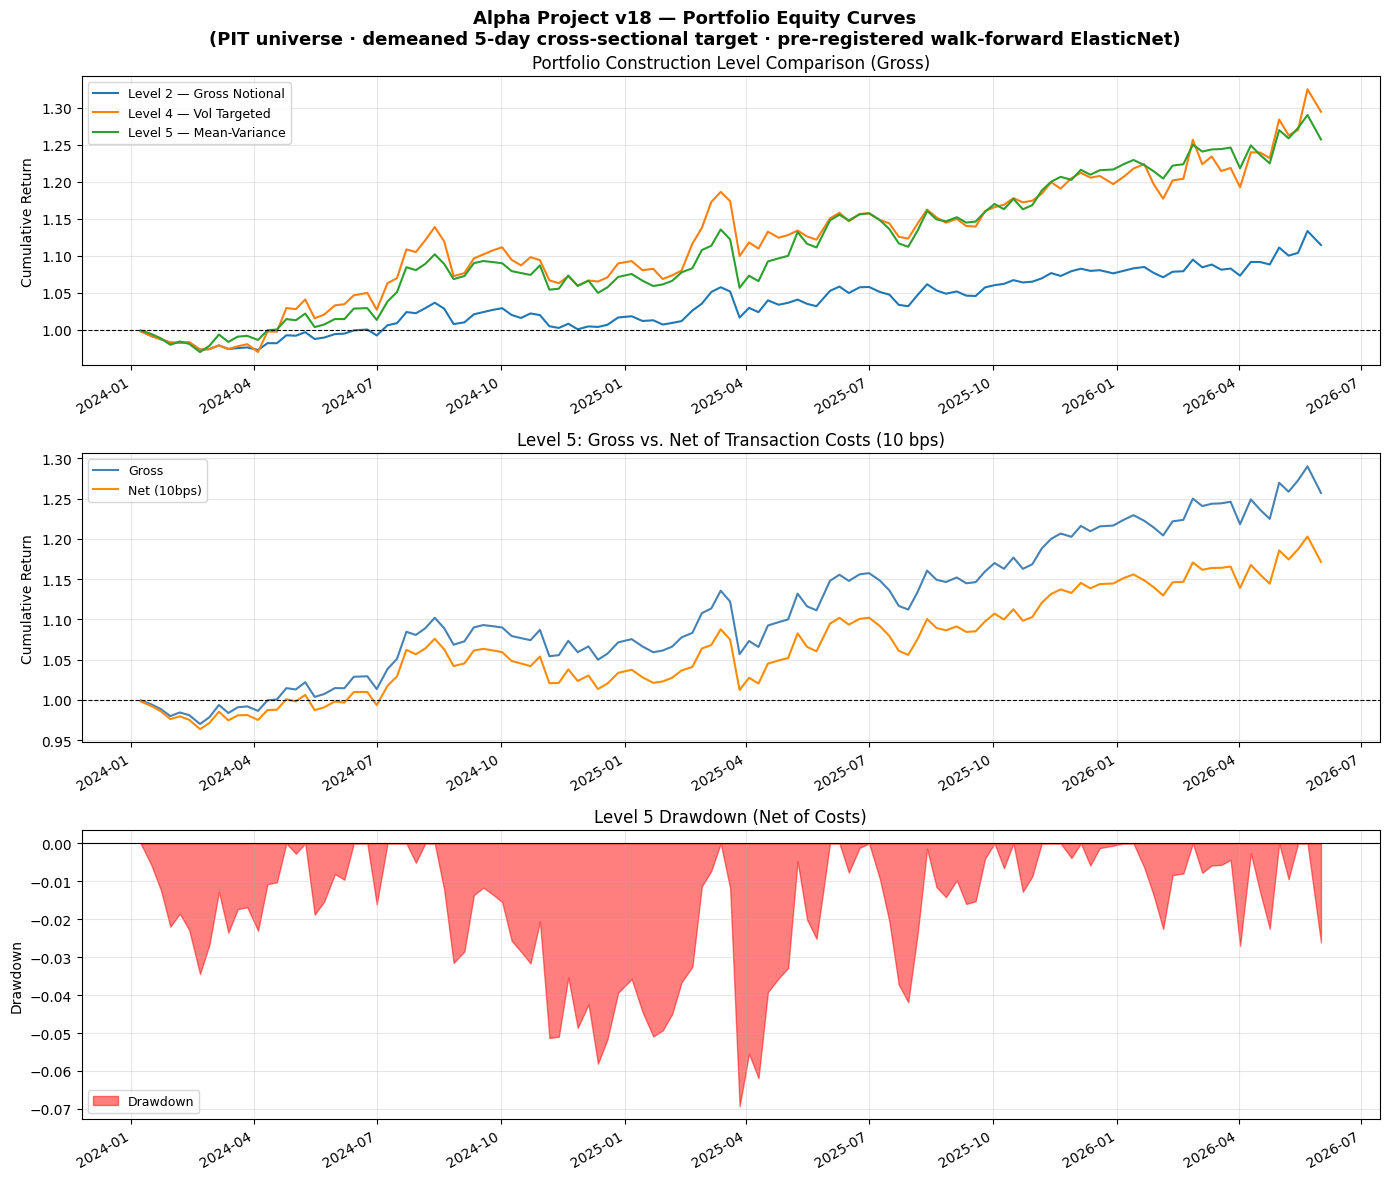

Cell 33: Chart saved to equity_curves_v18.png


In [37]:
# =============================================================
# Cell 33 — Equity Curve Visualisation
# =============================================================
# Three-panel chart:
# 1. Portfolio construction level comparison (gross)
# 2. Level 5 gross vs net of costs
# 3. Level 5 drawdown profile (net)
# =============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Alpha Project v18 — Portfolio Equity Curves\n"
             "(PIT universe · demeaned 5-day cross-sectional target · pre-registered walk-forward ElasticNet)",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.set_title("Portfolio Construction Level Comparison (Gross)")
for label, series in [
    ("Level 2 — Gross Notional", daily_l2),
    ("Level 4 — Vol Targeted",   daily_l4),
    ("Level 5 — Mean-Variance",  daily_l5),
]:
    eq = (1 + series.dropna()).cumprod()
    ax1.plot(eq.index, eq.values, label=label, linewidth=1.5)
ax1.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax1.legend(loc="upper left", fontsize=9)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_title("Level 5: Gross vs. Net of Transaction Costs (10 bps)")
eq_gross = (1 + daily_l5.dropna()).cumprod()
eq_net   = (1 + daily_net_10bps.dropna()).cumprod()
ax2.plot(eq_gross.index, eq_gross.values, label="Gross", linewidth=1.5, color="steelblue")
ax2.plot(eq_net.index,   eq_net.values,   label="Net (10bps)", linewidth=1.5, color="darkorange")
ax2.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax2.legend(loc="upper left", fontsize=9)
ax2.set_ylabel("Cumulative Return")
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.set_title("Level 5 Drawdown (Net of Costs)")
eq_net_dd = eq_net / eq_net.cummax() - 1
ax3.fill_between(eq_net_dd.index, eq_net_dd.values, 0,
                 alpha=0.5, color="red", label="Drawdown")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.legend(loc="lower left", fontsize=9)
ax3.set_ylabel("Drawdown")
ax3.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("Results/equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cell 33: Chart saved to equity_curves_v18.png")


In [38]:
# =============================================================
# Cell 34 — Paper Trading — Signal Generation
# =============================================================
# Generates live target positions for today using the v18
# pipeline: point-in-time universe, residualized cross-sectional
# features, the PRE-REGISTERED ElasticNet retrained on the last
# 2 years (predicting the demeaned 5-day forward return), and
# Level 5 CVXPY construction.
#
# IN PRODUCTION: run this cell daily on a scheduler.
# Output feeds into a broker API or EMS.
# Fill assumption: execution at next-day close price.
#
# SOLVER: SCS used for robustness (no ECOS dependency issue).
# =============================================================

print("="*60)
print("Cell 34: PAPER TRADING — SIGNAL GENERATION")
print("="*60)

latest_date = model_df["date"].max()
print(f"Cell 34: Most recent date in dataset: {latest_date.date()}")

paper_train_start = latest_date - pd.DateOffset(years=2)
paper_train = model_df[
    (model_df["date"] >= paper_train_start) &
    (model_df["date"] < latest_date)
].dropna(subset=ALL_FEATURES + ["target"])

print(f"Cell 34: Training window: {paper_train['date'].min().date()} → {paper_train['date'].max().date()}")
print(f"Cell 34: Training rows: {len(paper_train):,}")

if len(paper_train) < 2000:
    print("Cell 34: WARNING — Insufficient training data.")
else:
    paper_model = make_pipeline(
        StandardScaler(),
        ElasticNet(alpha=best_en_params[0], l1_ratio=best_en_params[1], max_iter=5000)
    )
    paper_model.fit(paper_train[ALL_FEATURES], paper_train["target"])
    print("Cell 34: Model retrained on latest 2-year window.")

    paper_today = model_df[model_df["date"] == latest_date].dropna(subset=ALL_FEATURES).copy()
    print(f"Cell 34: Stocks with valid features on {latest_date.date()}: {len(paper_today)}")

    if len(paper_today) < 30:
        print("Cell 34: WARNING — Too few stocks with valid features today.")
    else:
        paper_today["pred"] = paper_model.predict(paper_today[ALL_FEATURES])

        n_pt = len(paper_today)
        paper_today = paper_today.sort_values("sec_id").reset_index(drop=True)
        # v17 (change 0.5): continuous forecasts instead of ranks —
        # same transform as the backtest optimizer (Cell 30)
        _p = paper_today["pred"]
        _z = ((_p - _p.mean()) / (_p.std() + 1e-12)).clip(-3.0, 3.0)
        mu_pt = _z / 3.0 * 0.5

        recent_rets = model_df[
            (model_df["date"] >= latest_date - pd.DateOffset(days=30)) &
            (model_df["sec_id"].isin(paper_today["sec_id"]))
        ].pivot(index="date", columns="sec_id", values="ret").fillna(0)

        cov_pt = recent_rets.reindex(columns=paper_today["sec_id"]).cov().values
        cov_pt = (cov_pt + cov_pt.T) / 2 + 1e-5 * np.eye(n_pt)

        w_pt = cp.Variable(n_pt)
        prob_pt = cp.Problem(
            cp.Maximize(mu_pt.values @ w_pt - RISK_AVERSION * cp.quad_form(w_pt, cov_pt)),
            [cp.sum(w_pt) == 0, cp.norm(w_pt, 1) <= 1.0,
             w_pt <= MAX_WEIGHT, w_pt >= -MAX_WEIGHT]
        )
        # Use SCS for robustness (no ECOS install required)
        prob_pt.solve(solver=cp.SCS, verbose=False)

        if w_pt.value is not None:
            paper_today["target_weight"] = w_pt.value
            paper_today["direction"] = paper_today["target_weight"].apply(
                lambda x: "LONG" if x > 0.001 else ("SHORT" if x < -0.001 else "FLAT")
            )
            orders = paper_today[paper_today["direction"] != "FLAT"][
                ["ticker","target_weight","direction","pred"]
            ].sort_values("target_weight", ascending=False)

            print(f"\nCell 30: Paper Trading Orders for {latest_date.date()}:")
            print(f"Cell 34:   Long positions:  {(orders['direction']=='LONG').sum()}")
            print(f"Cell 34:   Short positions: {(orders['direction']=='SHORT').sum()}")
            print("\nCell 30: Top 10 Long positions:")
            print(orders[orders["direction"]=="LONG"].head(10).to_string(index=False))
            print("\nCell 30: Top 10 Short positions:")
            print(orders[orders["direction"]=="SHORT"].tail(10).to_string(index=False))
        else:
            print("Cell 34: Optimisation failed for paper trading date.")


Cell 34: PAPER TRADING — SIGNAL GENERATION
Cell 34: Most recent date in dataset: 2026-06-01
Cell 34: Training window: 2024-06-03 → 2026-05-29
Cell 34: Training rows: 222,310
Cell 34: Model retrained on latest 2-year window.
Cell 34: Stocks with valid features on 2026-06-01: 458

Cell 30: Paper Trading Orders for 2026-06-01:
Cell 34:   Long positions:  25
Cell 34:   Short positions: 25

Cell 30: Top 10 Long positions:
ticker  target_weight direction     pred
   CDW       0.020000      LONG 0.003389
   STX       0.020000      LONG 0.002961
  INTU       0.020000      LONG 0.004082
  ORCL       0.020000      LONG 0.003029
   IBM       0.020000      LONG 0.003000
    MU       0.020000      LONG 0.005222
   CNC       0.020000      LONG 0.002992
  DELL       0.020000      LONG 0.005222
   NOW       0.020000      LONG 0.004581
  SBAC       0.020000      LONG 0.002800

Cell 30: Top 10 Short positions:
ticker  target_weight direction      pred
   REG      -0.020000     SHORT -0.002624
   USB    

## Cell 35 — Assumptions, Limitations & Next Steps

### What Changed from v15 → v16

| Change | Impact |
|---|---|
| Fixed residualization (Cell 10) | v15's residualization cell was commented out entirely and never ran; it also used an invalid cross-sectional-per-date approach (the market factor has zero variance within a single day, so it cannot be regressed against that way). v16 restores the working per-ticker (time-series) version from v12, confirmed via a post-residualization correlation check landing at ~0.00000 |
| Multi-model walk-forward (Cell 22) | All 5 models are now walk-forward tested out-of-sample, not just whichever model looked best on the single static validation period — removes a subtle look-ahead in how the "best" model was chosen |
| Dynamic forecast combination (Cell 23) | v15 documented but never implemented trailing-IC ensemble weighting (the actual code was a stub aliasing the ensemble to one model). v16 implements it: weights are recomputed at every out-of-sample date from only the trailing 126 days, so the ensemble adapts as relative model performance changes, with zero use of future information |
| Coefficient stability chart fixed (Cell 25) | v15 broke this by switching its walk-forward to Random Forest-only (no `.coef_` attribute) without adapting the chart, causing a `KeyError` crash. v16's multi-model walk-forward keeps fitting ElasticNet alongside the other models specifically so coefficient tracking keeps working |

### What Changed from v11 → v12 (carried forward)

| Change | Impact |
|---|---|
| Residualization against market factor (Cell 10) | Stock features (momentum, vol, ma_spread) isolate stock-specific signal from broad market movement, addressing the concern that Random Forest importance was dominated by spy_tlt/hyg_tlt regime signals |
| Rolling IC chart (Cell 24) | Visualizes the dynamic ensemble's signal stability over time instead of only reporting a single summary statistic |
| Coefficient stability chart (Cell 25) | Directly addresses the assignment requirement that "coefficients should be relatively consistent across time" with a concrete visual and a sign-consistency metric |
| Plotted feature importance (Cell 19) | Random Forest importances have a proper bar chart in addition to the text-based view |

### What Changed from v10 → v11 (carried forward)

| Change | Impact |
|---|---|
| Point-in-time S&P 500 constituents | Eliminates survivorship bias — results are more conservative and realistic |
| Short volume features (3 signals) | Adds daily short-selling flow as a bearish signal |
| Short interest features (computed, but excluded from model) | Squeeze risk signal explored but not included — see below |
| Fundamental features (4 signals) | Adds quality and growth factors (ROE, margin, revenue growth, D/E) |
| 19 features total vs 12 in v10 | Richer signal set, but more opportunity for overfitting |

### Assumptions Made

| Assumption | Justification | Limitation |
|---|---|---|
| Point-in-time constituents from history file | Eliminates survivorship bias directly | History file records change dates only; days between changes use forward-fill |
| Short interest excluded from `ALL_FEATURES` entirely | Only 180/570+ tickers covered, starting Dec 2022 — including it in the global feature dropna previously collapsed the entire training set to ~19 days. Excluding it preserves the full multi-year training window for all other features | Short interest's potential predictive value (squeeze risk) is not captured by the model. Feature-level IC audit (Cell 16) on the brief overlap period showed negative IC, suggesting limited value even if coverage were fuller |
| Residualize stock features against spy_tlt only (per ticker, not sector or size) | Market beta is the single largest source of unwanted correlation in our feature set; per-ticker time-series regression is the mathematically valid way to estimate and remove it | A full Fama-French residualization (size, value, sector) would more completely isolate idiosyncratic signal; this is a simplified one-factor version |
| Multi-model walk-forward fits all 5 models every window | Avoids selecting "the best model" using validation data and then only testing that model out-of-sample, which double-uses the same information | 5x the per-window computation cost vs a single-model walk-forward; Random Forest uses reduced `n_estimators=50` (vs 100 in the static ladder) specifically to keep this tractable |
| Dynamic ensemble uses a 126-day (~6 month) trailing lookback for IC weighting | Long enough to estimate ICIR with reasonable stability, short enough to actually adapt to changing model performance | The lookback length itself is a parameter choice not tuned via cross-validation; a shorter or longer window could plausibly perform differently |
| Fundamentals lagged 1 day | Conservative safety margin | True lag is quarterly; full rigor needs earnings release dates |
| 10 bps execution cost | Realistic for S&P 500 institutional trading | Excludes short borrow cost and nonlinear market impact |
| FRED macro lagged 1 day | Prevents lookahead | CPI published ~2 weeks after month-end; 1-day lag is insufficient for CPI |
| 67/637 historical tickers (10.5%) missing price data | Yahoo Finance has no data for delisted/acquired/renamed tickers (e.g. TWTR, ANTM, ATVI) | Reintroduces a small residual survivorship-style gap for these specific names, despite the point-in-time constituent filter being correctly applied |

### Honest Limitations
- Short interest only covers **180 symbols** from Dec 2022 onwards — too sparse to include in the model without destroying earlier training data, so it is computed but excluded from `ALL_FEATURES`
- Fundamental data covers **633 symbols** — good but not complete coverage
- The historical constituent file records **change dates only** (~96 rows from 2020) — days between changes are forward-filled, which is correct but means very frequent intra-period additions/removals may have a small delay
- Survivorship bias is reduced but **not eliminated** — the history file itself may have gaps, and 67 tickers could not be downloaded at all
- Residualization is single-factor (market only) — does not control for sector or size effects
- The multi-model walk-forward is meaningfully slower than v12's single-model version, since it fits 5 models per window instead of 1 — expect noticeably longer runtime on Cell 22
- The dynamic ensemble's 126-day lookback, like any lookback length choice, is a judgment call rather than something formally optimized

### Next Steps
1. **Earnings release dates** — Use FRED vintage API or Compustat release dates to properly lag fundamental data
2. **Sector neutrality** — Add sector constraints to CVXPY to prevent unintended sector bets
3. **Multi-factor residualization** — Extend Cell 10 to also residualize against size and sector factors, not just market beta
4. **Expand short interest coverage** — Source data covering all 500+ S&P 500 stocks would make it viable to include without the dropna tradeoff; could also try a separate "short interest available" indicator + zero-fill instead of dropna-exclusion
5. **Level 6 portfolio** — Add square-root market impact model to CVXPY objective
6. **Live paper trading scheduler** — Automate Cell 32 to run daily and log results vs actual market moves
7. **Ticker rename mapping** — Build a lookup table for tickers that changed symbols (e.g. ANTM→ELV, DISCA→WBD) to recover some of the 67 currently-missing historical names
8. **Tune the dynamic ensemble's lookback window** — Test 63-day (~3 month) and 252-day (~1 year) lookbacks against the current 126-day choice to see how sensitive the dynamic weights are to this parameter
9. **Track Random Forest feature importance across walk-forward windows** — Cell 25 currently only tracks ElasticNet coefficients (the only model with a clean linear `.coef_`); an analogous stability check for RF's `feature_importances_` across windows would extend the same "is this signal durable or noise" question to the non-linear model


---

### What Changed from v16 → v17

| Change | Impact |
|---|---|
| CIK entity key (Cell 2b, used throughout) | Renamed companies (FB→META, ANTM→ELV, …) are one continuous entity via `sec_id = CIK:canonical_ticker`; joins to short-vol / fundamentals survive renames. Pure CIK alone can't be the row key because multi-class listings (GOOG/GOOGL, BRK-A/BRK-B) share one CIK — the ticker suffix keeps classes distinct. Caveat: price series across a rename boundary may carry a level artifact in long-horizon features (mom_252) |
| Turnover constraint in the MVO (Cell 30) | `‖w − w_prev‖₁ ≤ 1.50` per day (configurable). v16 had no turnover control; the optimizer now trades a persistent book instead of rebuilding it daily |
| Continuous µ in the optimizer (Cells 30, 34) | The optimizer sizes by z-scored continuous forecasts (clipped ±3), not just rank order. `USE_CONTINUOUS_MU=False` restores v16 behaviour |
| σ/√ADV liquidity term (Cells 5, 11, 30, 31) | Per-name Almgren-style linear impact coefficient λᵢ ∝ σᵢ/√(dollar ADVᵢ), normalised so the median name costs 10 bps per unit traded; enters the optimizer objective and the cost analysis. Untransformed `tc_sigma` / `tc_adv` copies are carried through Cell 11 so they escape the feature z-scoring |
| Sharpe by year (Cell 32) | Per-calendar-year Sharpe for each portfolio level — shows whether performance is concentrated in one regime |
| Hurst exponent factor (Cell 5b) | Rolling 126-day aggregated-variance Hurst estimator, recomputed weekly and ffilled for speed; distinguishes trending (H>0.5) from mean-reverting (H<0.5) names |
| Yang-Zhang volatility factor (Cell 5) | 20-day range-based OHLC vol — more efficient than close-to-close vol at the same window; added to the feature set alongside vol_20/vol_60 |
| Optional fundamental-factor residualization (Cells 12b, 13) | `RESIDUALIZE_VS_FUNDAMENTALS=True` cross-sectionally neutralises all stock features against ROE / margin / revenue growth / D-to-E per date, and drops fundamentals from `ALL_FEATURES` — a feature set containing no fundamental data, with fundamentals acting purely as risk factors. Off by default |

### v17 known limitations / notes
- The SEC ticker→CIK file maps **current** tickers only; old symbols rely on the manual `TICKER_RENAME_MAP` (extend it as more renames are found). Unmapped tickers fall back to a synthetic `NOCIK:` id — they still work, just without rename stability.
- Names dropping out of the tradable universe are treated as closed at zero cost in the optimizer's `w_prev` book (simplification).
- The Hurst estimator is recomputed every 5 days and forward-filled — a runtime/precision trade-off.
- λ = σ/√ADV is a **relative** liquidity scaling calibrated so the median name costs the base bps; it is not a NAV-aware participation model (a square-root impact model with an explicit portfolio size would be the Level 6 upgrade).


---

### What Changed from v17 → v18 (final)

| Change | Why |
|---|---|
| Target = per-date **demeaned 5-day forward return** (Cell 11, `TARGET_HORIZON` in Cell 1) | Removes the common market component from the target, so models can only score by *ranking stocks*, not timing the market; 5-day horizon chosen a priori on turnover economics (v17's 1-day horizon implied ~114x annual turnover, unsurvivable at realistic costs) |
| **Macro/ETF features removed from `ALL_FEATURES`** (Cell 13) | Identical for every stock within a day ⇒ zero cross-sectional ranking information by construction; their presence turned the RF into a market timer with constant within-day predictions (v17's "IC=+0.12, N=1" artifact). Retained only as the residualization factor and regime context |
| **Dynamic / IC-weighted combinations removed** (Cells 23, 25) | Trailing-ICIR weighting had no economic hypothesis — it selected whatever worked recently. Traded signal is one pre-registered model: walk-forward ElasticNet. 1/N linear average kept as a no-fitted-weights robustness check; RF kept as a non-traded non-linearity diagnostic |
| **Explicit feature hypotheses with expected signs** (intro table + Cell 16 check) | Every feature now has a stated directional hypothesis, checked against realised training IC — the audit reports agreement/disagreement rather than mining |
| **Horizon-aligned PnL** via `fwd_ret_1d` (Cells 11, 28, 30) | v17 credited weights formed at *t* with the *t−1→t* return; v18 portfolios earn the *t→t+1* return |
| **Solver failures carry the book forward** (Cell 30) | v17 dropped 147/834 days; failures cluster on stressed days, so dropping them was upward selection bias. v18 holds the previous book and reports carried-day counts |
| **Invalid-IC guard** (Cell 15) | IC summaries computed on < 30 valid days are flagged INVALID (v17's RF validation IC was one day) |
| **Rename map extended + canonical-symbol download fallback** (Cells 2b, 3) | Recovers price history for renamed names that failed in v17 (BLL→BALL, WLTW→WTW, CTL→LUMN, FLT→CPAY, PEAK→DOC, NLOK→GEN, CDAY→DAY, COG→CTRA, ADS→BFH, GPS→GAP). **Verify each mapping before publishing** — these were added from memory of corporate actions |
| Fundamental-residualization flag default **False** (Cell 12b) | Fundamentals enter as hypothesis-carrying features by default; the factor-neutralised variant remains one flag away |

### Interpretation guardrails for the write-up
- The **traded-signal OOS IC and its t-stat (Cell 25)** are the primary result. If |t| < 2, the honest headline is "no statistically significant cross-sectional signal at the weekly horizon on this universe/period" — that is a legitimate, defensible finding.
- Gross Level-5 Sharpe must be read **jointly with the IC**: a positive Sharpe with ~zero IC indicates construction effects (low-vol tilt, caps, turnover anchoring), not forecast skill. Attribute it as such.
- The net-of-cost number uses the σ/√ADV liquidity model with a 10 bps median name — report gross and net side by side.
- Remaining known gaps: ~10% of historical tickers still lack price data (acquired/delisted names with no successor symbol); borrow costs and nonlinear impact are not modelled; CPI/UNRATE use a 1-day lag rather than vintage release dates (macro now affects only residualization, not features).
- **Before publishing:** rotate or remove the FRED API key in Cell 1, and verify the entries added to `TICKER_RENAME_MAP`.


---

### v18-run audit → v19 corrections (each item: erroneous statement → fix)

| # | Erroneous statement / defect in the v18 run | v19 correction |
|---|---|---|
| 1 | **"Sharpe (annualised): 2.93 / 2.29 / 2.05 / 2.27"** — period returns are 5-day (≈50/yr) but `sharpe()` annualised with √252, inflating every portfolio Sharpe by √5 ≈ 2.24. True v18-run values ≈ 1.31 gross / 1.02 net / 0.92 / 1.01 | `PERIODS_PER_YEAR = 252/TARGET_HORIZON` (Cell 1); every portfolio-series `sharpe()` call now passes it (Cells 28, 29, 30, 31, 32) |
| 2 | **"Ann.Vol 0.22"** (Cell 32) — same error: `std × √252` on 5-day returns, overstated ×√5 (true ≈ 0.10) | `std × √PERIODS_PER_YEAR` |
| 3 | **"~112.7x annual portfolio turnover"** (Cell 31) — per-rebalance turnover ×252 instead of ×50.4; true ≈ 22.5x/yr | `× PERIODS_PER_YEAR` |
| 4 | **Lookahead (genuine): no purge at train/test boundaries.** With a 5-day forward target, the last 5 training dates of every walk-forward window — and of the static train and validation splits — had targets computed from returns *inside* the following window | Embargo: walk-forward trains on `unique_dates[i−TRAIN_WINDOW : i−TARGET_HORIZON]` (Cell 24); static split drops the last `TARGET_HORIZON` dates of train and of validation (Cell 14) |
| 5 | **"Volatility (daily)" / "Mean daily return" labels** on 5-day period statistics | Relabelled "per period" / "Mean period (5d) return" throughout |
| 6 | **Covariance lookback silently stretched**: after subsampling `unique_opt_dates[::5]`, `idx − 60` reached back 60 *rebalances* ≈ 300 trading days, not the intended 60 days | Lookback boundary computed on the daily calendar via `searchsorted` (Cell 30) |
| 7 | **24% solver-failure rate** (29/121 days carried) with ECOS→SCS | Clarabel→ECOS→SCS cascade (Cell 30); carry-forward retained as backstop |
| 8 | **Sharpe-by-year "—" for 2026** despite ~5 months of data — the ≥40-observation threshold assumed a daily series | Threshold now 20 rebalance periods |
| 9 | **Single arbitrary rebalance phase**: `dates[::5]` starting at the first date is 1 of 5 possible grids | Cell 28 reports Sharpe for all 5 phases and the range — report the range, not the best phase |
| 10 | **Avoidable survivorship from transient download failures** — the v18 run lost live large-caps (BK, MMC, K, CTRA, DAY, FI, …) to Yahoo flakiness, on top of genuinely delisted names | One individual retry pass per skipped ticker (and its canonical symbol) in Cell 3; remaining gaps are printed and should be listed as a limitation |

### Statistical honesty note for the write-up
After the √5 correction, the v18 run's numbers correspond to roughly **net Sharpe ≈ 1.0 over 121 rebalances (~2.4 years)** → t-stat ≈ 1.6, alongside a signal-IC t-stat of 1.75. Neither clears conventional significance. The v19 purge (item 4) removes a small upward bias, so expect the rerun to come in at or below these levels. Report the point estimate **with** its t-stat and the phase range — that is the defensible presentation.
